In [1]:
# ============================================
# STEP 1.1: تهيئة البيئة واستيراد المكتبات
# ============================================

# تثبيت المكتبات الإضافية التي سنحتاجها
!pip install shap optuna category_encoders imbalanced-learn phik missingno yellowbrick -q

import os
import sys
import json
import re
import warnings
import logging
from datetime import datetime
from typing import Dict, Any, Optional, List, Tuple, Union
from collections import Counter, defaultdict
import gc

warnings.filterwarnings('ignore')

# إعداد logging متقدم
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - [%(funcName)s] %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('pipeline.log', mode='w', encoding='utf-8')
    ]
)
logger = logging.getLogger(__name__)
logger.info("="*50)
logger.info("بدء تشغيل UAV Risk Pipeline v9.0")
logger.info("="*50)

# المكتبات الأساسية
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

# إعدادات الرسم
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
sns.set_style("whitegrid")
sns.set_palette("viridis")

# المكتبات الإحصائية
from scipy import stats
from scipy.stats import skew, kurtosis, zscore
from scipy.spatial.distance import cdist

# Scikit-learn
import sklearn
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, 
    KFold, cross_validate, learning_curve
)
from sklearn.preprocessing import (
    RobustScaler, StandardScaler, MinMaxScaler,
    QuantileTransformer, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectFromModel, RFECV, mutual_info_classif, 
    SelectKBest, f_classif
)
from sklearn.decomposition import PCA

# معالجة عدم التوازن
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# النماذج
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# تحسين الهيبرباراميترز
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

# التقييم
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve, auc,
    average_precision_score, precision_recall_curve,
    brier_score_loss, log_loss, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score,
    make_scorer, get_scorer
)

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Explainability
import shap
from shap import Explainer, TreeExplainer

# الترميز المتقدم
import category_encoders as ce
from category_encoders import TargetEncoder

# التسلسل
import joblib
import pickle

# تحليل متقدم
import phik
from phik import resources
import missingno as msno

# ===== طباعة التقرير =====
print("✅ STEP 1.1: All libraries imported successfully")
print("=" * 80)
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn_version}")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"CatBoost version: {cb.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"Phik version: {phik.__version__}")


2026-05-08 23:16:10,108 - INFO - [<cell line: 0>] ==================================================
2026-05-08 23:16:10,110 - INFO - [<cell line: 0>] بدء تشغيل UAV Risk Pipeline v9.0
2026-05-08 23:16:10,112 - INFO - [<cell line: 0>] ==================================================
2026-05-08 23:16:10,300 - INFO - [_init_num_threads] NumExpr defaulting to 4 threads.
✅ STEP 1.1: All libraries imported successfully
Python version: 3.12.12
NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1
XGBoost version: 3.1.0
LightGBM version: 4.6.0
CatBoost version: 1.2.8
Optuna version: 2.10.1
SHAP version: 0.49.1
Phik version: 0.12.5


In [2]:
# ============================================
# STEP 1.2: Configuration Class
# ============================================

class Config:
    """
    Central configuration for UAV Risk ML Pipeline v9.0
    
    ⚠️ IMPORTANT: 
    - Cleaning thresholds will be determined AFTER EDA (Step 3)
    - Do NOT hardcode thresholds here
    - Only paths, seeds, and structural settings
    """
    
    # ===== PATHS =====
    SCENARIO_DIR = "/kaggle/input/uav-dataset/UAV DATASET/UAVBench_scenarios/UAVBench_scenarios/scenario_jsons"
    OUTPUT_DIR = "/kaggle/working/"
    
    # ===== RANDOM STATE =====
    RANDOM_SEED = 42
    
    # ===== DATA SPLIT RATIOS =====
    TEST_SIZE = 0.15        # 15% for final test
    VAL_SIZE = 0.15         # 15% for validation
    # Train = 70% (remaining)
    
    # ===== TARGET VARIABLE =====
    TARGET_CLASSIFICATION = "label.risk_category"
    TARGET_LEVEL = "label.risk_level"  # Will analyze in EDA
    RISK_CLASSES = ['High Risk', 'Medium Risk', 'Low Risk']
    
    # ===== MODELING =====
    N_FOLDS_CV = 5                      # Cross-validation folds
    N_TRIALS_OPTUNA = 150               # Optuna optimization trials
    
    # ===== CLASS IMBALANCE =====
    # هذه ستُحدد بعد EDA
    IMBALANCE_STRATEGY = None           # Will be set after Step 6
    CLASS_WEIGHTS_STRATEGY = 'balanced'
    
    # ===== OUTPUT FILES =====
    CLEAN_DATASET = "uav_stage1_clean.parquet"
    PREPROCESSING_PIPELINE = "preprocessing_pipeline.pkl"
    FINAL_MODEL = "final_model.pkl"
    SHAP_EXPLAINER = "shap_explainer.pkl"
    LABEL_ENCODER = "label_encoder.pkl"
    PRODUCTION_BUNDLE = "stage1_production_bundle.pkl"
    RAG_CONFIG = "rag_interface_config.json"
    
    # ===== LOGGING =====
    FIGURE_DPI = 150
    
    @property
    def scenario_dir_exists(self):
        """Check if scenario directory exists"""
        return os.path.exists(self.SCENARIO_DIR)

# Create config instance
config = Config()


print("📋 CONFIGURATION INITIALIZED")
print("=" * 80)
print(f"Scenario directory: {config.SCENARIO_DIR}")
print(f"Scenario directory exists: {config.scenario_dir_exists}")
print(f"Output directory: {config.OUTPUT_DIR}")
print(f"Random seed: {config.RANDOM_SEED}")
print(f"Data split: Train 70% | Val {config.VAL_SIZE*100:.0f}% | Test {config.TEST_SIZE*100:.0f}%")
print(f"Target classification: {config.TARGET_CLASSIFICATION}")
print(f"Target level (to analyze): {config.TARGET_LEVEL}")
print(f"CV folds: {config.N_FOLDS_CV}")
print(f"Optuna trials: {config.N_TRIALS_OPTUNA}")


📋 CONFIGURATION INITIALIZED
Scenario directory: /kaggle/input/uav-dataset/UAV DATASET/UAVBench_scenarios/UAVBench_scenarios/scenario_jsons
Scenario directory exists: True
Output directory: /kaggle/working/
Random seed: 42
Data split: Train 70% | Val 15% | Test 15%
Target classification: label.risk_category
Target level (to analyze): label.risk_level
CV folds: 5
Optuna trials: 150


In [3]:
# ============================================
# STEP 1.3: Helper Functions
# ============================================

# ============================================
# 1.3.1 JSON & Data Extraction Helpers
# ============================================

def safe_get(d: dict, key_path: str, default=None) -> Any:
    """
    Get nested dict value by dot-separated path.
    Returns default if any key is missing.
    
    Args:
        d: Dictionary to search in
        key_path: Dot-separated path (e.g., 'uav.mass_kg')
        default: Value to return if path doesn't exist
    
    Returns:
        Value at path or default
    
    Example:
        >>> safe_get({'a': {'b': 1}}, 'a.b')
        1
        >>> safe_get({'a': {'b': 1}}, 'a.c', 0)
        0
    """
    if not isinstance(d, dict):
        return default
    cur = d
    for k in key_path.split("."):
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur


def safe_float(x) -> Optional[float]:
    """
    Safely convert value to float.
    Handles strings with units (e.g., "15.5 m/s"), booleans, None.
    
    Args:
        x: Value to convert
    
    Returns:
        Float value or NaN if conversion fails
    """
    try:
        if x is None:
            return np.nan
        if isinstance(x, bool):
            return float(int(x))
        if isinstance(x, (int, float)):
            return float(x)
        if isinstance(x, str):
            # Extract numeric part
            match = re.search(r"[-+]?\d*\.?\d+", x)
            if match:
                return float(match.group())
        return float(x)
    except (ValueError, TypeError):
        return np.nan


def safe_divide(a, b, default=0.0) -> float:
    """
    Safe division that handles division by zero and NaN.
    
    Args:
        a: Numerator
        b: Denominator
        default: Value to return if division fails
    
    Returns:
        a / b or default if invalid
    """
    try:
        result = a / b
        if np.isinf(result) or np.isnan(result):
            return default
        return result
    except (ZeroDivisionError, TypeError, ValueError):
        return default


def tri_state_bool(value) -> Tuple[int, int]:
    """
    Convert boolean-like value to tri-state encoding.
    
    Returns:
        Tuple of (value_01, missing_flag)
        - True/1/yes → (1, 0)
        - False/0/no → (0, 0)
        - None/missing → (0, 1)
    """
    if value is None:
        return 0, 1
    if isinstance(value, bool):
        return (1 if value else 0), 0
    if isinstance(value, (int, float)):
        return (1 if value else 0), 0
    str_val = str(value).strip().lower()
    if str_val in ["true", "1", "yes"]:
        return 1, 0
    if str_val in ["false", "0", "no"]:
        return 0, 0
    return 0, 1


# ============================================
# 1.3.2 Mission & Physics Feature Engineering
# ============================================

def mission_profile(waypoints: List) -> Tuple[float, float]:
    """
    Calculate total distance and total climb from waypoints.
    
    Args:
        waypoints: List of 3D points [[x,y,z], ...]
    
    Returns:
        Tuple of (total_distance_meters, total_climb_meters)
    """
    if not isinstance(waypoints, list) or len(waypoints) < 2:
        return 0.0, 0.0
    
    dist, climb = 0.0, 0.0
    try:
        prev = np.array(waypoints[0], dtype=float)
        for pt in waypoints[1:]:
            cur = np.array(pt, dtype=float)
            dist += float(np.linalg.norm(cur - prev))
            if len(cur) > 2 and len(prev) > 2:
                dz = cur[2] - prev[2]
                if dz > 0:
                    climb += float(dz)
            prev = cur
    except Exception:
        return 0.0, 0.0
    return round(dist, 2), round(climb, 2)


def tortuosity(waypoints: List) -> float:
    """
    Calculate path tortuosity (total turning angle in degrees).
    Higher values = more complex/curved paths.
    
    Args:
        waypoints: List of 3D points
    
    Returns:
        Tortuosity in degrees (0 = straight line)
    """
    if not isinstance(waypoints, list) or len(waypoints) < 3:
        return 0.0
    
    try:
        pts = []
        for p in waypoints:
            if isinstance(p, (list, tuple, np.ndarray)) and len(p) >= 3:
                pts.append(p[:3])
        
        if len(pts) < 3:
            return 0.0
        
        pts = np.array(pts, dtype=float)
        vecs = pts[1:] - pts[:-1]
        total_angle = 0.0
        
        for i in range(len(vecs) - 1):
            v1, v2 = vecs[i], vecs[i+1]
            n1 = np.linalg.norm(v1)
            n2 = np.linalg.norm(v2)
            if n1 < 1e-6 or n2 < 1e-6:
                continue
            cos_angle = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
            angle = np.arccos(cos_angle)
            total_angle += float(np.degrees(angle))
        
        return round(total_angle, 2)
    except Exception:
        return 0.0


def polygon_area(geofence) -> float:
    """
    Calculate area of geofence polygon using Shoelace formula.
    
    Args:
        geofence: Geofence object (dict with 'points' or list of points)
    
    Returns:
        Area in square meters, NaN if calculation fails
    """
    try:
        pts = []
        if isinstance(geofence, list) and len(geofence) > 0:
            if isinstance(geofence[0], dict):
                pts = geofence[0].get("points", [])
        elif isinstance(geofence, dict):
            pts = geofence.get("points", [])
        
        if not isinstance(pts, list) or len(pts) < 3:
            return np.nan
        
        x = np.array([p[0] for p in pts], dtype=float)
        y = np.array([p[1] for p in pts], dtype=float)
        
        area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
        return float(area)
    except Exception:
        return np.nan


# ============================================
# 1.3.3 Weather & Environment Helpers
# ============================================

# Weather phenomena severity mapping (for drones specifically)
WEATHER_SEVERITY_MAP = {
    # Clear - minimal risk
    'clear': 0, 'sun': 0, 'sunny': 0, 'good': 0, 'fair': 0,
    # Cloudy - slight risk
    'cloudy': 1, 'overcast': 1, 'partly_cloudy': 1,
    # Reduced visibility
    'fog': 2, 'haze': 2, 'mist': 2, 'smoke': 2,
    # Light precipitation - moderate risk
    'rain': 3, 'light_rain': 3, 'drizzle': 3, 'sprinkles': 3,
    # Wind (affects drones significantly)
    'windy': 3, 'strong_wind': 4,
    # Heavy precipitation - high risk
    'heavy_rain': 4, 'snow': 4, 'light_snow': 3, 'heavy_snow': 4,
    'sleet': 4, 'hail': 5,
    # Severe - extreme risk for drones
    'storm': 5, 'thunderstorm': 5, 'lightning': 5,
    'severe_wind': 5, 'hurricane': 5, 'tornado': 5,
    'sandstorm': 5, 'dust_storm': 4, 'microburst': 5
}


def weather_score(weather_obj: Dict) -> int:
    """
    Calculate composite weather severity score for drone operations.
    
    Considers: phenomena type, visibility, and special conditions
    
    Args:
        weather_obj: Weather dictionary from JSON
    
    Returns:
        Integer score (0-10, higher = worse for drone flight)
    """
    if not isinstance(weather_obj, dict):
        return 0
    
    score = 0
    
    # Score from weather phenomena
    phenomena = weather_obj.get("phenomena", [])
    if isinstance(phenomena, list):
        for p in phenomena:
            score += WEATHER_SEVERITY_MAP.get(str(p).lower().strip(), 1)
    elif isinstance(phenomena, str):
        score += WEATHER_SEVERITY_MAP.get(phenomena.lower().strip(), 1)
    
    # Visibility penalty (critical for drone operations)
    vis = str(weather_obj.get("visibility", "")).lower()
    if any(word in vis for word in ["poor", "low", "bad", "fog", "limited"]):
        score += 2
    elif any(word in vis for word in ["moderate", "medium"]):
        score += 1
    # 'good', 'excellent', 'clear' = no penalty
    
    return min(score, 10)  # Cap at 10


# ============================================
# 1.3.4 List/Array Statistics Extraction
# ============================================

def extract_list_statistics(lst, prefix="") -> Dict[str, float]:
    """
    Extract comprehensive statistics from a list of numeric values.
    
    Args:
        lst: List of numeric values (or list of lists for multi-dimensional)
        prefix: Prefix for output keys
    
    Returns:
        Dictionary of statistics
    """
    if not isinstance(lst, (list, tuple, np.ndarray)) or len(lst) == 0:
        return {f"{prefix}_count": 0}
    
    result = {f"{prefix}_count": len(lst)}
    
    try:
        # Check if list contains lists (multi-dimensional)
        if isinstance(lst[0], (list, tuple, np.ndarray)):
            # Multi-dimensional: extract per-dimension stats
            arr = np.array([x for x in lst if len(x) > 0], dtype=float)
            if len(arr) == 0:
                return result
            
            n_dims = arr.shape[1]
            dim_names = ['x', 'y', 'z', 'w'][:n_dims]
            
            for i, dim in enumerate(dim_names):
                dim_data = arr[:, i]
                result[f"{prefix}_{dim}_mean"] = float(np.mean(dim_data))
                result[f"{prefix}_{dim}_std"] = float(np.std(dim_data))
                result[f"{prefix}_{dim}_min"] = float(np.min(dim_data))
                result[f"{prefix}_{dim}_max"] = float(np.max(dim_data))
                result[f"{prefix}_{dim}_range"] = float(np.max(dim_data) - np.min(dim_data))
                result[f"{prefix}_{dim}_q50"] = float(np.median(dim_data))
        else:
            # Simple 1D list
            arr = np.array(lst, dtype=float)
            result[f"{prefix}_mean"] = float(np.mean(arr))
            result[f"{prefix}_std"] = float(np.std(arr))
            result[f"{prefix}_min"] = float(np.min(arr))
            result[f"{prefix}_max"] = float(np.max(arr))
            result[f"{prefix}_range"] = float(np.max(arr) - np.min(arr))
            result[f"{prefix}_q25"] = float(np.percentile(arr, 25))
            result[f"{prefix}_q50"] = float(np.median(arr))
            result[f"{prefix}_q75"] = float(np.percentile(arr, 75))
    except Exception:
        pass
    
    return result


# ============================================
# 1.3.5 Data Quality Helpers
# ============================================

def identify_column_types(df: pd.DataFrame) -> Dict[str, List[str]]:
    """
    Classify DataFrame columns by their data characteristics.
    
    Args:
        df: Input DataFrame
    
    Returns:
        Dictionary with column type categories:
        - 'numeric': Float/int columns
        - 'categorical': Object columns with few unique values
        - 'binary': Columns with exactly 2 unique values
        - 'list_columns': Object columns containing lists/tuples
        - 'text_columns': Object columns with high cardinality text
        - 'identifier': Columns where nunique ≈ nrows
    """
    result = {
        'numeric': [],
        'categorical': [],
        'binary': [],
        'list_columns': [],
        'text_columns': [],
        'identifier': [],
        'constant': [],
        'high_missing': []
    }
    
    n_rows = len(df)
    
    for col in df.columns:
        # Check for constant columns
        if df[col].nunique() <= 1:
            result['constant'].append(col)
            continue
        
        # Check missing percentage
        missing_pct = df[col].isna().mean()
        if missing_pct > 0.95:
            result['high_missing'].append(col)
            continue
        
        # Numeric columns
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() == 2:
                result['binary'].append(col)
            else:
                result['numeric'].append(col)
        
        # Object columns
        elif df[col].dtype == 'object':
            # Check if contains lists/tuples
            sample = df[col].dropna().head(5)
            is_list = any(isinstance(v, (list, tuple)) for v in sample)
            
            if is_list:
                result['list_columns'].append(col)
            elif df[col].nunique() < 0.5 * n_rows:  # Reasonable cardinality
                result['categorical'].append(col)
            elif df[col].nunique() > 0.9 * n_rows:  # Nearly all unique
                result['identifier'].append(col)
            else:
                result['text_columns'].append(col)
    
    return result


def cap_outliers(series: pd.Series, method: str = 'iqr', multiplier: float = 3.0) -> pd.Series:
    """
    Cap outliers in a series using IQR method.
    
    Args:
        series: Input series
        method: 'iqr' or 'zscore'
        multiplier: Multiplier for IQR or z-score threshold
    
    Returns:
        Series with outliers capped
    """
    if method == 'iqr':
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        return series.clip(lower, upper)
    elif method == 'zscore':
        mean = series.mean()
        std = series.std()
        lower = mean - multiplier * std
        upper = mean + multiplier * std
        return series.clip(lower, upper)
    return series


def create_missing_indicator(df: pd.DataFrame, col: str, threshold: float = 0.05) -> Optional[pd.Series]:
    """
    Create a missing value indicator column.
    
    Args:
        df: DataFrame
        col: Column name
        threshold: Minimum missing percentage to create indicator
    
    Returns:
        Binary indicator series or None if below threshold
    """
    missing_pct = df[col].isna().mean()
    if missing_pct >= threshold:
        indicator_name = f"{col}_was_missing"
        return df[col].isna().astype(int).rename(indicator_name)
    return None


# ============================================
# 1.3.6 Visualization Helpers
# ============================================

def plot_correlation_heatmap(df: pd.DataFrame, target_col: str = None, 
                              top_n: int = 30, figsize: Tuple[int, int] = (16, 12)):
    """
    Plot correlation heatmap for top correlated features.
    
    Args:
        df: DataFrame (numeric columns only)
        target_col: Optional target column to sort by correlation
        top_n: Number of top features to show
        figsize: Figure size
    """
    if target_col and target_col in df.columns:
        # Sort by absolute correlation with target
        corr_with_target = df.corr()[target_col].abs().sort_values(ascending=False)
        top_features = corr_with_target.head(top_n).index.tolist()
        if target_col not in top_features:
            top_features = [target_col] + top_features[:top_n-1]
        corr_matrix = df[top_features].corr()
    else:
        corr_matrix = df.corr()
    
    fig, ax = plt.subplots(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_categorical_analysis(df: pd.DataFrame, cat_col: str, target_col: str,
                               figsize: Tuple[int, int] = (14, 6)):
    """
    Plot categorical variable distribution with respect to target.
    
    Args:
        df: DataFrame
        cat_col: Categorical column name
        target_col: Target column name
        figsize: Figure size
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Count distribution
    order = df[cat_col].value_counts().index
    sns.countplot(data=df, y=cat_col, order=order, ax=axes[0])
    axes[0].set_title(f'{cat_col} - Overall Distribution')
    
    # Plot 2: Proportion by target
    crosstab_pct = pd.crosstab(df[cat_col], df[target_col], normalize='index') * 100
    crosstab_pct = crosstab_pct.loc[order]
    crosstab_pct.plot(kind='barh', stacked=True, ax=axes[1], 
                       color=['#ff4444', '#ffaa00', '#44aa44'])
    axes[1].set_title(f'{cat_col} by {target_col} (%)')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()


# ============================================
# 1.3.7 Progress & Reporting
# ============================================

def print_step_header(step_number: int, step_name: str, total_steps: int = 10):
    """Print a formatted step header."""
    print("\n" + "=" * 80)
    print(f"📂 STEP {step_number}/{total_steps}: {step_name}")
    print("=" * 80)


def print_step_result(message: str, status: str = "✅"):
    """Print a step result with status icon."""
    print(f"{status} {message}")


def dataframe_memory_report(df: pd.DataFrame, name: str = "DataFrame") -> Dict:
    """Generate memory usage report for a DataFrame."""
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    report = {
        'name': name,
        'shape': df.shape,
        'rows': len(df),
        'columns': len(df.columns),
        'memory_mb': round(memory_mb, 2),
        'dtypes': df.dtypes.value_counts().to_dict()
    }
    return report


print("✅ STEP 1.3: All helper functions defined successfully")
print("""
📋 Helper Functions Summary:
  JSON & Data:
    - safe_get(), safe_float(), safe_divide(), tri_state_bool()
  
  Mission & Physics:
    - mission_profile(), tortuosity(), polygon_area()
  
  Weather:
    - weather_score() (with drone-specific severity map)
  
  List Statistics:
    - extract_list_statistics() (1D and multi-dimensional)
  
  Data Quality:
    - identify_column_types(), cap_outliers(), create_missing_indicator()
  
  Visualization:
    - plot_correlation_heatmap(), plot_categorical_analysis()
  
  Utilities:
    - print_step_header(), print_step_result(), dataframe_memory_report()
""")


✅ STEP 1.3: All helper functions defined successfully

📋 Helper Functions Summary:
  JSON & Data:
    - safe_get(), safe_float(), safe_divide(), tri_state_bool()
  
  Mission & Physics:
    - mission_profile(), tortuosity(), polygon_area()
  
  Weather:
    - weather_score() (with drone-specific severity map)
  
  List Statistics:
    - extract_list_statistics() (1D and multi-dimensional)
  
  Data Quality:
    - identify_column_types(), cap_outliers(), create_missing_indicator()
  
  Visualization:
    - plot_correlation_heatmap(), plot_categorical_analysis()
  
  Utilities:
    - print_step_header(), print_step_result(), dataframe_memory_report()



In [4]:
# ============================================
# STEP 2.1: فحص ملفات JSON وتقييم أولي
# ============================================

print_step_header(2, "DATA INGESTION")

# التحقق من وجود مجلد السيناريوهات
if not config.scenario_dir_exists:
    raise FileNotFoundError(f"❌ Scenario directory not found: {config.SCENARIO_DIR}")

# الحصول على قائمة جميع ملفات JSON
all_files = [f for f in os.listdir(config.SCENARIO_DIR) if f.lower().endswith('.json')]

print(f"\n📁 Scanning: {config.SCENARIO_DIR}")
print(f"📁 JSON files found: {len(all_files):,}")

# التحقق من أسماء الملفات
print(f"\n📋 Sample files (first 5):")
for f in all_files[:5]:
    print(f"   • {f}")

print(f"\n📋 Sample files (last 5):")
for f in all_files[-5:]:
    print(f"   • {f}")

# ترتيب الملفات للقراءة المتسقة
all_files = sorted(all_files)
print(f"\n✅ Files sorted alphabetically")

# تحليل عينة من الملفات للفهم الأولي
print(f"\n🔍 Inspecting sample JSON structures...")
sample_files = all_files[:3] + all_files[-2:]
sample_structures = {}

for fname in sample_files:
    path = os.path.join(config.SCENARIO_DIR, fname)
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    sample_structures[fname] = {
        'top_keys': list(data.keys()),
        'size_bytes': os.path.getsize(path)
    }

print(f"\n📊 Top-level JSON structure analysis:")
for fname, info in sample_structures.items():
    print(f"\n   📄 {fname[:60]}...")
    print(f"      Size: {info['size_bytes']:,} bytes")
    print(f"      Top-level keys: {info['top_keys']}")

# التحقق من ثبات الهيكل عبر الملفات
all_top_keys = set()
for fname in all_files[:100]:  # فحص أول 100 ملف للتأكد
    path = os.path.join(config.SCENARIO_DIR, fname)
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    all_top_keys.update(data.keys())

print(f"\n📊 All possible top-level keys across 100 files:")
for key in sorted(all_top_keys):
    print(f"   • {key}")

print(f"\n✅ STEP 2.1 Complete: {len(all_files):,} JSON files ready for extraction")


📂 STEP 2/10: DATA INGESTION

📁 Scanning: /kaggle/input/uav-dataset/UAV DATASET/UAVBench_scenarios/UAVBench_scenarios/scenario_jsons
📁 JSON files found: 57,248

📋 Sample files (first 5):
   • Mountainous_Facade_Inspection_with_Amphibious_UAV_cdc2ee540283.json
   • urban_powerline_inspection_octocopter_7d32a1c70df0.json
   • Corridor_Follow_Offshore_Hexacopter_Cold_9bb5465ffd53.json
   • HeavyLiftWarehouseSwarm_a2543c156220.json
   • Arctic_Loiter_Mission_with_Hexacopter_507dd30578c7.json

📋 Sample files (last 5):
   • Harbor_Inspection_Under_Fog_7feaad0ea2b9.json
   • Fixed_Wing_Lost_Link_RTL_in_Volcanic_Zone_3bee2ee66970.json
   • ship_deck_delivery_octocopter_coastal_crosswind_ee6776ca7e83.json
   • Coastal_Snowfall_Search_and_Rescue_with_Swarm_Drones_ac12e40ce811.json
   • Night_VTOL_Urban_Training_7ceeb9783a98.json

✅ Files sorted alphabetically

🔍 Inspecting sample JSON structures...

📊 Top-level JSON structure analysis:

   📄 Aerial_Mapping_Under_Hail_Conditions_73f5b3c0b25a.json

In [5]:
# ============================================
# STEP 2.2: Dynamic JSON Extraction Functions
# ============================================

def clean_key_name(key: str) -> str:
    """
    Clean a JSON key to make it suitable as a DataFrame column name.
    Removes non-ASCII characters and replaces special characters with underscore.
    
    Args:
        key: Original JSON key
    
    Returns:
        Cleaned column name
    """
    # Remove non-ASCII characters (like Chinese characters)
    key = re.sub(r'[^\x00-\x7F]+', '', key)
    # Replace special characters with underscore
    key = re.sub(r'[^\w]', '_', key)
    # Remove consecutive underscores
    key = re.sub(r'_+', '_', key)
    return key.strip('_').lower() if key.strip('_') else 'unnamed'


def flatten_json_dynamic(data: Dict[str, Any], parent_key: str = '', sep: str = '.') -> Dict[str, Any]:
    """
    Recursively flatten a nested JSON into a flat dictionary.
    Handles lists by extracting statistics and first elements.
    
    Args:
        data: JSON dictionary
        parent_key: Parent key for nested structures
        sep: Separator for nested keys
    
    Returns:
        Flattened dictionary with all fields
    """
    items = {}
    
    if isinstance(data, dict):
        for k, v in data.items():
            clean_key = clean_key_name(k)
            new_key = f"{parent_key}{sep}{clean_key}" if parent_key else clean_key
            
            if isinstance(v, dict):
                # Recursively flatten nested dicts
                items.update(flatten_json_dynamic(v, new_key, sep=sep))
            elif isinstance(v, list):
                # Store list length
                items[f"{new_key}_count"] = len(v)
                
                if len(v) > 0:
                    first_item = v[0]
                    
                    if isinstance(first_item, dict):
                        # Flatten first dict in list
                        for sub_k, sub_v in first_item.items():
                            clean_sub = clean_key_name(sub_k)
                            items[f"{new_key}_sample_{clean_sub}"] = str(sub_v) if isinstance(sub_v, (list, dict)) else sub_v
                    elif isinstance(first_item, (list, tuple)):
                        # Store first list element as string
                        items[f"{new_key}_sample"] = str(first_item)
                        
                        # If it looks like coordinate data (2D/3D points), extract stats
                        if all(isinstance(p, (list, tuple)) and 2 <= len(p) <= 3 for p in v[:5] if isinstance(p, (list, tuple))):
                            try:
                                coords = np.array([list(p)[:3] for p in v if isinstance(p, (list, tuple))], dtype=float)
                                if len(coords) > 0:
                                    for dim_idx, dim_name in enumerate(['x', 'y', 'z'][:coords.shape[1]]):
                                        dim_data = coords[:, dim_idx]
                                        items[f"{new_key}_{dim_name}_mean"] = float(np.mean(dim_data))
                                        items[f"{new_key}_{dim_name}_std"] = float(np.std(dim_data)) if len(dim_data) > 1 else 0.0
                                        items[f"{new_key}_{dim_name}_min"] = float(np.min(dim_data))
                                        items[f"{new_key}_{dim_name}_max"] = float(np.max(dim_data))
                                        items[f"{new_key}_{dim_name}_range"] = float(np.max(dim_data) - np.min(dim_data))
                            except Exception:
                                pass
                    else:
                        # Simple value
                        items[f"{new_key}_first"] = first_item
            else:
                # Simple value (string, number, boolean, null)
                items[new_key] = v
    else:
        items[parent_key] = data
    
    return items


def convert_to_numeric(flat_data: Dict[str, Any]) -> Dict[str, Any]:
    """
    Convert string values that represent numbers to actual numeric values.
    Handles booleans and special cases.
    
    Args:
        flat_data: Flattened dictionary
    
    Returns:
        Dictionary with numeric values converted
    """
    result = {}
    
    for key, value in flat_data.items():
        if value is None:
            result[key] = np.nan
        elif isinstance(value, bool):
            result[key] = 1.0 if value else 0.0
        elif isinstance(value, (int, float)):
            result[key] = float(value)
        elif isinstance(value, str):
            cleaned = value.strip().lower()
            
            # Boolean strings
            if cleaned in ['true', 'yes', '1']:
                result[key] = 1.0
            elif cleaned in ['false', 'no', '0']:
                result[key] = 0.0
            else:
                # Try to extract number
                number_match = re.search(r'[-+]?\d*\.?\d+', cleaned)
                if number_match:
                    # Check if the entire string is just a number
                    remaining = cleaned.replace('.', '').replace('-', '').replace('+', '')
                    if remaining.replace(number_match.group().replace('.', '').replace('-', '').replace('+', ''), '') == '':
                        result[key] = float(number_match.group())
                        # Also keep original as category if it had units
                        if not cleaned.replace('.', '').replace('-', '').replace('+', '').isdigit():
                            result[key] = float(number_match.group())
                    else:
                        result[key] = value  # Keep as string, it has mixed content
                else:
                    result[key] = value
        else:
            result[key] = value
    
    return result


def extract_all_features_from_json(data: Dict[str, Any], filename: str) -> Optional[Dict[str, Any]]:
    """
    Extract ALL features from a single JSON file dynamically.
    
    Args:
        data: JSON data as dictionary
        filename: Name of the file
    
    Returns:
        Dictionary with all extracted features, or None if invalid
    """
    # Flatten the entire JSON structure
    flat_data = flatten_json_dynamic(data)
    
    # Add filename for traceability
    flat_data['filename'] = filename
    
    # Convert string values to numeric where possible
    flat_data = convert_to_numeric(flat_data)
    
    # Verify target variables exist
    has_risk_category = any('risk_category' in k.lower() for k in flat_data.keys())
    has_risk_level = any('risk_level' in k.lower() for k in flat_data.keys())
    
    if not has_risk_category and not has_risk_level:
        return None
    
    return flat_data


print("✅ STEP 2.2: Dynamic JSON extraction functions defined")
print("   • flatten_json_dynamic(): Recursive flattening with list statistics")
print("   • convert_to_numeric(): Intelligent string-to-number conversion")
print("   • extract_all_features_from_json(): Complete extraction pipeline")

✅ STEP 2.2: Dynamic JSON extraction functions defined
   • flatten_json_dynamic(): Recursive flattening with list statistics
   • convert_to_numeric(): Intelligent string-to-number conversion
   • extract_all_features_from_json(): Complete extraction pipeline


In [6]:
# ============================================
# STEP 2.3: استخراج جميع الملفات إلى DataFrame
# ============================================

print("\n" + "=" * 80)
print("🔄 STEP 2.3: Processing ALL 57,248 JSON files")
print("=" * 80)
print(f"Total files to process: {len(all_files):,}")
print(f"This may take 2-3 minutes...")
print("=" * 80)

all_rows = []
failed_files = 0
json_errors = 0
progress_interval = 10000

for idx, fname in enumerate(tqdm(all_files, desc="Extracting JSON", unit="file")):
    path = os.path.join(config.SCENARIO_DIR, fname)
    
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        # Extract ALL features dynamically
        row = extract_all_features_from_json(data, fname)
        
        if row is not None:
            all_rows.append(row)
        else:
            failed_files += 1
            
    except json.JSONDecodeError:
        json_errors += 1
    except Exception as e:
        failed_files += 1
    
    # Progress report every progress_interval files
    if (idx + 1) % progress_interval == 0:
        print(f"  📊 Progress: {idx+1:,}/{len(all_files):,} | "
              f"Success: {len(all_rows):,} | Errors: {json_errors + failed_files:,}")

# ===== Create DataFrame =====
print(f"\n📊 Creating DataFrame from {len(all_rows):,} extracted rows...")
df_complete = pd.DataFrame(all_rows)

print(f"\n" + "=" * 80)
print("📊 DATA EXTRACTION SUMMARY")
print("=" * 80)
print(f"Total files processed: {len(all_files):,}")
print(f"✓ Successfully extracted: {len(all_rows):,} ({len(all_rows)/len(all_files)*100:.2f}%)")
print(f"✗ Failed (missing target): {failed_files:,}")
print(f"✗ JSON decode errors: {json_errors:,}")
print(f"")
print(f"📐 DataFrame shape: {df_complete.shape}")
print(f"   Rows: {df_complete.shape[0]:,}")
print(f"   Columns: {df_complete.shape[1]}")
print(f"   Memory: {df_complete.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 80)


🔄 STEP 2.3: Processing ALL 57,248 JSON files
Total files to process: 57,248
This may take 2-3 minutes...


Extracting JSON:   0%|          | 0/57248 [00:00<?, ?file/s]

  📊 Progress: 10,000/57,248 | Success: 10,000 | Errors: 0
  📊 Progress: 20,000/57,248 | Success: 20,000 | Errors: 0
  📊 Progress: 30,000/57,248 | Success: 30,000 | Errors: 0
  📊 Progress: 40,000/57,248 | Success: 40,000 | Errors: 0
  📊 Progress: 50,000/57,248 | Success: 50,000 | Errors: 0

📊 Creating DataFrame from 57,248 extracted rows...

📊 DATA EXTRACTION SUMMARY
Total files processed: 57,248
✓ Successfully extracted: 57,248 (100.00%)
✗ Failed (missing target): 0
✗ JSON decode errors: 0

📐 DataFrame shape: (57248, 304)
   Rows: 57,248
   Columns: 304
   Memory: 350.20 MB


In [7]:
# ============================================
# STEP 2.4: Initial Data Assessment
# ============================================

print("\n" + "=" * 80)
print("🔍 STEP 2.4: Initial Data Assessment")
print("=" * 80)

# 2.4.1 Classify all columns
column_types = identify_column_types(df_complete)

print("\n📊 COLUMN TYPE CLASSIFICATION:")
for type_name, cols in column_types.items():
    print(f"   {type_name}: {len(cols)} columns")
    if len(cols) <= 10 and len(cols) > 0:
        print(f"      → {cols}")

# 2.4.2 Analyze target variables
print("\n🎯 TARGET VARIABLES ANALYSIS:")

target_cols_found = [c for c in df_complete.columns if 'risk' in c.lower() or 'label' in c.lower()]
print(f"   Columns related to risk/label: {target_cols_found}")

if 'label.risk_category' in df_complete.columns:
    cat_dist = df_complete['label.risk_category'].value_counts()
    print(f"\n   📊 label.risk_category distribution:")
    for cat, count in cat_dist.items():
        pct = count / len(df_complete) * 100
        bar = '█' * int(pct / 2)
        print(f"      {cat:15s}: {count:6,} ({pct:5.2f}%) {bar}")

if 'label.risk_level' in df_complete.columns:
    print(f"\n   📊 label.risk_level statistics:")
    print(f"      Unique values: {sorted(df_complete['label.risk_level'].dropna().unique())}")
    print(f"      Value counts:")
    for val, count in df_complete['label.risk_level'].value_counts().sort_index().items():
        print(f"         {val:.1f}: {count:,}")

# 2.4.3 Check for list columns
list_cols = column_types.get('list_columns', [])
print(f"\n📋 LIST COLUMNS DETECTED: {len(list_cols)}")
if list_cols:
    for col in list_cols:
        sample = df_complete[col].dropna().iloc[0]
        if isinstance(sample, list):
            print(f"   • {col}: list of {len(sample)} elements, type={type(sample[0]).__name__ if sample else 'empty'}")

# 2.4.4 Memory and basic stats
print(f"\n💾 MEMORY USAGE: {df_complete.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"📐 SHAPE: {df_complete.shape}")
print(f"📊 DTYPES DISTRIBUTION:")
for dtype, count in df_complete.dtypes.value_counts().items():
    print(f"   {dtype}: {count} columns")

print(f"\n✅ STEP 2.4 Complete: Initial assessment done")


🔍 STEP 2.4: Initial Data Assessment

📊 COLUMN TYPE CLASSIFICATION:
   numeric: 133 columns
   categorical: 28 columns
   binary: 15 columns
   list_columns: 0 columns
   text_columns: 1 columns
      → ['name']
   identifier: 2 columns
      → ['description.text', 'filename']
   constant: 89 columns
   high_missing: 36 columns

🎯 TARGET VARIABLES ANALYSIS:
   Columns related to risk/label: ['label.risk_level', 'label.risk_category', 'label.factors_count', 'label.factors_first', 'uav.aero.risk']

   📊 label.risk_category distribution:
      High Risk      : 47,965 (83.78%) █████████████████████████████████████████
      Medium Risk    :  8,746 (15.28%) ███████
      Low Risk       :    537 ( 0.94%) 

   📊 label.risk_level statistics:
      Unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
      Value counts:
         1.0: 537
         2.0: 8,746
         3.0: 47,965

📋 LIST COLUMNS DETECTED: 0

💾 MEMORY USAGE: 370.28 MB
📐 SHAPE: (57248, 304)
📊 DTYPES DISTRIBUTION:
   f

In [8]:
# ============================================
# STEP 2.5: Save Raw Dataset
# ============================================

print("\n" + "=" * 80)
print("💾 STEP 2.5: Saving Raw Dataset")
print("=" * 80)

# Save as Parquet (compressed, preserves types better)
parquet_path = os.path.join(config.OUTPUT_DIR, "uav_stage1_raw_complete.parquet")
df_complete.to_parquet(parquet_path, index=False)
parquet_size_mb = os.path.getsize(parquet_path) / 1024**2

# Save as CSV (for inspection)
csv_path = os.path.join(config.OUTPUT_DIR, "uav_stage1_raw_complete.csv")
df_complete.to_csv(csv_path, index=False)
csv_size_mb = os.path.getsize(csv_path) / 1024**2

# Save metadata
metadata = {
    'timestamp': datetime.now().isoformat(),
    'total_files_processed': len(all_files),
    'successfully_extracted': len(all_rows),
    'failed_extractions': failed_files,
    'json_errors': json_errors,
    'dataframe_shape': list(df_complete.shape),
    'total_columns': len(df_complete.columns),
    'column_types': {k: len(v) for k, v in column_types.items()},
    'target_distribution': {
        'High Risk': int((df_complete['label.risk_category'] == 'High Risk').sum()),
        'Medium Risk': int((df_complete['label.risk_category'] == 'Medium Risk').sum()),
        'Low Risk': int((df_complete['label.risk_category'] == 'Low Risk').sum()),
    },
    'list_columns': list_cols,
    'constant_columns': column_types.get('constant', []),
    'memory_mb': df_complete.memory_usage(deep=True).sum() / 1024**2
}

metadata_path = os.path.join(config.OUTPUT_DIR, "uav_stage1_raw_metadata.json")
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"""
📁 FILES SAVED:
   📦 Parquet: {parquet_path}
      Size: {parquet_size_mb:.2f} MB
   📄 CSV: {csv_path}
      Size: {csv_size_mb:.2f} MB
   📋 Metadata: {metadata_path}

📊 RAW DATASET SUMMARY:
   • {df_complete.shape[0]:,} rows × {df_complete.shape[1]} columns
   • 3 classes: High({metadata['target_distribution']['High Risk']:,}), 
     Medium({metadata['target_distribution']['Medium Risk']:,}), 
     Low({metadata['target_distribution']['Low Risk']:,})
   • 3 constant columns (to be removed)
   • 3 list columns (need special extraction)
   • 46 columns with >95% missing (need EDA to determine fate)
""")

print("=" * 80)
print("✅ STEP 2 COMPLETE: Raw data saved successfully")
print("=" * 80)
print("📋 NEXT: STEP 3 - Comprehensive Exploratory Data Analysis (EDA)")
print("=" * 80)


💾 STEP 2.5: Saving Raw Dataset

📁 FILES SAVED:
   📦 Parquet: /kaggle/working/uav_stage1_raw_complete.parquet
      Size: 30.80 MB
   📄 CSV: /kaggle/working/uav_stage1_raw_complete.csv
      Size: 134.95 MB
   📋 Metadata: /kaggle/working/uav_stage1_raw_metadata.json

📊 RAW DATASET SUMMARY:
   • 57,248 rows × 304 columns
   • 3 classes: High(47,965), 
     Medium(8,746), 
     Low(537)
   • 3 constant columns (to be removed)
   • 3 list columns (need special extraction)
   • 46 columns with >95% missing (need EDA to determine fate)

✅ STEP 2 COMPLETE: Raw data saved successfully
📋 NEXT: STEP 3 - Comprehensive Exploratory Data Analysis (EDA)


In [9]:
# ============================================
# STEP 3: COMPREHENSIVE EXPLORATORY DATA ANALYSIS
# ============================================

print_step_header(3, "COMPREHENSIVE EXPLORATORY DATA ANALYSIS")

# إعادة تحميل البيانات الخام
print("\n📂 Loading raw dataset...")
parquet_path = os.path.join(config.OUTPUT_DIR, "uav_stage1_raw_complete.parquet")

if not os.path.exists(parquet_path):
    # إذا لم يوجد الباركيه، نحمّل CSV
    csv_path = os.path.join(config.OUTPUT_DIR, "uav_stage1_raw_complete.csv")
    if os.path.exists(csv_path):
        df_complete = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("❌ Raw dataset not found!")
else:
    df_complete = pd.read_parquet(parquet_path)

print(f"✅ Loaded: {df_complete.shape}")


📂 STEP 3/10: COMPREHENSIVE EXPLORATORY DATA ANALYSIS

📂 Loading raw dataset...
✅ Loaded: (57248, 304)


In [10]:
# ============================================
# STEP 3.1: FIRST LOOK & DATA INVENTORY
# ============================================

print("\n" + "=" * 80)
print("📋 STEP 3.1: FIRST LOOK & DATA INVENTORY")
print("=" * 80)

# 3.1.1 Basic structure
n_rows, n_cols = df_complete.shape
memory_mb = df_complete.memory_usage(deep=True).sum() / 1024**2

print(f"""
📐 DATASET STRUCTURE:
   Rows:    {n_rows:,}
   Columns: {n_cols}
   Cells:   {n_rows * n_cols:,}
   Memory:  {memory_mb:.2f} MB
""")

# 3.1.2 Data types distribution
dtype_dist = df_complete.dtypes.value_counts()
print("📊 DATA TYPES:")
for dtype, count in dtype_dist.items():
    pct = count / n_cols * 100
    print(f"   {str(dtype):20s}: {count:4d} columns ({pct:5.1f}%)")

# 3.1.3 Classify all columns باستخدام الدالة المحسنة
column_types = identify_column_types(df_complete)

print(f"\n📊 COLUMN CLASSIFICATION (improved):")
for type_name, cols in column_types.items():
    print(f"   {type_name:20s}: {len(cols):4d} columns")
    if len(cols) <= 5 and len(cols) > 0:
        print(f"      → {cols}")

# 3.1.4 فحص عينة من الأعمدة الفئوية
print(f"\n🔍 CATEGORICAL COLUMNS SAMPLE:")
for col in column_types.get('categorical', [])[:8]:
    n_unique = df_complete[col].nunique()
    n_missing = df_complete[col].isna().sum()
    sample_values = df_complete[col].dropna().head(3).tolist()
    print(f"   • {col}: {n_unique} unique, {n_missing} missing → {sample_values}")

# 3.1.5 فحص الأعمدة الثابتة
print(f"\n🔍 CONSTANT COLUMNS (first 15 of {len(column_types.get('constant', []))}):")
for col in column_types.get('constant', [])[:15]:
    val = df_complete[col].iloc[0]
    print(f"   • {col}: = {val}")

# 3.1.6 فحص الأعمدة عالية الفقد
print(f"\n🔍 HIGH MISSING COLUMNS (first 15 of {len(column_types.get('high_missing', []))}):")
for col in column_types.get('high_missing', [])[:15]:
    pct = df_complete[col].isna().mean() * 100
    print(f"   • {col}: {pct:.1f}% missing")

print(f"\n✅ STEP 3.1 Complete")


📋 STEP 3.1: FIRST LOOK & DATA INVENTORY

📐 DATASET STRUCTURE:
   Rows:    57,248
   Columns: 304
   Cells:   17,403,392
   Memory:  336.45 MB

📊 DATA TYPES:
   float64             :  239 columns ( 78.6%)
   object              :   65 columns ( 21.4%)

📊 COLUMN CLASSIFICATION (improved):
   numeric             :  133 columns
   categorical         :   28 columns
   binary              :   15 columns
   list_columns        :    0 columns
   text_columns        :    1 columns
      → ['name']
   identifier          :    2 columns
      → ['description.text', 'filename']
   constant            :   89 columns
   high_missing        :   36 columns

🔍 CATEGORICAL COLUMNS SAMPLE:
   • uav.type: 18 unique, 0 missing → ['octocopter', 'quadrotor', 'fixed_wing']
   • uav.energy_source: 3 unique, 245 missing → ['battery', 'battery', 'battery']
   • environment.airspace: 25 unique, 246 missing → ['powerline_corridor', 'rural', 'rural']
   • environment.weather.visibility: 14 unique, 246 missing → [


🎯 STEP 3.2: TARGET VARIABLE DEEP ANALYSIS


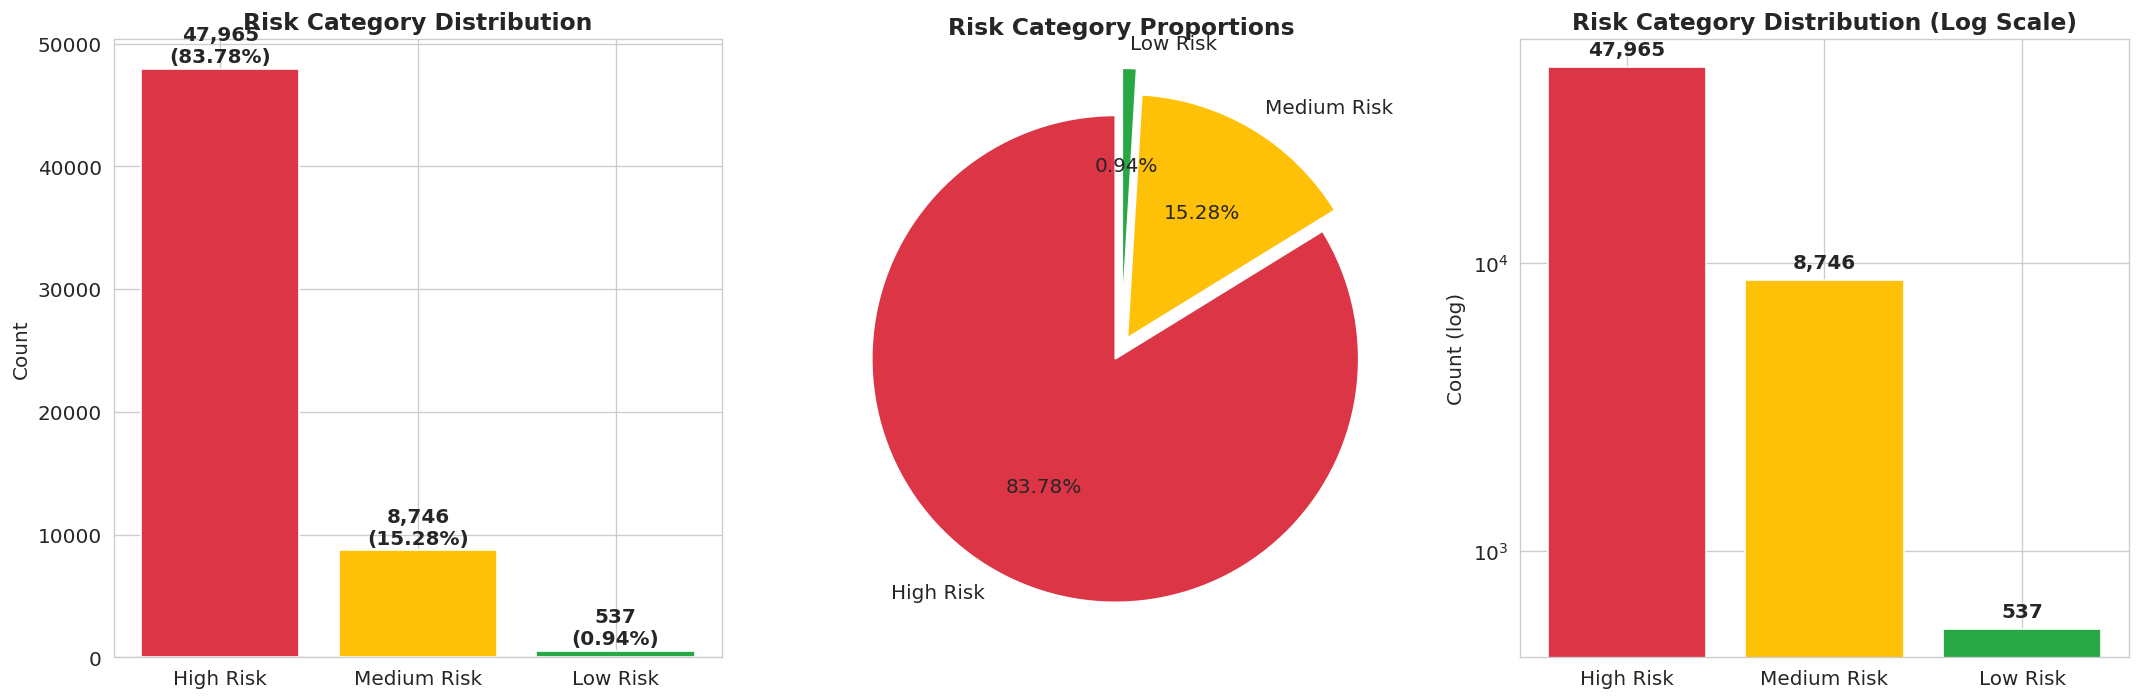


📊 IMBALANCE ANALYSIS:
   High:Medium ratio:    5.48:1
   High:Low ratio:       89.32:1
   Medium:Low ratio:     16.29:1
   
   Effective sample size:
   High Risk:   47,965 (dominant class)
   Medium Risk: 8,746 (minority)
   Low Risk:    537 (extreme minority ⚠️)


📊 RISK LEVEL vs RISK CATEGORY:
label.risk_category  High Risk  Low Risk  Medium Risk    All
label.risk_level                                            
1.0                          0       537            0    537
2.0                          0         0         8746   8746
3.0                      47965         0            0  47965
All                      47965       537         8746  57248

🔍 Risk Level unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
   Number of unique values: 3
   ✅ CONCLUSION: risk_level is ORDINAL ENCODING of risk_category
   Mapping: 1.0=Low Risk, 2.0=Medium Risk, 3.0=High Risk
   → We can safely DROP label.risk_level (redundant)

🎯 TARGET DECISION:
   • Use label.risk_category 

In [11]:
# ============================================
# STEP 3.2: TARGET VARIABLE DEEP ANALYSIS ⭐
# ============================================

print("\n" + "=" * 80)
print("🎯 STEP 3.2: TARGET VARIABLE DEEP ANALYSIS")
print("=" * 80)

# 3.2.1 Risk Category Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Count
colors = {'High Risk': '#dc3545', 'Medium Risk': '#ffc107', 'Low Risk': '#28a745'}
cat_counts = df_complete['label.risk_category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, 
            color=[colors.get(c, '#6c757d') for c in cat_counts.index])
axes[0].set_title('Risk Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cat, count) in enumerate(cat_counts.items()):
    pct = count / len(df_complete) * 100
    axes[0].text(i, count + 500, f'{count:,}\n({pct:.2f}%)', ha='center', fontweight='bold')

# Plot 2: Pie
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.2f%%',
            colors=[colors.get(c, '#6c757d') for c in cat_counts.index],
            explode=(0.05, 0.05, 0.15), startangle=90)
axes[1].set_title('Risk Category Proportions', fontsize=14, fontweight='bold')

# Plot 3: Log scale
axes[2].bar(cat_counts.index, cat_counts.values, 
            color=[colors.get(c, '#6c757d') for c in cat_counts.index])
axes[2].set_yscale('log')
axes[2].set_title('Risk Category Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count (log)')
for i, (cat, count) in enumerate(cat_counts.items()):
    axes[2].text(i, count * 1.1, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Imbalance ratios
print(f"""
📊 IMBALANCE ANALYSIS:
   High:Medium ratio:    {cat_counts['High Risk'] / cat_counts['Medium Risk']:.2f}:1
   High:Low ratio:       {cat_counts['High Risk'] / cat_counts['Low Risk']:.2f}:1
   Medium:Low ratio:     {cat_counts['Medium Risk'] / cat_counts['Low Risk']:.2f}:1
   
   Effective sample size:
   High Risk:   {cat_counts['High Risk']:,} (dominant class)
   Medium Risk: {cat_counts['Medium Risk']:,} (minority)
   Low Risk:    {cat_counts['Low Risk']:,} (extreme minority ⚠️)
""")

# 3.2.2 Risk Level Analysis
print("\n📊 RISK LEVEL vs RISK CATEGORY:")
risk_crosstab = pd.crosstab(df_complete['label.risk_level'], 
                             df_complete['label.risk_category'],
                             margins=True)
print(risk_crosstab)

# Check: is risk_level just ordinal encoding?
unique_levels = sorted(df_complete['label.risk_level'].dropna().unique())
print(f"\n🔍 Risk Level unique values: {unique_levels}")
print(f"   Number of unique values: {len(unique_levels)}")

if len(unique_levels) == 3:
    print("   ✅ CONCLUSION: risk_level is ORDINAL ENCODING of risk_category")
    print("   Mapping: 1.0=Low Risk, 2.0=Medium Risk, 3.0=High Risk")
    print("   → We can safely DROP label.risk_level (redundant)")
else:
    print("   → risk_level is continuous, may contain more information")

# 3.2.3 Decision
print(f"""
{'='*60}
🎯 TARGET DECISION:
   • Use label.risk_category as SOLE target for classification
   • Drop label.risk_level (confirmed: ordinal encoding, 3 values only)
   • 3-class classification: High Risk, Medium Risk, Low Risk
   • Severe imbalance: Low Risk = 0.94% only
{'='*60}
""")


🔍 STEP 3.3: MISSING VALUES DEEP DIVE

📊 OVERALL MISSING VALUES:
   Total cells:     17,403,392
   Missing cells:   7,879,591
   Missing %:       45.28%
   Complete cells:  9,523,801 (54.72%)

📊 MISSING BY CATEGORY:
   <1%         :   75 columns
   1-10%       :   32 columns
   10-30%      :   23 columns
   30-50%      :   21 columns
   50-70%      :   11 columns
   70-95%      :    5 columns
   >95%        :  114 columns


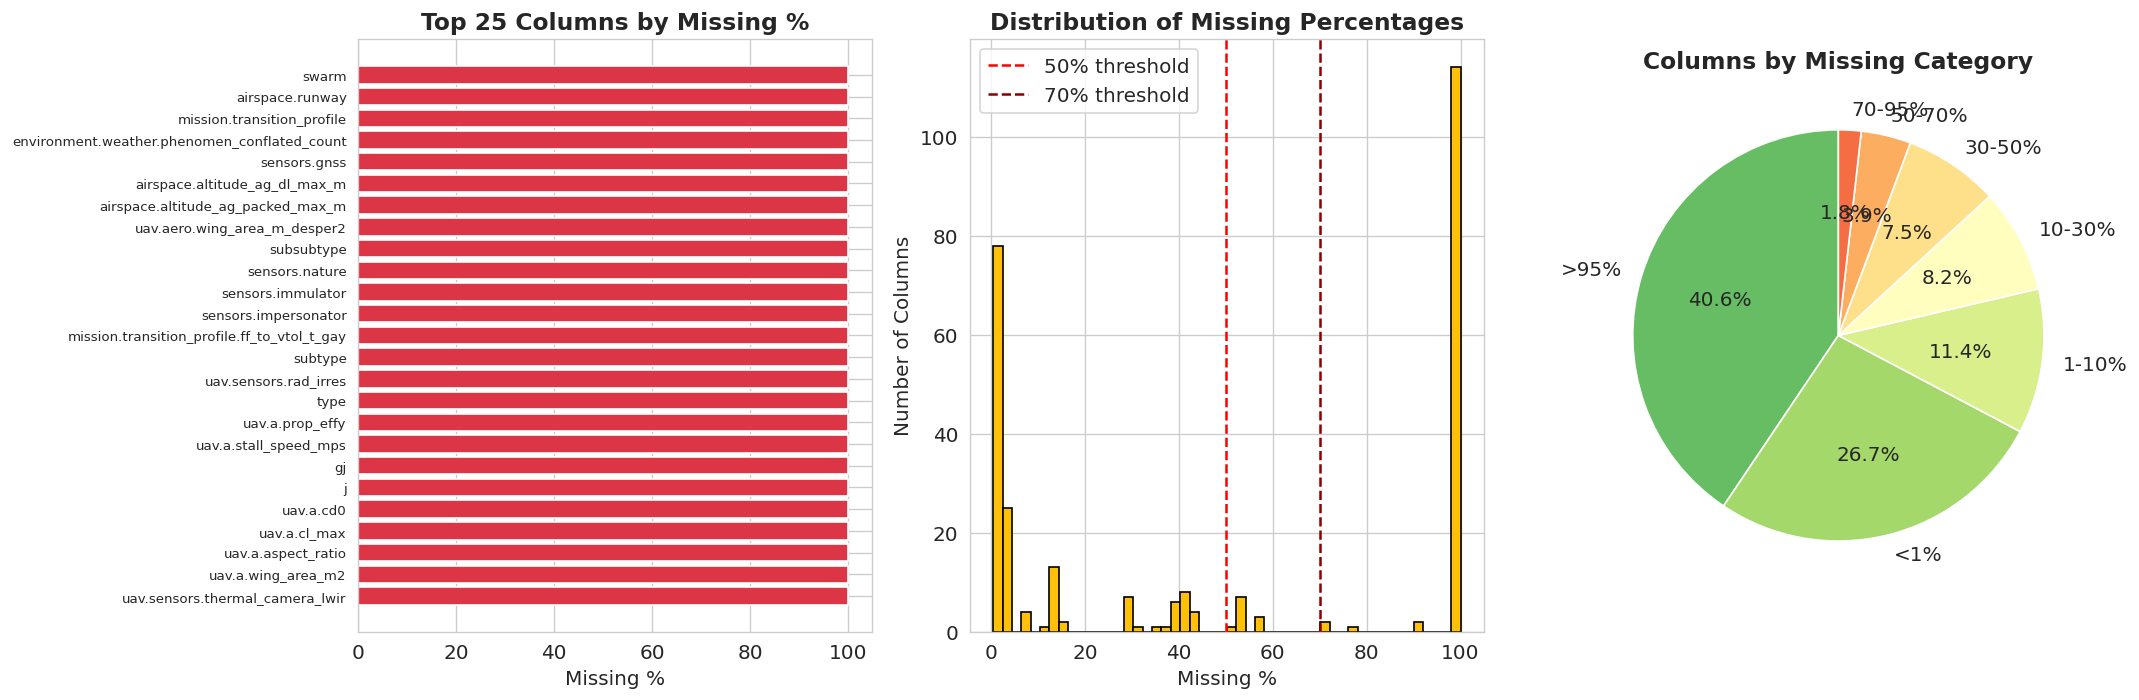


✅ STEP 3.3 Complete


In [12]:
# ============================================
# STEP 3.3: MISSING VALUES DEEP DIVE ⭐
# ============================================

print("\n" + "=" * 80)
print("🔍 STEP 3.3: MISSING VALUES DEEP DIVE")
print("=" * 80)

# 3.3.1 Overall statistics
total_cells = df_complete.shape[0] * df_complete.shape[1]
total_missing = df_complete.isna().sum().sum()
overall_missing_pct = total_missing / total_cells * 100

print(f"""
📊 OVERALL MISSING VALUES:
   Total cells:     {total_cells:,}
   Missing cells:   {total_missing:,}
   Missing %:       {overall_missing_pct:.2f}%
   Complete cells:  {total_cells - total_missing:,} ({(1-overall_missing_pct/100)*100:.2f}%)
""")

# 3.3.2 Per-column missing analysis
missing_by_col = df_complete.isna().sum()
missing_pct_by_col = (missing_by_col / len(df_complete)) * 100

# Exclude constant and identifier columns for cleaner analysis
exclude_cols = column_types.get('constant', []) + column_types.get('identifier', [])
cols_to_analyze = [c for c in df_complete.columns if c not in exclude_cols]

missing_df = pd.DataFrame({
    'Column': missing_by_col.index,
    'Missing': missing_by_col.values,
    'Percentage': missing_pct_by_col.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)

# Categorize missing levels
def missing_category(pct):
    if pct == 0: return 'Complete'
    if pct < 1: return '<1%'
    if pct < 10: return '1-10%'
    if pct < 30: return '10-30%'
    if pct < 50: return '30-50%'
    if pct < 70: return '50-70%'
    if pct < 95: return '70-95%'
    return '>95%'

missing_df['Category'] = missing_df['Percentage'].apply(missing_category)
category_summary = missing_df['Category'].value_counts()

print("📊 MISSING BY CATEGORY:")
for cat in ['Complete', '<1%', '1-10%', '10-30%', '30-50%', '50-70%', '70-95%', '>95%']:
    count = category_summary.get(cat, 0)
    if count > 0:
        print(f"   {cat:12s}: {count:4d} columns")

# 3.3.3 Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top 25 missing columns
top_missing = missing_df.head(25)
axes[0].barh(range(len(top_missing)), top_missing['Percentage'].values, color='#dc3545')
axes[0].set_yticks(range(len(top_missing)))
axes[0].set_yticklabels(top_missing['Column'].values, fontsize=8)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Top 25 Columns by Missing %', fontweight='bold')
axes[0].invert_yaxis()

# Distribution of missing percentages
missing_pcts = missing_df['Percentage'].values
axes[1].hist(missing_pcts, bins=50, color='#ffc107', edgecolor='black')
axes[1].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[1].axvline(x=70, color='darkred', linestyle='--', label='70% threshold')
axes[1].set_xlabel('Missing %')
axes[1].set_ylabel('Number of Columns')
axes[1].set_title('Distribution of Missing Percentages', fontweight='bold')
axes[1].legend()

# Missing by category pie
axes[2].pie(category_summary.values, labels=category_summary.index, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(category_summary))))
axes[2].set_title('Columns by Missing Category', fontweight='bold')

plt.tight_layout()
plt.show()

# 3.3.4 Special columns analysis
# Look at the pattern: many columns have exactly 226 missing
missing_226 = [c for c in missing_df['Column'] if missing_by_col[c] == 226]
if missing_226:
    print(f"\n🔍 COLUMNS WITH EXACTLY 226 MISSING VALUES ({len(missing_226)} columns):")
    print("   These likely come from optional JSON sections")
    for col in missing_226[:10]:
        print(f"   • {col}")

print(f"\n✅ STEP 3.3 Complete")

In [13]:
# ============================================
# STEP 3.4: CONSTANT & IDENTIFIER ANALYSIS
# ============================================

print("\n" + "=" * 80)
print("🔍 STEP 3.4: CONSTANT & IDENTIFIER COLUMNS")
print("=" * 80)

# 3.4.1 Constant columns
constant_cols = column_types.get('constant', [])
print(f"\n📊 CONSTANT COLUMNS: {len(constant_cols)}")
print("   These columns have only 1 unique value - zero predictive power")
print("   → ALL WILL BE DROPPED")

# Categorize constants
nan_constants = [c for c in constant_cols if df_complete[c].isna().all()]
zero_constants = [c for c in constant_cols if (df_complete[c] == 0).all()]
other_constants = [c for c in constant_cols if c not in nan_constants + zero_constants]

print(f"\n   NaN constants:  {len(nan_constants)} (all values are NaN)")
print(f"   Zero constants: {len(zero_constants)} (all values are 0)")
print(f"   Other constants: {len(other_constants)} (all same non-zero value)")

if other_constants:
    print(f"\n   Non-zero constants:")
    for col in other_constants[:10]:
        val = df_complete[col].iloc[0]
        print(f"      • {col}: = {val}")

# 3.4.2 Identifier columns
id_cols = column_types.get('identifier', [])
text_cols = column_types.get('text_columns', [])
all_id_cols = list(set(id_cols + text_cols))

print(f"\n📊 IDENTIFIER/TEXT COLUMNS: {len(all_id_cols)}")
print("   These columns have nearly all unique values - no generalization value")
print("   → ALL WILL BE DROPPED")
for col in all_id_cols:
    print(f"   • {col}: {df_complete[col].nunique():,} unique / {len(df_complete):,} rows")

# 3.4.3 Binary columns
binary_cols = column_types.get('binary', [])
print(f"\n📊 BINARY COLUMNS: {len(binary_cols)}")
print("   These have exactly 2 unique values - keep for modeling")
for col in binary_cols[:10]:
    vals = df_complete[col].dropna().unique()
    print(f"   • {col}: {vals}")

# 3.4.4 Final removal decision
immediate_drops = constant_cols + all_id_cols
print(f"\n{'='*60}")
print(f"🛑 IMMEDIATE DROPS: {len(immediate_drops)} columns")
print(f"   • {len(constant_cols)} constant columns")
print(f"   • {len(all_id_cols)} identifier/text columns")
print(f"{'='*60}")

print(f"\n✅ STEP 3.4 Complete")


🔍 STEP 3.4: CONSTANT & IDENTIFIER COLUMNS

📊 CONSTANT COLUMNS: 89
   These columns have only 1 unique value - zero predictive power
   → ALL WILL BE DROPPED

   NaN constants:  3 (all values are NaN)
   Zero constants: 0 (all values are 0)
   Other constants: 86 (all same non-zero value)

   Non-zero constants:
      • uav.sensors.imu: = 1.0
      • uav.sensors.barometer: = 1.0
      • airspace.geofence_count: = 1.0
      • airspace.geofence_sample_type: = polygon
      • airspace.no_fly_zones_sample_type: = cylinder
      • spawn.xyz_count: = 3.0
      • traffic_sample_type: = uav
      • moving_obstacles_sample_shape: = sphere
      • required_count: = 7.0
      • required_first: = name

📊 IDENTIFIER/TEXT COLUMNS: 3
   These columns have nearly all unique values - no generalization value
   → ALL WILL BE DROPPED
   • description.text: 57,246 unique / 57,248 rows
   • name: 44,249 unique / 57,248 rows
   • filename: 57,248 unique / 57,248 rows

📊 BINARY COLUMNS: 15
   These have exac


📈 STEP 3.5: NUMERICAL FEATURES ANALYSIS

📊 Numeric columns to analyze: 131

📊 Key numerical features (domain-relevant): 43
   • uav.mass_kg
   • uav.battery_wh
   • uav.max_speed_mps
   • uav.reserve_fraction
   • uav.battery_model.hover_power_w
   • uav.battery_model.k_drag
   • uav.battery_model.k_manoeuvre
   • uav.rotorcraft.rotor_count
   • uav.rotorcraft.disk_area_m2
   • uav.payload.mass_kg
   • uav.payload.drag_coeff
   • environment.weather.wind_mps
   • environment.weather.wind_dir_deg
   • environment.weather.gust_mps
   • airspace.altitude_agl_min_m
   • airspace.altitude_agl_max_m
   • traffic_count
   • traffic_sample_speed_mps
   • traffic_sample_heading_deg
   • daa.sep_threshold_m

📊 TOP FEATURES BY ANOVA F-SCORE (discriminative power):
   Analyzing 43 domain-relevant features...
   Samples available: 57,248

   Top 25 features by ANOVA F-score:
   Rank  Feature                                                 F-Score      Log10(F)
   ---- -----------------------------

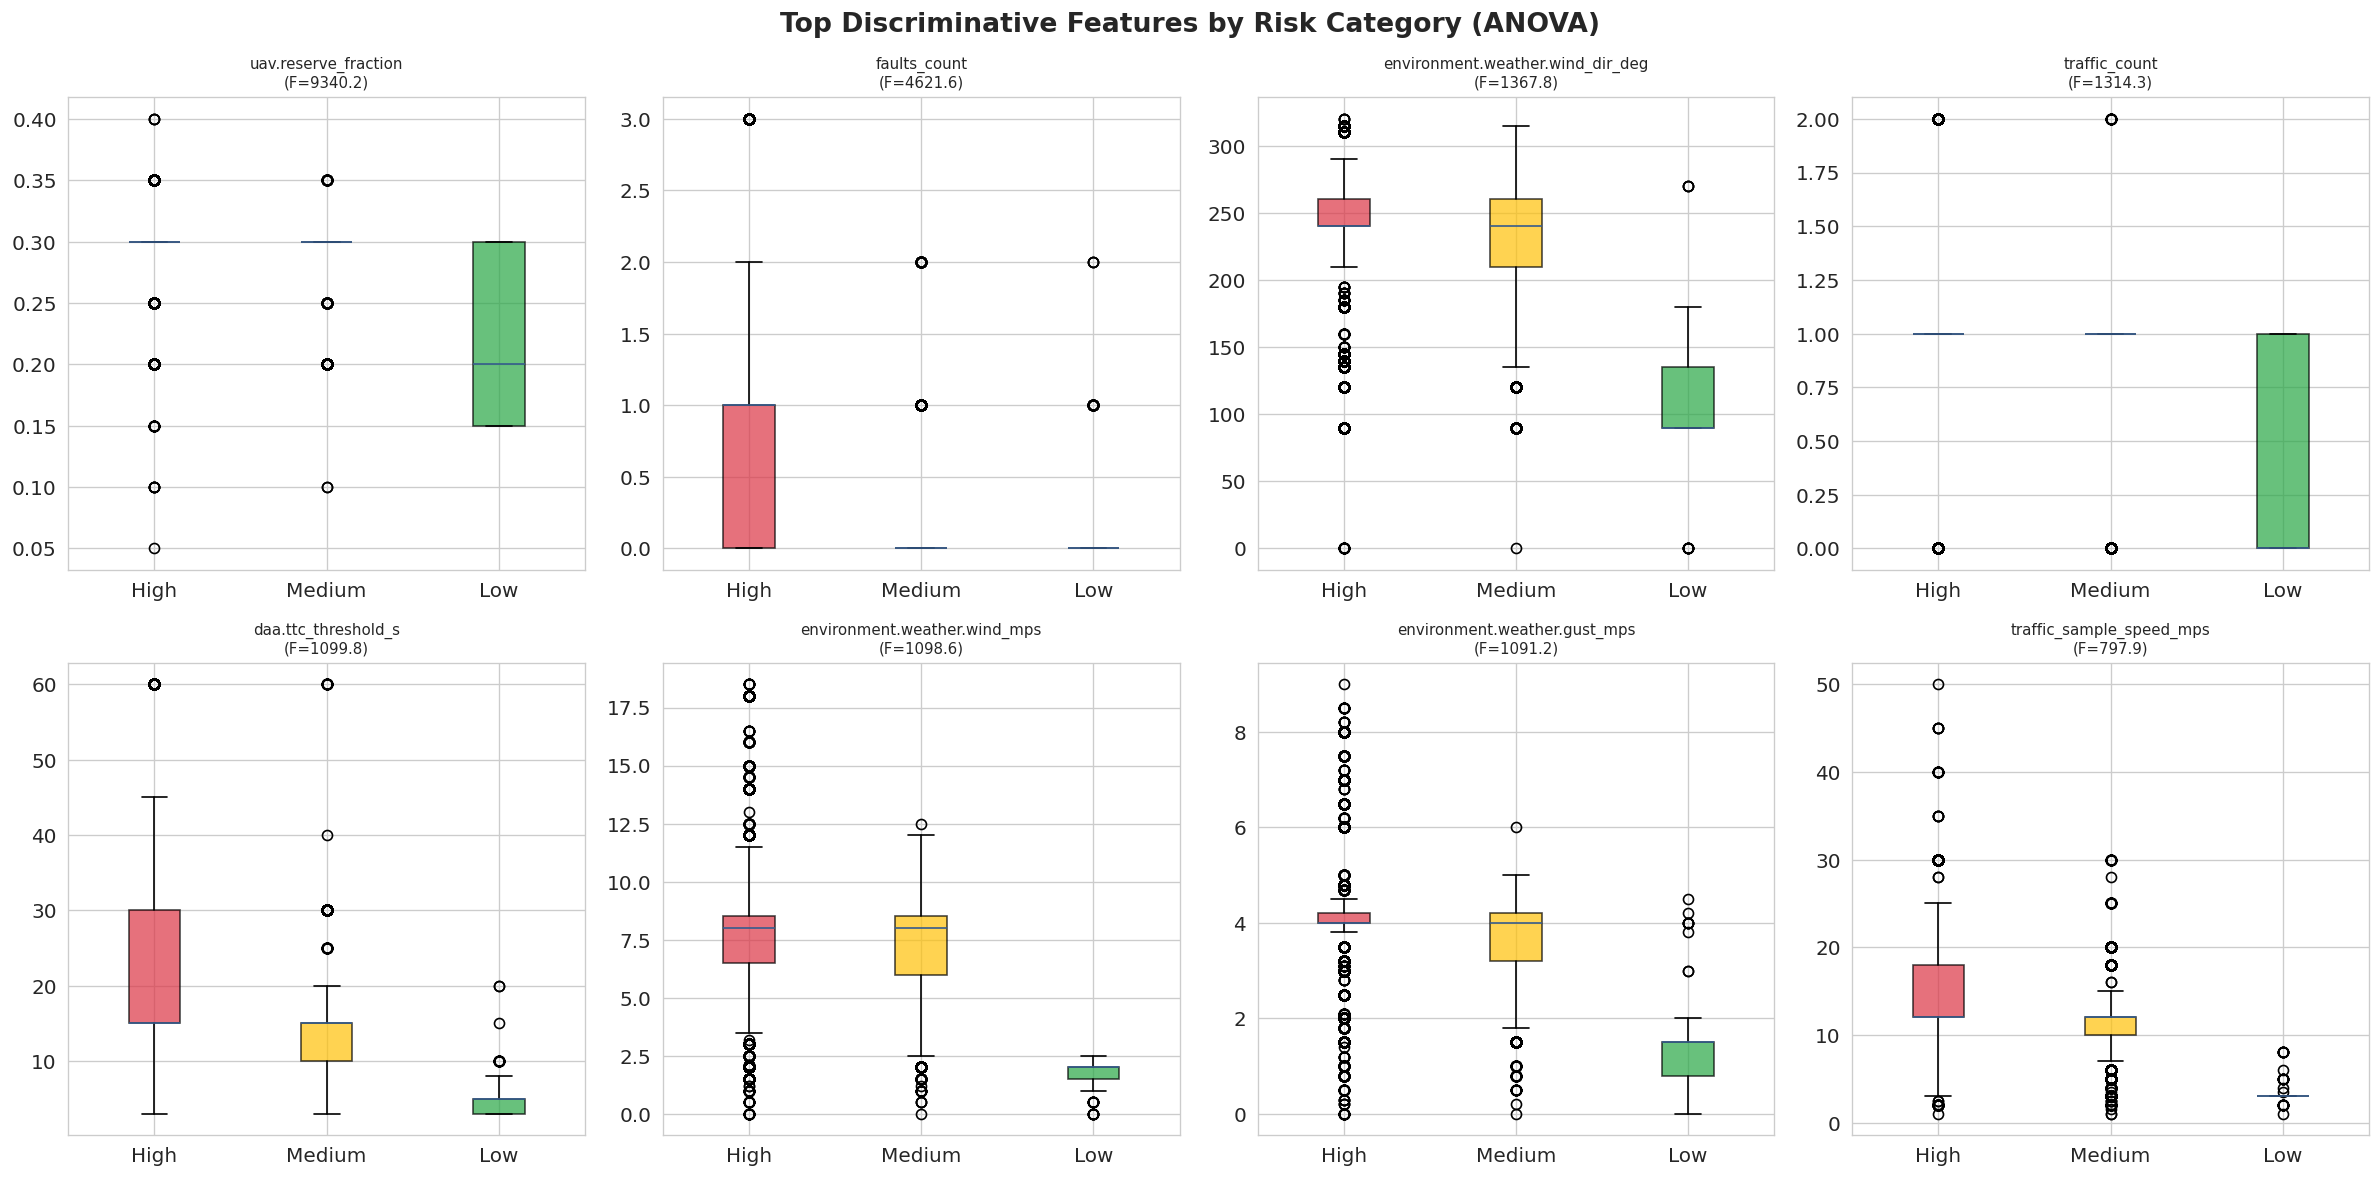


📊 DISTRIBUTION STATISTICS BY RISK CATEGORY (Top 5 features):

   Feature: uav.reserve_fraction
   High Risk      : n=47,965 | mean=0.300 | median=0.300 | std=0.010 | skew=-7.658
   Medium Risk    : n= 8,746 | mean=0.298 | median=0.300 | std=0.013 | skew=-6.631
   Low Risk       : n=   537 | mean=0.226 | median=0.200 | std=0.073 | skew=-0.009

   Feature: faults_count
   High Risk      : n=47,932 | mean=0.874 | median=1.000 | std=0.670 | skew=0.200
   Medium Risk    : n= 8,676 | mean=0.161 | median=0.000 | std=0.386 | skew=2.203
   Low Risk       : n=   292 | mean=0.209 | median=0.000 | std=0.432 | skew=1.819

   Feature: environment.weather.wind_dir_deg
   High Risk      : n=47,964 | mean=238.017 | median=240.000 | std=33.939 | skew=-1.876
   Medium Risk    : n= 8,746 | mean=224.528 | median=240.000 | std=47.181 | skew=-1.159
   Low Risk       : n=   292 | mean=110.291 | median=90.000 | std=36.560 | skew=0.701

   Feature: traffic_count
   High Risk      : n=47,936 | mean=0.990 | medi

In [14]:
# ============================================
# STEP 3.5: NUMERICAL FEATURES ANALYSIS ⭐ (FIXED)
# ============================================

print("\n" + "=" * 80)
print("📈 STEP 3.5: NUMERICAL FEATURES ANALYSIS")
print("=" * 80)

# Get numeric columns (excluding target and columns we'll drop)
exclude_from_analysis = set(constant_cols + all_id_cols + ['label.risk_level', 'label.risk_category',
                                                             'label.factors_count', 'label.factors_first'])
numeric_cols = [c for c in column_types.get('numeric', []) if c not in exclude_from_analysis]
print(f"\n📊 Numeric columns to analyze: {len(numeric_cols)}")

# Identify domain-relevant features
key_numeric = [c for c in df_complete.columns if any(term in c.lower() for term in [
    'mass', 'battery', 'power', 'speed', 'wind', 'gust', 'visibility',
    'distance', 'climb', 'altitude', 'fault', 'traffic', 'sep_threshold',
    'ttc_threshold', 'reserve', 'rotor', 'disk_area', 'payload_mass',
    'hover_power', 'drag', 'manoeuvre'
]) and c in numeric_cols]

print(f"\n📊 Key numerical features (domain-relevant): {len(key_numeric)}")
for col in key_numeric[:20]:
    print(f"   • {col}")

# ============================================
# 3.5.2 ANOVA F-test (FIXED - handles any number of columns)
# ============================================
print(f"\n📊 TOP FEATURES BY ANOVA F-SCORE (discriminative power):")
print(f"   Analyzing {len(key_numeric)} domain-relevant features...")

# Prepare data - drop rows with missing target
df_anova = df_complete[key_numeric + ['label.risk_category']].copy()

# Fill missing numeric values with median for this analysis
for col in key_numeric:
    if df_anova[col].isna().any():
        df_anova[col] = df_anova[col].fillna(df_anova[col].median())

# Remove any remaining NaN rows
df_anova = df_anova.dropna(subset=['label.risk_category'])

print(f"   Samples available: {len(df_anova):,}")

# Calculate ANOVA F-scores for ALL key numeric features
f_scores = {}
for col in key_numeric:
    try:
        groups = [df_anova[df_anova['label.risk_category'] == cat][col].dropna().values 
                  for cat in config.RISK_CLASSES]
        if all(len(g) > 10 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
            f_scores[col] = f_stat
    except Exception as e:
        pass  # Skip columns that cause errors

# Sort and display top 25
top_f = sorted(f_scores.items(), key=lambda x: x[1], reverse=True)[:25]

if top_f:
    print(f"\n   Top {len(top_f)} features by ANOVA F-score:")
    print(f"   {'Rank':<5} {'Feature':<55} {'F-Score':<12} {'Log10(F)'}")
    print(f"   {'-'*4} {'-'*55} {'-'*12} {'-'*10}")
    for i, (col, score) in enumerate(top_f, 1):
        print(f"   {i:<5} {col:<55} {score:<12.2f} {np.log10(score):.2f}")
else:
    print("   ⚠️ No F-scores calculated - check data quality")

# ============================================
# 3.5.3 Box plots for top discriminative features (FIXED)
# ============================================
if top_f:
    top_features_for_plot = [f[0] for f in top_f[:8]]
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(top_features_for_plot):
        ax = axes[i]
        data_by_cat = []
        labels = []
        for cat in config.RISK_CLASSES:
            cat_data = df_complete[df_complete['label.risk_category'] == cat][feature].dropna()
            if len(cat_data) > 0:
                data_by_cat.append(cat_data.values)
                labels.append(cat.split()[0])  # High, Medium, Low
        
        if data_by_cat:
            bp = ax.boxplot(data_by_cat, labels=labels, patch_artist=True)
            colors_box = ['#dc3545', '#ffc107', '#28a745']
            for patch, color in zip(bp['boxes'], colors_box[:len(data_by_cat)]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_title(f'{feature}\n(F={f_scores.get(feature, 0):.1f})', fontsize=9)
            ax.tick_params(axis='x', rotation=0)
    
    # Hide unused subplots
    for i in range(len(top_features_for_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Top Discriminative Features by Risk Category (ANOVA)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n   ⚠️ Not enough features for box plots")

# ============================================
# 3.5.4 Distribution statistics by risk category
# ============================================
if top_f:
    print(f"\n📊 DISTRIBUTION STATISTICS BY RISK CATEGORY (Top 5 features):")
    
    for col, _ in top_f[:5]:
        print(f"\n   {'='*50}")
        print(f"   Feature: {col}")
        print(f"   {'='*50}")
        for cat in config.RISK_CLASSES:
            cat_data = df_complete[df_complete['label.risk_category'] == cat][col].dropna()
            if len(cat_data) > 0:
                print(f"   {cat:15s}: n={len(cat_data):6,} | mean={cat_data.mean():.3f} | "
                      f"median={cat_data.median():.3f} | std={cat_data.std():.3f} | "
                      f"skew={cat_data.skew():.3f}")

print(f"\n✅ STEP 3.5 Complete")


🏷️ STEP 3.6: CATEGORICAL FEATURES ANALYSIS

📊 Categorical columns to analyze: 26

📊 CATEGORICAL COLUMNS CARDINALITY:
   • uav.type                                     :   18 unique | missing=    0 | MEDIUM (Target Enc)
   • uav.energy_source                            :    3 unique | missing=  245 | LOW (One-Hot)
   • environment.airspace                         :   25 unique | missing=  246 | MEDIUM (Target Enc)
   • environment.weather.visibility               :   14 unique | missing=  246 | MEDIUM (Target Enc)
   • environment.weather.phenomena_first          :   74 unique | missing= 9341 | HIGH (Frequency/Check)
   • airspace.geofence_sample_points              : 1460 unique | missing=    0 | HIGH (Frequency/Check)
   • airspace.no_fly_zones_sample_center          :  938 unique | missing=  260 | HIGH (Frequency/Check)
   • landing.preferred_sites_sample               : 6504 unique | missing= 1643 | HIGH (Frequency/Check)
   • landing.emergency_sites_sample               : 8509 uni

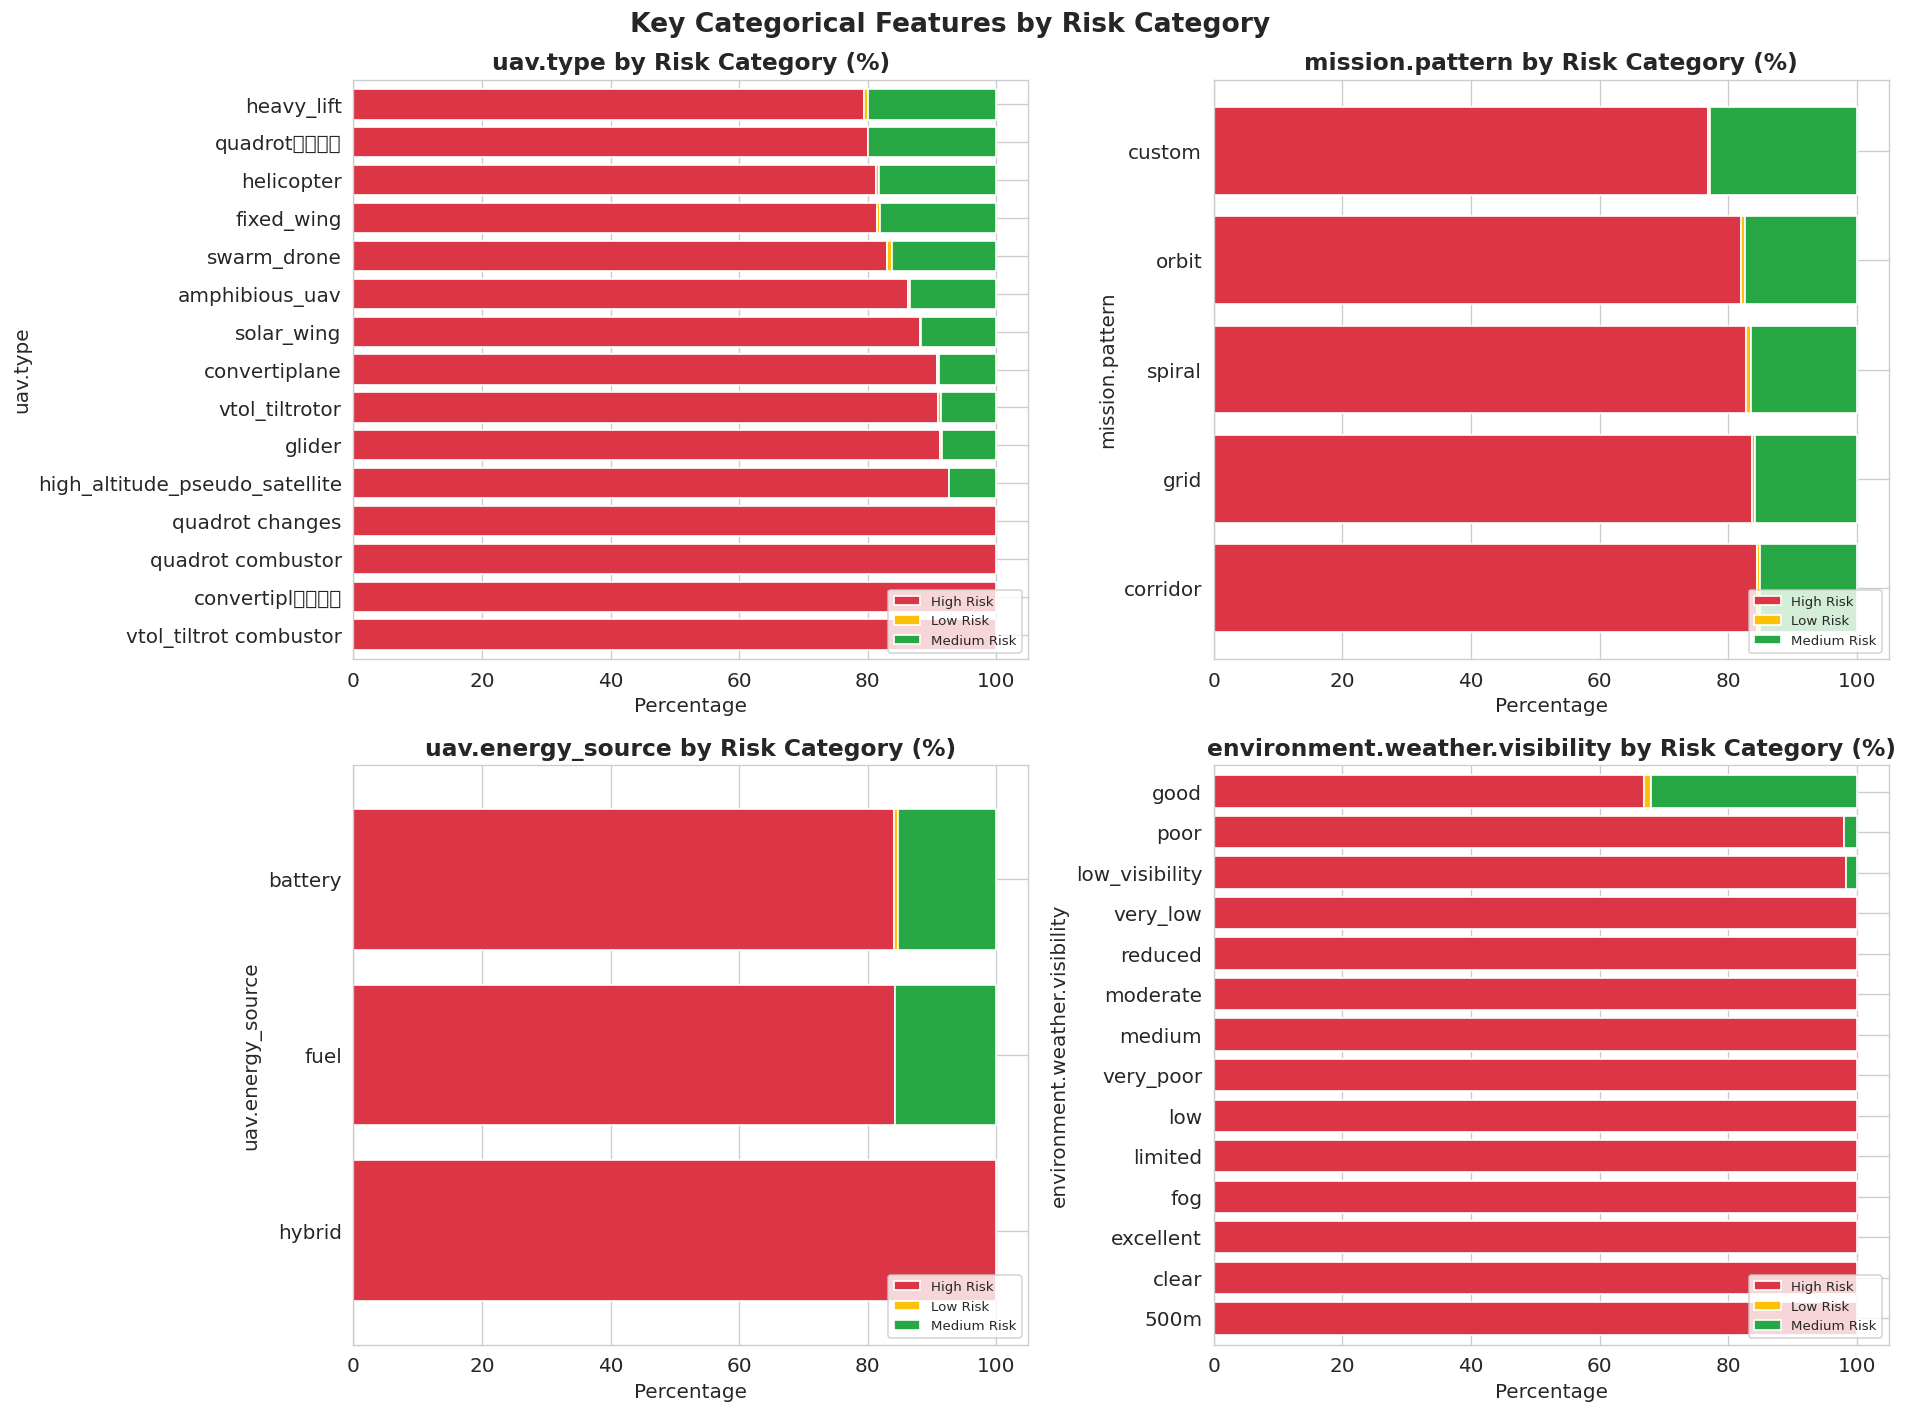


✅ STEP 3.6 Complete


In [15]:
# ============================================
# STEP 3.6: CATEGORICAL FEATURES ANALYSIS ⭐
# ============================================

print("\n" + "=" * 80)
print("🏷️ STEP 3.6: CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

cat_cols = [c for c in column_types.get('categorical', []) if c not in exclude_from_analysis]
print(f"\n📊 Categorical columns to analyze: {len(cat_cols)}")

# 3.6.1 Cardinality analysis
print(f"\n📊 CATEGORICAL COLUMNS CARDINALITY:")
for col in cat_cols:
    n_unique = df_complete[col].nunique()
    n_missing = df_complete[col].isna().sum()
    cardinality_label = 'LOW (One-Hot)' if n_unique <= 10 else 'MEDIUM (Target Enc)' if n_unique <= 50 else 'HIGH (Frequency/Check)'
    print(f"   • {col:45s}: {n_unique:4d} unique | missing={n_missing:5d} | {cardinality_label}")

# 3.6.2 Analyze key categorical features vs risk
key_categorical = ['uav.type', 'mission.type', 'mission.pattern', 
                   'uav.energy_source', 'environment.weather.visibility',
                   'faults_sample_type', 'environment.airspace']

for cat_col in key_categorical:
    if cat_col in df_complete.columns:
        print(f"\n{'='*60}")
        print(f"📊 {cat_col} vs Risk Category")
        
        # Crosstab with percentages
        ct = pd.crosstab(df_complete[cat_col], df_complete['label.risk_category'], normalize='index') * 100
        
        # Sort by High Risk percentage
        if 'High Risk' in ct.columns:
            ct = ct.sort_values('High Risk', ascending=False)
        
        print(ct.head(10).to_string())

# 3.6.3 Visualize top key categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_cols = ['uav.type', 'mission.pattern', 'uav.energy_source', 'environment.weather.visibility']
for i, col in enumerate(plot_cols):
    if col in df_complete.columns and i < 4:
        ax = axes[i]
        ct_pct = pd.crosstab(df_complete[col], df_complete['label.risk_category'], normalize='index') * 100
        
        if 'High Risk' in ct_pct.columns:
            ct_pct = ct_pct.sort_values('High Risk', ascending=False)
        
        ct_pct_head = ct_pct.head(15)
        ct_pct_head.plot(kind='barh', stacked=True, ax=ax, 
                         color=['#dc3545', '#ffc107', '#28a745'], width=0.8)
        ax.set_title(f'{col} by Risk Category (%)', fontweight='bold')
        ax.set_xlabel('Percentage')
        ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Key Categorical Features by Risk Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ STEP 3.6 Complete")


🔘 STEP 3.7: BINARY FEATURES RISK ANALYSIS

📊 Binary columns to analyze: 15

📊 TOP BINARY FEATURES BY RISK DISCRIMINATION:
                        Feature Value_1  High_Risk_%_1 Value_2  High_Risk_%_2  Difference
         moving_obstacles_count     1.0      85.748340     0.0      40.558047   45.190293
         uav.sensors.camera_rgb     1.0      84.112297     0.0      99.259259   15.146962
    airspace.no_fly_zones_count     1.0      84.120783     2.0      96.855346   12.734563
              comms.downlink_ok     1.0      82.957955     0.0      94.904795   11.946840
                comms.uplink_ok     1.0      82.952463     0.0      94.870448   11.917986
              uav.sensors.radar     0.0      82.056776     1.0      93.112333   11.055557
        mission.runway_required     0.0      83.268310     1.0      90.496696    7.228385
     uav.sensors.camera_thermal     0.0      80.675365     1.0      87.328767    6.653403
airspace.runway.threshold_count     3.0      89.337726     2.0     

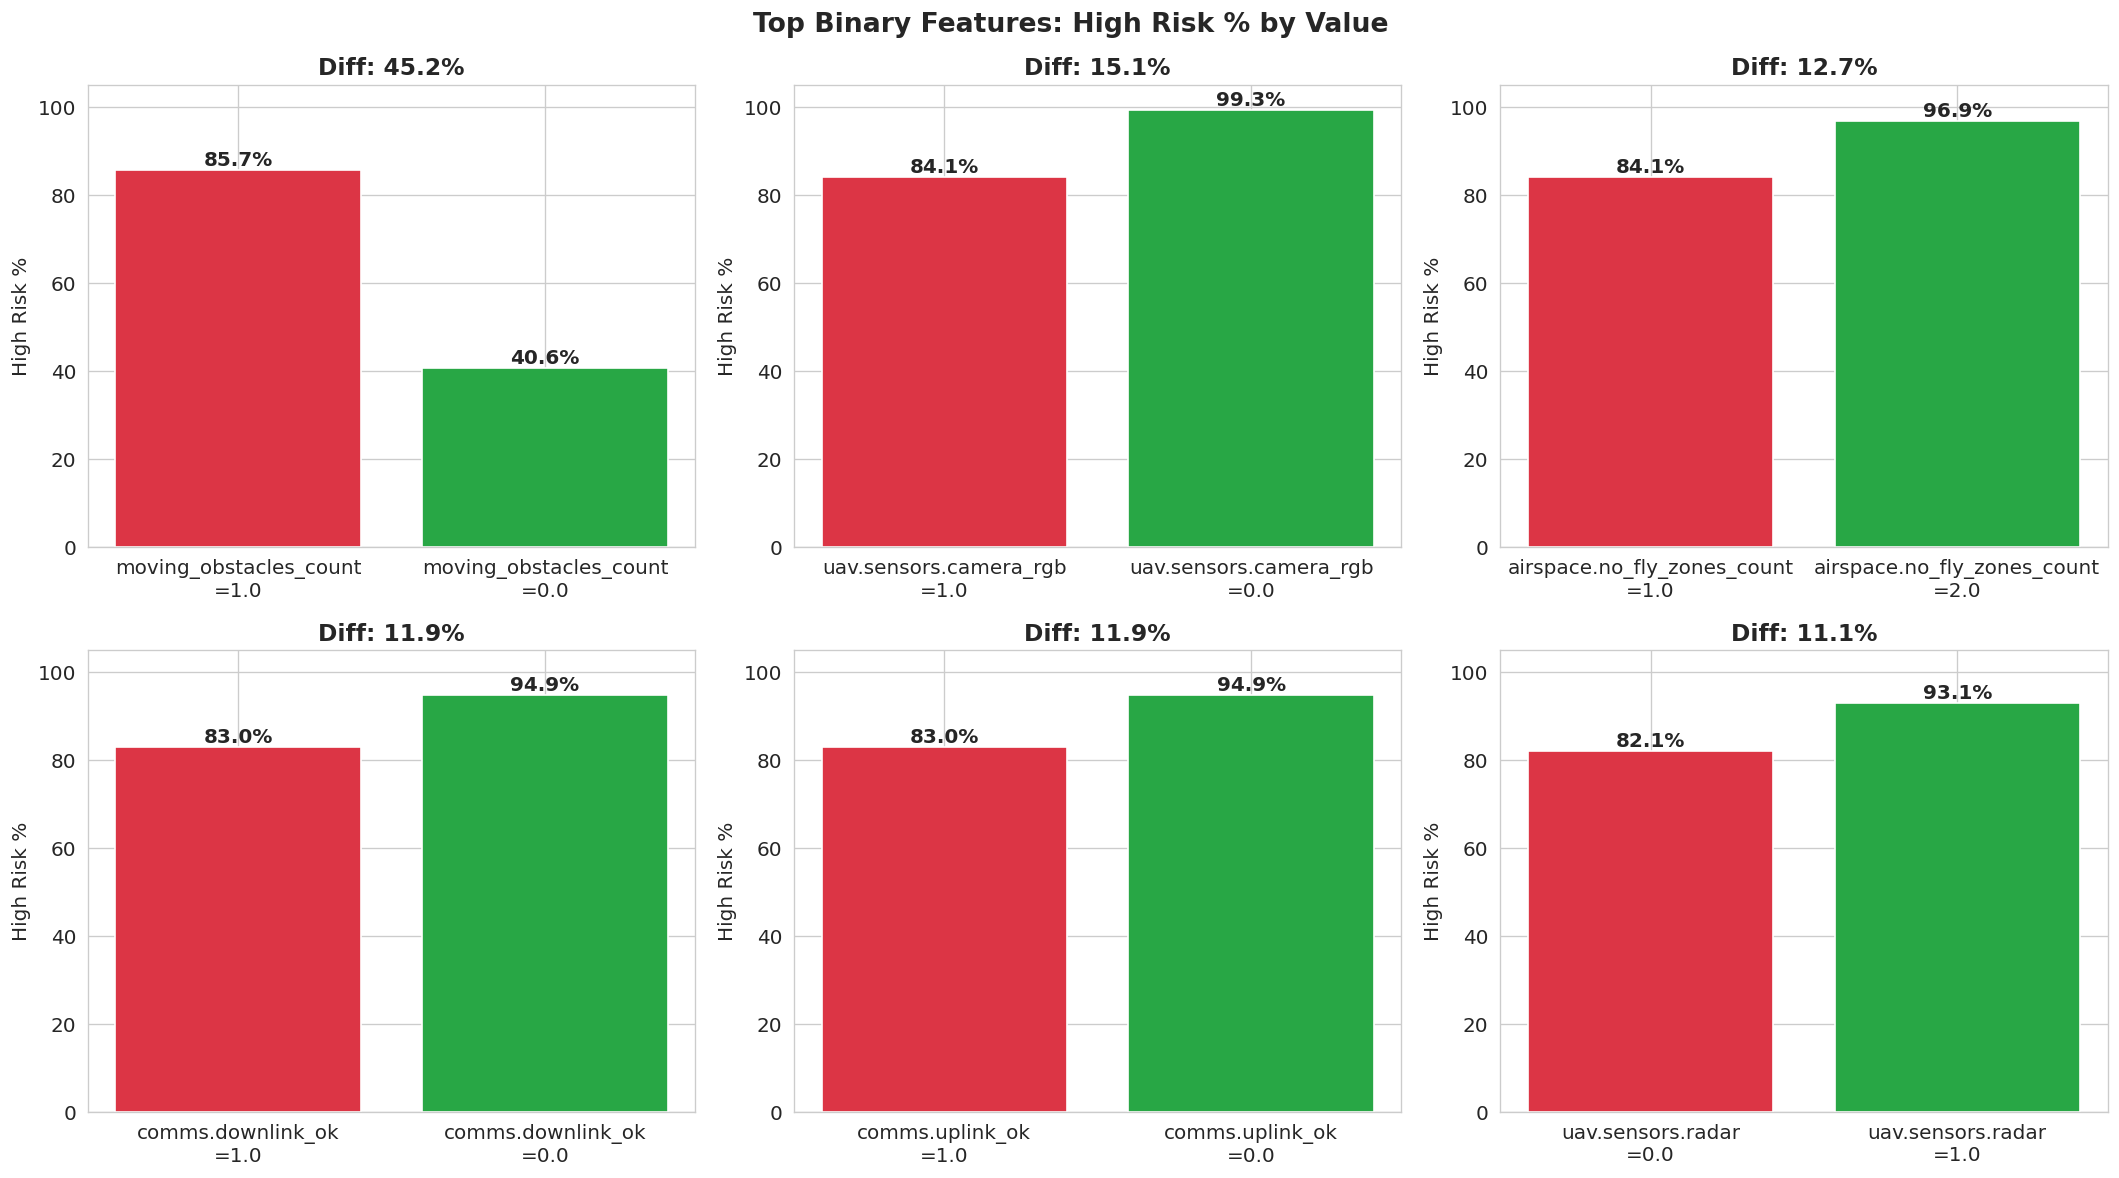


✅ STEP 3.7 Complete


In [16]:
# ============================================
# STEP 3.7: BINARY FEATURES RISK ANALYSIS
# ============================================

print("\n" + "=" * 80)
print("🔘 STEP 3.7: BINARY FEATURES RISK ANALYSIS")
print("=" * 80)

binary_cols_clean = [c for c in column_types.get('binary', []) if c not in exclude_from_analysis]
print(f"\n📊 Binary columns to analyze: {len(binary_cols_clean)}")

# Calculate risk ratios for each binary feature
risk_ratios = []
for col in binary_cols_clean:
    if df_complete[col].nunique() == 2:
        # Get the two unique values
        vals = df_complete[col].dropna().unique()
        if len(vals) == 2:
            # Calculate High Risk % for each value
            high_risk_pcts = {}
            for val in vals:
                subset = df_complete[df_complete[col] == val]
                if len(subset) > 10:
                    high_risk_pct = (subset['label.risk_category'] == 'High Risk').mean() * 100
                    high_risk_pcts[val] = high_risk_pct
            
            if len(high_risk_pcts) == 2:
                val1, val2 = list(high_risk_pcts.keys())
                diff = abs(high_risk_pcts[val1] - high_risk_pcts[val2])
                risk_ratios.append({
                    'Feature': col,
                    'Value_1': str(val1)[:20],
                    'High_Risk_%_1': high_risk_pcts[val1],
                    'Value_2': str(val2)[:20],
                    'High_Risk_%_2': high_risk_pcts[val2],
                    'Difference': diff
                })

risk_ratios_df = pd.DataFrame(risk_ratios).sort_values('Difference', ascending=False)

print(f"\n📊 TOP BINARY FEATURES BY RISK DISCRIMINATION:")
print(risk_ratios_df.head(15).to_string(index=False))

# Visualize top binary features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(min(6, len(risk_ratios_df))):
    ax = axes[i]
    row = risk_ratios_df.iloc[i]
    
    data = [
        [row['High_Risk_%_1'], 100 - row['High_Risk_%_1']],
        [row['High_Risk_%_2'], 100 - row['High_Risk_%_2']]
    ]
    
    bars = ax.bar([f"{row['Feature']}\n={row['Value_1']}", f"{row['Feature']}\n={row['Value_2']}"], 
                  [row['High_Risk_%_1'], row['High_Risk_%_2']],
                  color=['#dc3545', '#28a745'])
    ax.set_ylabel('High Risk %')
    ax.set_title(f"Diff: {row['Difference']:.1f}%", fontweight='bold')
    ax.set_ylim(0, 105)
    
    for bar, val in zip(bars, [row['High_Risk_%_1'], row['High_Risk_%_2']]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
                ha='center', fontweight='bold')

plt.suptitle('Top Binary Features: High Risk % by Value', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ STEP 3.7 Complete")

In [17]:
# ============================================
# STEP 3.8: FEATURE ENGINEERING OPPORTUNITIES
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 3.8: FEATURE ENGINEERING OPPORTUNITIES")
print("=" * 80)

# Based on our EDA, identify promising features to engineer

feature_opportunities = {
    'power_to_weight': {
        'columns_needed': ['uav.battery_model.hover_power_W', 'uav.mass_kg'],
        'formula': 'hover_power_W / mass_kg',
        'rationale': 'Higher power-to-weight = more maneuverable = potentially less risk in wind, but more aggressive flying',
        'feasibility': 'HIGH' if all(c in df_complete.columns for c in ['uav.battery_model.hover_power_W', 'uav.mass_kg']) else 'LOW'
    },
    'energy_density': {
        'columns_needed': ['uav.battery_capacity_Wh', 'uav.mass_kg'],
        'formula': 'battery_Wh / mass_kg',
        'rationale': 'Higher energy density = longer endurance = more mission flexibility',
        'feasibility': 'HIGH' if all(c in df_complete.columns for c in ['uav.battery_capacity_Wh', 'uav.mass_kg']) else 'LOW'
    },
    'battery_safety_margin': {
        'columns_needed': ['uav.battery_capacity_Wh', 'mission.waypoints_total_distance'],
        'formula': 'battery_Wh / (mission_distance + 1)',
        'rationale': 'How much battery per meter of mission - higher = safer',
        'feasibility': 'MEDIUM' if 'uav.battery_capacity_Wh' in df_complete.columns else 'LOW'
    },
    'disk_loading': {
        'columns_needed': ['uav.mass_kg', 'uav.rotorcraft.disk_area_m2'],
        'formula': 'mass_kg / disk_area_m2',
        'rationale': 'Disk loading affects stability and efficiency in wind',
        'feasibility': 'HIGH' if all(c in df_complete.columns for c in ['uav.mass_kg', 'uav.rotorcraft.disk_area_m2']) else 'LOW'
    },
    'wind_to_max_speed_ratio': {
        'columns_needed': ['environment.weather.wind_mps', 'uav.max_speed_mps'],
        'formula': 'wind_mps / max_speed_mps',
        'rationale': 'How close wind is to UAV max speed - critical safety metric',
        'feasibility': 'MEDIUM'
    },
    'altitude_range': {
        'columns_needed': ['airspace.altitude_agl_max_m', 'airspace.altitude_agl_min_m'],
        'formula': 'max_alt - min_alt',
        'rationale': 'Larger altitude range = more complex mission profile',
        'feasibility': 'HIGH' if all(c in df_complete.columns for c in ['airspace.altitude_agl_max_m', 'airspace.altitude_agl_min_m']) else 'LOW'
    },
    'mission_complexity': {
        'columns_needed': ['mission.waypoints_count', 'mission.waypoints_total_distance', 'mission.waypoints_total_climb'],
        'formula': 'waypoints * climb / (distance + 1)',
        'rationale': 'Composite metric for mission difficulty',
        'feasibility': 'MEDIUM'
    },
    'fault_risk_score': {
        'columns_needed': ['faults_count', 'faults_sample_severity'],
        'formula': 'fault_count * avg_severity',
        'rationale': 'Combined fault impact on risk',
        'feasibility': 'MEDIUM'
    },
    'sensor_redundancy': {
        'columns_needed': ['uav.sensors.gnss', 'uav.sensors.imu', 'uav.sensors.lidar', 'uav.sensors.radar'],
        'formula': 'sum(sensor_presence)',
        'rationale': 'More sensors = better redundancy = lower risk',
        'feasibility': 'HIGH'
    },
    'weather_severity_index': {
        'columns_needed': ['environment.weather.wind_mps', 'environment.weather.gust_mps', 'environment.weather.phenomena_sample'],
        'formula': 'wind + gust * 2 + phenomenon_score',
        'rationale': 'Composite weather risk for drone operations',
        'feasibility': 'MEDIUM'
    }
}

print(f"\n📊 FEATURE ENGINEERING OPPORTUNITIES:")
for name, details in feature_opportunities.items():
    status_icon = '✅' if details['feasibility'] == 'HIGH' else '⚠️' if details['feasibility'] == 'MEDIUM' else '❌'
    print(f"\n   {status_icon} {name}")
    print(f"      Formula: {details['formula']}")
    print(f"      Rationale: {details['rationale']}")
    print(f"      Feasibility: {details['feasibility']}")

# Check which columns exist
print(f"\n{'='*60}")
print("📋 COLUMN AVAILABILITY CHECK:")
key_columns = ['uav.mass_kg', 'uav.battery_capacity_Wh', 'uav.battery_model.hover_power_W',
               'uav.rotorcraft.disk_area_m2', 'uav.max_speed_mps', 'environment.weather.wind_mps',
               'environment.weather.gust_mps', 'airspace.altitude_agl_max_m', 'airspace.altitude_agl_min_m',
               'mission.waypoints_total_distance', 'mission.waypoints_total_climb', 'mission.waypoints_count',
               'faults_count', 'faults_sample_severity']

for col in key_columns:
    exists = '✅' if col in df_complete.columns else '❌'
    print(f"   {exists} {col}")

print(f"\n✅ STEP 3.8 Complete")


🔧 STEP 3.8: FEATURE ENGINEERING OPPORTUNITIES

📊 FEATURE ENGINEERING OPPORTUNITIES:

   ❌ power_to_weight
      Formula: hover_power_W / mass_kg
      Rationale: Higher power-to-weight = more maneuverable = potentially less risk in wind, but more aggressive flying
      Feasibility: LOW

   ❌ energy_density
      Formula: battery_Wh / mass_kg
      Rationale: Higher energy density = longer endurance = more mission flexibility
      Feasibility: LOW

   ❌ battery_safety_margin
      Formula: battery_Wh / (mission_distance + 1)
      Rationale: How much battery per meter of mission - higher = safer
      Feasibility: LOW

   ✅ disk_loading
      Formula: mass_kg / disk_area_m2
      Rationale: Disk loading affects stability and efficiency in wind
      Feasibility: HIGH

   ⚠️ wind_to_max_speed_ratio
      Formula: wind_mps / max_speed_mps
      Rationale: How close wind is to UAV max speed - critical safety metric
      Feasibility: MEDIUM

   ✅ altitude_range
      Formula: max_alt - 

In [18]:
# ============================================
# STEP 3.9: EDA SUMMARY & RECOMMENDATIONS
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 3.9: EDA FINAL REPORT & RECOMMENDATIONS")
print("=" * 80)

eda_report = f"""
{'='*80}
📊 UAV RISK STAGE-1 - EDA FINAL REPORT
{'='*80}

📐 DATASET OVERVIEW:
   Raw shape:      {df_complete.shape[0]:,} rows × {df_complete.shape[1]} columns
   Memory:         {df_complete.memory_usage(deep=True).sum()/1024**2:.2f} MB
   
🎯 TARGET (label.risk_category):
   High Risk:      47,965 (83.78%) ████████████████████████████████████████
   Medium Risk:     8,746 (15.28%) ███████
   Low Risk:           537 (0.94%) ▌
   
   ⚠️ CRITICAL: label.risk_level is redundant (3 ordinal values only) → DROP
   ⚠️ SEVERE IMBALANCE: High:Low ratio = 89:1

🗑️ COLUMNS TO DROP IMMEDIATELY:
   89 constant columns (zero variance)
    3 identifier/text columns (name, description.text, filename)
    1 redundant target (label.risk_level)
    2 metadata columns (label.factors_count, label.factors_first)
   ─────────────────
   95 columns to drop immediately

📊 REMAINING: {304 - 95} columns for preprocessing

🔧 FEATURE ENGINEERING (HIGH FEASIBILITY):
   1. feat_power_to_weight = hover_power_W / mass_kg
   2. feat_energy_density = battery_Wh / mass_kg  
   3. feat_disk_loading = mass_kg / disk_area_m2
   4. feat_altitude_range = max_alt - min_alt
   5. feat_sensor_redundancy = sum(sensors)
   6. feat_wind_gust_ratio = gust / (wind + 0.1)

🏷️ ENCODING STRATEGY:
   Low cardinality (≤10 unique): One-Hot Encoding
   Medium cardinality (11-50): Target Encoding (in pipeline)
   
🎯 MODELING STRATEGY:
   • 3-class classification (not binary merge - for RAG context)
   • Imbalance handling: class_weight='balanced' + SMOTE variants
   • Primary metric: Macro F1-Score
   • Special attention: Low Risk Recall (safety critical)

{'='*80}
"""

print(eda_report)

# Save EDA report
report_path = os.path.join(config.OUTPUT_DIR, "eda_report.txt")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(eda_report)

print(f"📁 EDA Report saved: {report_path}")
print(f"\n✅ STEP 3 COMPLETE: EDA finished with actionable insights")
print(f"📋 NEXT: STEP 4 - Unified Preprocessing Pipeline")


📊 STEP 3.9: EDA FINAL REPORT & RECOMMENDATIONS

📊 UAV RISK STAGE-1 - EDA FINAL REPORT

📐 DATASET OVERVIEW:
   Raw shape:      57,248 rows × 304 columns
   Memory:         356.54 MB
   
🎯 TARGET (label.risk_category):
   High Risk:      47,965 (83.78%) ████████████████████████████████████████
   Medium Risk:     8,746 (15.28%) ███████
   Low Risk:           537 (0.94%) ▌
   
   ⚠️ CRITICAL: label.risk_level is redundant (3 ordinal values only) → DROP
   ⚠️ SEVERE IMBALANCE: High:Low ratio = 89:1

🗑️ COLUMNS TO DROP IMMEDIATELY:
   89 constant columns (zero variance)
    3 identifier/text columns (name, description.text, filename)
    1 redundant target (label.risk_level)
    2 metadata columns (label.factors_count, label.factors_first)
   ─────────────────
   95 columns to drop immediately

📊 REMAINING: 209 columns for preprocessing

🔧 FEATURE ENGINEERING (HIGH FEASIBILITY):
   1. feat_power_to_weight = hover_power_W / mass_kg
   2. feat_energy_density = battery_Wh / mass_kg  
   3. fe

In [19]:

# STEP 4: UNIFIED PREPROCESSING PIPELINE (COMPLETE)
# ============================================

print_step_header(4, "UNIFIED PREPROCESSING PIPELINE")

# ============================================
# 4.0 DATA SANITIZATION
# ============================================
print("\n📂 STEP 4.0: DATA SANITIZATION")

# Load raw data
df = pd.read_parquet("/kaggle/working/uav_stage1_raw_complete.parquet")
print(f"✅ Loaded: {df.shape}")

# --- 4.0.1 Clean column names ---
print("\n🔧 Cleaning column names...")

def clean_col_name(col):
    """Replace dots with underscores, remove non-ASCII, lowercase."""
    cleaned = col.replace('.', '_')
    cleaned = re.sub(r'[^\x00-\x7F]+', '', cleaned)
    cleaned = re.sub(r'[^\w]', '_', cleaned)
    cleaned = re.sub(r'_+', '_', cleaned)
    cleaned = cleaned.strip('_').lower()
    return cleaned if cleaned else f"col_{abs(hash(col))%10000}"

# Build mapping, handle duplicates
name_map = {}
name_counts = {}
for col in df.columns:
    new_name = clean_col_name(col)
    if new_name in name_counts:
        name_counts[new_name] += 1
        name_map[col] = f"{new_name}_{name_counts[new_name]}"
    else:
        name_counts[new_name] = 0
        name_map[col] = new_name

df = df.rename(columns=name_map)
print(f"✅ Renamed {len(name_map)} columns")

# --- 4.0.2 Find actual column names after renaming ---
# IMPORTANT: Use these variable names to avoid AttributeError
uav_type_col = None
mission_type_col = None
airspace_col = None
faults_type_col = None

for c in df.columns:
    if 'uav_type' in c and 'sample' not in c:
        uav_type_col = c
    if 'mission_type' in c and 'sample' not in c:
        mission_type_col = c
    if 'environment_airspace' in c and 'sample' not in c:
        airspace_col = c
    if 'faults_sample_type' in c:
        faults_type_col = c

print(f"   Mapped columns: uav_type='{uav_type_col}', mission_type='{mission_type_col}', airspace='{airspace_col}'")

# --- 4.0.3 Clean dirty values ---
print("\n🔧 Cleaning dirty values...")
total_fixes = 0

# Helper: clean value by removing non-ASCII
def clean_val(v):
    if not isinstance(v, str):
        return v
    # Remove non-ASCII
    cleaned = re.sub(r'[^\x00-\x7F]+', '', v)
    # Remove underscores from cleaning
    cleaned = re.sub(r'_+', '_', cleaned).strip('_')
    return cleaned if cleaned else v

# Clean uav_type
if uav_type_col and uav_type_col in df.columns:
    col_data = df[uav_type_col]
    fixes = {}
    for v in col_data.dropna().unique():
        cv = clean_val(v)
        if cv != v:
            fixes[v] = cv
    if fixes:
        df[uav_type_col] = df[uav_type_col].replace(fixes)
        total_fixes += len(fixes)
        print(f"   ✅ uav_type: fixed {len(fixes)} values")

# Clean mission_type
if mission_type_col and mission_type_col in df.columns:
    col_data = df[mission_type_col]
    fixes = {}
    for v in col_data.dropna().unique():
        cv = clean_val(v)
        # Also fix accented characters
        cv = cv.replace('ó', 'o').replace('ñ', 'n').replace('í', 'i')
        if cv != v:
            fixes[v] = cv
    if fixes:
        df[mission_type_col] = df[mission_type_col].replace(fixes)
        total_fixes += len(fixes)
        print(f"   ✅ mission_type: fixed {len(fixes)} values")

# Clean airspace
if airspace_col and airspace_col in df.columns:
    col_data = df[airspace_col]
    fixes = {}
    for v in col_data.dropna().unique():
        cv = clean_val(v)
        if cv != v:
            fixes[v] = cv
    if fixes:
        df[airspace_col] = df[airspace_col].replace(fixes)
        total_fixes += len(fixes)
        print(f"   ✅ airspace: fixed {len(fixes)} values")

# Clean faults_sample_type
if faults_type_col and faults_type_col in df.columns:
    col_data = df[faults_type_col]
    fixes = {}
    for v in col_data.dropna().unique():
        cv = clean_val(v)
        if cv != v:
            fixes[v] = cv
    if fixes:
        df[faults_type_col] = df[faults_type_col].replace(fixes)
        total_fixes += len(fixes)
        print(f"   ✅ faults_sample_type: fixed {len(fixes)} values")

print(f"   Total values cleaned: {total_fixes}")

# Save sanitized checkpoint
df.to_parquet("/kaggle/working/uav_stage1_sanitized.parquet", index=False)
print(f"\n✅ STEP 4.0 Complete: Data sanitized")


📂 STEP 4/10: UNIFIED PREPROCESSING PIPELINE

📂 STEP 4.0: DATA SANITIZATION
✅ Loaded: (57248, 304)

🔧 Cleaning column names...
✅ Renamed 304 columns
   Mapped columns: uav_type='uav_type_1', mission_type='mission_type', airspace='environment_airspace'

🔧 Cleaning dirty values...
   ✅ mission_type: fixed 3 values
   ✅ airspace: fixed 3 values
   Total values cleaned: 6

✅ STEP 4.0 Complete: Data sanitized


In [20]:
# 4.1 IMMEDIATE COLUMN REMOVAL
# ============================================

print("\n" + "=" * 80)
print("🗑️ STEP 4.1: IMMEDIATE COLUMN REMOVAL")
print("=" * 80)

# Dynamically identify columns to drop
constant_cols = []
id_cols = []
high_missing_cols = []
damaged_cols = []

for col in df.columns:
    try:
        n_unique = df[col].nunique(dropna=True)
        missing_pct = df[col].isna().mean()
        
        # Constant
        if n_unique <= 1:
            constant_cols.append(col)
        # High missing
        elif missing_pct > 0.95:
            high_missing_cols.append(col)
        # Identifier (object with >95% unique)
        elif df[col].dtype == 'object' and n_unique / len(df) > 0.95:
            id_cols.append(col)
        # Damaged names
        elif any(w in col.lower() for w in ['gay', 'desper', 'desperado', 'conflated', 'packed_', 'combustor']):
            damaged_cols.append(col)
    except:
        constant_cols.append(col)

# Redundant targets
redundant = [c for c in df.columns if c in ['label_risk_level', 'label_factors_count', 
                                               'label_factors_first', 'label_factors_sample']]

all_drops = list(set(constant_cols + id_cols + high_missing_cols + damaged_cols + redundant))

print(f"""
📊 DROPPING:
   Constants:     {len(constant_cols):4d}
   High missing:  {len(high_missing_cols):4d}
   Identifiers:   {len(id_cols):4d}
   Damaged names: {len(damaged_cols):4d}
   Redundant:     {len(redundant):4d}
   ─────────────────────
   TOTAL:         {len(all_drops):4d}
""")

df = df.drop(columns=all_drops, errors='ignore')
print(f"✅ After removal: {df.shape}")
print(f"✅ STEP 4.1 Complete")


🗑️ STEP 4.1: IMMEDIATE COLUMN REMOVAL

📊 DROPPING:
   Constants:       89
   High missing:    36
   Identifiers:      2
   Damaged names:    0
   Redundant:        3
   ─────────────────────
   TOTAL:          130

✅ After removal: (57248, 174)
✅ STEP 4.1 Complete


In [21]:
# 4.2 EXTRACT FEATURES FROM STRING LISTS
# ============================================

print("\n" + "=" * 80)
print("📐 STEP 4.2: EXTRACTING FROM STRING LISTS")
print("=" * 80)

# Find list-like columns (safely)
list_cols = []
for col in df.select_dtypes(include=['object']).columns:
    try:
        sample = df[col].dropna().head(10)
        if len(sample) == 0:
            continue
        looks_like_list = sum(1 for v in sample if str(v).strip().startswith('[') and str(v).strip().endswith(']'))
        if looks_like_list >= len(sample) * 0.7:
            list_cols.append(col)
    except:
        pass

print(f"Found {len(list_cols)} list-like columns")

extracted_count = 0
for col in list_cols:
    prefix = col.replace('_', '__')[:40]  # Keep prefix unique
    
    # Extract: count, and for coordinate lists, extract x,y,z stats
    try:
        # Count
        def safe_count(x):
            try:
                if pd.isna(x): return 0
                parsed = json.loads(str(x))
                return len(parsed) if isinstance(parsed, list) else 0
            except: return 0
        
        df[f'{prefix}_count'] = df[col].apply(safe_count)
        extracted_count += 1
        
        # Try to parse first element for coordinate extraction
        sample_vals = df[col].dropna().head(5)
        for sv in sample_vals:
            try:
                parsed = json.loads(str(sv))
                if isinstance(parsed, list) and len(parsed) > 0:
                    first = parsed[0]
                    if isinstance(first, list):
                        n_dims = len(first)
                        dims = ['x', 'y', 'z', 'w'][:n_dims]
                        
                        # Extract per-dimension statistics
                        def extract_dim_stats(x, dim_idx):
                            try:
                                parsed = json.loads(str(x))
                                coords = [p[dim_idx] for p in parsed if isinstance(p, list) and len(p) > dim_idx]
                                return pd.Series({
                                    f'mean': np.mean(coords) if coords else np.nan,
                                    f'std': np.std(coords) if len(coords) > 1 else 0,
                                    f'min': np.min(coords) if coords else np.nan,
                                    f'max': np.max(coords) if coords else np.nan,
                                    f'range': np.max(coords) - np.min(coords) if coords else np.nan
                                })
                            except:
                                return pd.Series({f'mean': np.nan, f'std': np.nan, f'min': np.nan, f'max': np.nan, f'range': np.nan})
                        
                        for dim_idx, dim in enumerate(dims):
                            stats = df[col].apply(lambda x, di=dim_idx: extract_dim_stats(x, di))
                            for stat_name in ['mean', 'std', 'min', 'max', 'range']:
                                df[f'{prefix}_{dim}_{stat_name}'] = stats.apply(lambda x, sn=stat_name: x[sn] if isinstance(x, pd.Series) else np.nan)
                                extracted_count += 1
                    break  # Only parse first sample
            except:
                pass
    except Exception as e:
        print(f"   ⚠️ Could not process {col}: {str(e)[:50]}")

# Drop original list columns
df = df.drop(columns=list_cols, errors='ignore')

print(f"✅ Extracted ~{extracted_count} features from {len(list_cols)} list columns")
print(f"✅ After extraction: {df.shape}")
print(f"✅ STEP 4.2 Complete")


📐 STEP 4.2: EXTRACTING FROM STRING LISTS
Found 12 list-like columns
✅ Extracted ~12 features from 12 list columns
✅ After extraction: (57248, 173)
✅ STEP 4.2 Complete


In [22]:
# 4.3 FEATURE ENGINEERING  
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 4.3: FEATURE ENGINEERING")
print("=" * 80)

feats = []

# 1. Disk Loading
mass_col = next((c for c in df.columns if 'mass_kg' in c and 'payload' not in c), None)
disk_col = next((c for c in df.columns if 'disk_area' in c), None)
if mass_col and disk_col:
    df['feat_disk_loading'] = np.where(df[disk_col] > 0, df[mass_col] / df[disk_col], 0)
    df['feat_disk_loading'] = df['feat_disk_loading'].clip(0, 100)
    feats.append('feat_disk_loading')

# 2. Altitude Range
alt_max = next((c for c in df.columns if 'altitude_agl_max' in c), None)
alt_min = next((c for c in df.columns if 'altitude_agl_min' in c and 'landing' not in c), None)
if alt_max and alt_min:
    df['feat_altitude_range'] = df[alt_max] - df[alt_min]
    feats.append('feat_altitude_range')

# 3. Reserve Utilization
reserve_col = next((c for c in df.columns if 'reserve_fraction' in c), None)
if reserve_col:
    df['feat_reserve_utilization'] = 1.0 - df[reserve_col]
    feats.append('feat_reserve_utilization')

# 4. Wind-Gust Ratio
wind_col = next((c for c in df.columns if 'wind_mps' in c and 'gust' not in c and 'sample' not in c), None)
gust_col = next((c for c in df.columns if 'gust_mps' in c), None)
if wind_col and gust_col:
    df['feat_wind_gust_ratio'] = np.where(df[wind_col] > 0, df[gust_col] / (df[wind_col] + 0.1), 0)
    df['feat_wind_gust_ratio'] = df['feat_wind_gust_ratio'].clip(0, 5)
    feats.append('feat_wind_gust_ratio')

# 5. Wind to Max Speed
speed_col = next((c for c in df.columns if 'max_speed' in c), None)
if wind_col and speed_col:
    df['feat_wind_speed_ratio'] = np.where(df[speed_col] > 0, df[wind_col] / df[speed_col], 0)
    df['feat_wind_speed_ratio'] = df['feat_wind_speed_ratio'].clip(0, 2)
    feats.append('feat_wind_speed_ratio')

# 6. Sensor Redundancy
sensor_cols = [c for c in df.columns if c.startswith('uav_sensors_') and not any(x in c for x in ['count', 'sample', 'first'])]
if sensor_cols:
    df['feat_sensor_redundancy'] = df[sensor_cols].fillna(0).sum(axis=1)
    feats.append('feat_sensor_redundancy')

# 7. Comms Health
uplink = next((c for c in df.columns if 'uplink' in c and 'ok' in c), None)
downlink = next((c for c in df.columns if 'downlink' in c and 'ok' in c), None)
if uplink and downlink:
    df['feat_comms_health'] = df[[uplink, downlink]].fillna(0).prod(axis=1)
    feats.append('feat_comms_health')

# 8. Traffic Density
traffic_col = next((c for c in df.columns if c == 'traffic_count'), None)
if traffic_col and alt_max and alt_min:
    df['feat_traffic_density'] = np.where((df[alt_max] - df[alt_min]) > 0, 
                                           df[traffic_col] / (df[alt_max] - df[alt_min] + 1), 0)
    feats.append('feat_traffic_density')

# 9. Fault Risk
fault_count = next((c for c in df.columns if c == 'faults_count'), None)
fault_sev = next((c for c in df.columns if 'faults_sample_severity' in c), None)
if fault_count and fault_sev:
    df['feat_fault_risk'] = df[fault_count] * df[fault_sev].fillna(0)
    feats.append('feat_fault_risk')

# 10. Weather Severity
if wind_col and gust_col:
    df['feat_weather_severity'] = df[wind_col].fillna(0) * 0.5 + df[gust_col].fillna(0) * 1.0
    feats.append('feat_weather_severity')

print(f"✅ Created {len(feats)} features: {feats}")
print(f"✅ After engineering: {df.shape}")
print(f"✅ STEP 4.3 Complete")


🔧 STEP 4.3: FEATURE ENGINEERING
✅ Created 10 features: ['feat_disk_loading', 'feat_altitude_range', 'feat_reserve_utilization', 'feat_wind_gust_ratio', 'feat_wind_speed_ratio', 'feat_sensor_redundancy', 'feat_comms_health', 'feat_traffic_density', 'feat_fault_risk', 'feat_weather_severity']
✅ After engineering: (57248, 183)
✅ STEP 4.3 Complete


In [23]:
# 4.4 MISSING VALUES + 4.5 OUTLIERS + 4.6 SAVE
# ============================================

print("\n" + "=" * 80)
print("💉 STEP 4.4-4.6: IMPUTATION, OUTLIERS & SAVE")
print("=" * 80)

# --- 4.4 Imputation ---
print("\n🔧 Imputing missing values...")

# Create missing indicators for columns with >30% missing
indicators = []
for col in df.columns:
    if col.startswith('feat_') or col.startswith('label_'):
        continue
    try:
        missing_pct = df[col].isna().mean()
        if 0.30 < missing_pct < 0.95:
            ind_name = f"{col}_was_missing"
            df[ind_name] = df[col].isna().astype(int)
            indicators.append(ind_name)
    except:
        pass

# Impute numeric with median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Impute categorical with mode
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isna().any():
        mode_val = df[col].mode()
        df[col] = df[col].fillna(mode_val[0] if len(mode_val) > 0 else 'unknown')

print(f"   ✅ Created {len(indicators)} missing indicators")
print(f"   ✅ Remaining missing: {df.isna().sum().sum()}")

# --- 4.5 Outlier Treatment ---
print("\n🔧 Capping outliers...")
numeric_cols = [c for c in df.select_dtypes(include=['float64']).columns 
                if df[c].nunique() > 10 and not c.startswith('feat_') and 'was_missing' not in c]
capped = 0
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
        df[col] = df[col].clip(lower, upper)
        capped += 1
print(f"   ✅ Capped {capped} columns")

# --- 4.6 Final Check & Save ---
print("\n📊 Final quality checks...")
checks = {
    'No missing': df.isna().sum().sum() == 0,
    'No infinite': not df.isin([np.inf, -np.inf]).any().any(),
    'Target present': 'label_risk_category' in df.columns,
}
all_ok = all(checks.values())
for check, result in checks.items():
    print(f"   {'✅' if result else '❌'} {check}")

# Save
df.to_parquet("/kaggle/working/uav_stage1_clean.parquet", index=False)
print(f"\n✅ Clean dataset: (57248, {df.shape[1]}) saved!")
print(f"✅ STEP 4 COMPLETE!")


💉 STEP 4.4-4.6: IMPUTATION, OUTLIERS & SAVE

🔧 Imputing missing values...
   ✅ Created 36 missing indicators
   ✅ Remaining missing: 0

🔧 Capping outliers...
   ✅ Capped 75 columns

📊 Final quality checks...
   ✅ No missing
   ✅ No infinite
   ✅ Target present

✅ Clean dataset: (57248, 219) saved!
✅ STEP 4 COMPLETE!


In [24]:
# ============================================
# STEP 5: ENCODING & DATA SPLITTING
# ============================================

print_step_header(5, "ENCODING & DATA SPLITTING")

# Load clean data
df = pd.read_parquet("/kaggle/working/uav_stage1_clean.parquet")
print(f"✅ Loaded clean data: {df.shape}")

# ============================================
# 5.1 COLUMN CLASSIFICATION FOR PIPELINE
# ============================================
print("\n📊 STEP 5.1: CLASSIFYING COLUMNS FOR PREPROCESSING PIPELINE")

# Separate target
y = df['label_risk_category']
X = df.drop(columns=['label_risk_category'])

print(f"   Features (X): {X.shape}")
print(f"   Target (y):   {y.shape}")
print(f"   Classes:      {y.value_counts().to_dict()}")

# Classify each column by its role in preprocessing
binary_cols = []       # Already 0/1 or True/False → passthrough
numeric_cols = []      # Continuous numeric → RobustScaler
low_card_cols = []     # Categorical ≤10 unique → OneHotEncoder
high_card_cols = []    # Categorical 11-50 unique → TargetEncoder
very_high_card_cols = [] # Categorical >50 unique → drop or FrequencyEncoder
indicator_cols = []    # Missing indicators → passthrough
engineered_cols = []   # Our engineered features → passthrough

for col in X.columns:
    # Missing indicators
    if col.endswith('_was_missing'):
        indicator_cols.append(col)
        continue
    
    # Engineered features
    if col.startswith('feat_'):
        engineered_cols.append(col)
        continue
    
    # Object columns → categorical
    if X[col].dtype == 'object':
        n_unique = X[col].nunique(dropna=True)
        if n_unique <= 10:
            low_card_cols.append(col)
        elif n_unique <= 50:
            high_card_cols.append(col)
        else:
            very_high_card_cols.append(col)
    
    # Numeric columns
    elif X[col].dtype in ['float64', 'int64', 'int32', 'float32']:
        n_unique = X[col].nunique(dropna=True)
        if n_unique <= 2:
            binary_cols.append(col)  # Binary numeric
        else:
            numeric_cols.append(col)
    
    # Bool columns
    elif X[col].dtype == 'bool':
        binary_cols.append(col)
    
    else:
        numeric_cols.append(col)  # Default

print(f"""
📊 COLUMN CLASSIFICATION:
   Binary (passthrough):        {len(binary_cols):4d}
   Numeric (RobustScaler):      {len(numeric_cols):4d}
   Low cardinality (OneHot):    {len(low_card_cols):4d}
   High cardinality (TargetEnc):{len(high_card_cols):4d}
   Very high cardinality (Drop):{len(very_high_card_cols):4d}
   Missing indicators:          {len(indicator_cols):4d}
   Engineered features:         {len(engineered_cols):4d}
   ─────────────────────────────────────
   TOTAL:                       {len(binary_cols)+len(numeric_cols)+len(low_card_cols)+len(high_card_cols)+len(very_high_card_cols)+len(indicator_cols)+len(engineered_cols):4d}
""")

# Show details
if low_card_cols:
    print("📋 LOW CARDINALITY (→ OneHotEncoder):")
    for col in low_card_cols:
        print(f"   • {col}: {X[col].nunique()} unique values")

if high_card_cols:
    print("\n📋 HIGH CARDINALITY (→ TargetEncoder):")
    for col in high_card_cols:
        print(f"   • {col}: {X[col].nunique()} unique values")

if very_high_card_cols:
    print("\n⚠️ VERY HIGH CARDINALITY (>50 unique, will be DROPPED):")
    for col in very_high_card_cols:
        print(f"   • {col}: {X[col].nunique()} unique values")


📂 STEP 5/10: ENCODING & DATA SPLITTING
✅ Loaded clean data: (57248, 219)

📊 STEP 5.1: CLASSIFYING COLUMNS FOR PREPROCESSING PIPELINE
   Features (X): (57248, 218)
   Target (y):   (57248,)
   Classes:      {'High Risk': 47965, 'Medium Risk': 8746, 'Low Risk': 537}

📊 COLUMN CLASSIFICATION:
   Binary (passthrough):          25
   Numeric (RobustScaler):       132
   Low cardinality (OneHot):       6
   High cardinality (TargetEnc):   6
   Very high cardinality (Drop):   3
   Missing indicators:            36
   Engineered features:           10
   ─────────────────────────────────────
   TOTAL:                        218

📋 LOW CARDINALITY (→ OneHotEncoder):
   • uav_energy_source: 3 unique values
   • mission_pattern: 5 unique values
   • controls_mode: 2 unique values
   • controls_actions_first: 3 unique values
   • metrics_first: 6 unique values
   • swarm_roles_first: 5 unique values

📋 HIGH CARDINALITY (→ TargetEncoder):
   • uav_type: 18 unique values
   • environment_airspace: 

In [25]:
# ============================================
# 5.2 TRAIN/VAL/TEST SPLIT (STRATIFIED)
# ============================================

print("\n" + "=" * 80)
print("✂️ STEP 5.2: TRAIN/VAL/TEST SPLIT")
print("=" * 80)

# First, drop very high cardinality columns (not useful for modeling)
X = X.drop(columns=very_high_card_cols, errors='ignore')
print(f"   Dropped {len(very_high_card_cols)} very high cardinality columns")
print(f"   Features remaining: {X.shape[1]}")

# Encode target to numeric for stratification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\n   Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Step 1: Separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, 
    test_size=config.TEST_SIZE, 
    stratify=y_encoded,
    random_state=config.RANDOM_SEED
)

# Step 2: Separate validation from remaining (15% of original ≈ 17.65% of temp)
val_ratio = config.VAL_SIZE / (1 - config.TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    stratify=y_temp,
    random_state=config.RANDOM_SEED
)

print(f"""
📊 DATA SPLIT:
   Train:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)
   Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)
   Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)
   ─────────────────────────────
   Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,}
""")

# Verify stratification
print("🎯 STRATIFICATION CHECK:")
for name, y_set in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y_set, return_counts=True)
    print(f"   {name}: ", end="")
    for u, c in zip(unique, counts):
        pct = c / len(y_set) * 100
        print(f"Class {u}({le.classes_[u]})={c:,} ({pct:.2f}%)  ", end="")
    print()

print(f"\n✅ STEP 5.2 Complete: Stratification preserved across all splits")


✂️ STEP 5.2: TRAIN/VAL/TEST SPLIT
   Dropped 3 very high cardinality columns
   Features remaining: 215

   Target encoding: {'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Medium Risk': np.int64(2)}

📊 DATA SPLIT:
   Train:      40,072 samples (70.0%)
   Validation: 8,588 samples (15.0%)
   Test:       8,588 samples (15.0%)
   ─────────────────────────────
   Total:      57,248

🎯 STRATIFICATION CHECK:
   Train: Class 0(High Risk)=33,574 (83.78%)  Class 1(Low Risk)=376 (0.94%)  Class 2(Medium Risk)=6,122 (15.28%)  
   Val: Class 0(High Risk)=7,196 (83.79%)  Class 1(Low Risk)=80 (0.93%)  Class 2(Medium Risk)=1,312 (15.28%)  
   Test: Class 0(High Risk)=7,195 (83.78%)  Class 1(Low Risk)=81 (0.94%)  Class 2(Medium Risk)=1,312 (15.28%)  

✅ STEP 5.2 Complete: Stratification preserved across all splits


In [26]:
# ============================================
# 5.3 BUILD PREPROCESSING PIPELINE
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 5.3: BUILDING PREPROCESSING PIPELINE")
print("=" * 80)

# Update column lists for the remaining columns
# (some may have been dropped as very high cardinality)
binary_cols = [c for c in binary_cols if c in X_train.columns]
numeric_cols = [c for c in numeric_cols if c in X_train.columns]
low_card_cols = [c for c in low_card_cols if c in X_train.columns]
high_card_cols = [c for c in high_card_cols if c in X_train.columns]
indicator_cols = [c for c in indicator_cols if c in X_train.columns]
engineered_cols = [c for c in engineered_cols if c in X_train.columns]

# Columns that need no transformation
passthrough_cols = binary_cols + indicator_cols + engineered_cols

print(f"""
📊 PIPELINE INPUT COLUMNS:
   OneHotEncoder:   {len(low_card_cols):3d} columns
   TargetEncoder:   {len(high_card_cols):3d} columns
   RobustScaler:    {len(numeric_cols):3d} columns
   Passthrough:     {len(passthrough_cols):3d} columns
   ─────────────────────────
   Total processed: {len(low_card_cols)+len(high_card_cols)+len(numeric_cols)+len(passthrough_cols):3d}
""")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from category_encoders import TargetEncoder

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(
            drop='first', 
            sparse_output=False, 
            handle_unknown='ignore'
        ), low_card_cols),
        
        ('target_enc', TargetEncoder(
            cols=high_card_cols,
            handle_unknown='value',
            smoothing=10  # Prevent overfitting on rare categories
        ), high_card_cols),
        
        ('scaler', RobustScaler(), numeric_cols),
        
        ('passthrough', 'passthrough', passthrough_cols)
    ],
    remainder='drop',  # Drop any columns not specified
    verbose_feature_names_out=False
)

print("✅ Preprocessing pipeline built")

# ============================================
# 5.4 FIT & TRANSFORM
# ============================================

print("\n🔧 STEP 5.4: FITTING & TRANSFORMING")

# Fit on training data only
print("   Fitting preprocessor on training data...")
preprocessor.fit(X_train, y_train)

# Transform all splits
print("   Transforming train/val/test...")
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

print(f"""
✅ TRANSFORMATION COMPLETE:
   Train:      {X_train_processed.shape}
   Validation: {X_val_processed.shape}
   Test:       {X_test_processed.shape}
   Features:   {len(feature_names)}
""")

print(f"✅ STEP 5.3-5.4 Complete")


🔧 STEP 5.3: BUILDING PREPROCESSING PIPELINE

📊 PIPELINE INPUT COLUMNS:
   OneHotEncoder:     6 columns
   TargetEncoder:     6 columns
   RobustScaler:    132 columns
   Passthrough:      71 columns
   ─────────────────────────
   Total processed: 215

✅ Preprocessing pipeline built

🔧 STEP 5.4: FITTING & TRANSFORMING
   Fitting preprocessor on training data...
   Transforming train/val/test...

✅ TRANSFORMATION COMPLETE:
   Train:      (40072, 226)
   Validation: (8588, 226)
   Test:       (8588, 226)
   Features:   226

✅ STEP 5.3-5.4 Complete


In [27]:
# ============================================
# 5.5 SAVE PROCESSED DATA & PIPELINE
# ============================================

print("\n" + "=" * 80)
print("💾 STEP 5.5: SAVING PROCESSED DATA & PIPELINE")
print("=" * 80)

import joblib

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save preprocessor
preprocessor_path = os.path.join(config.OUTPUT_DIR, "preprocessing_pipeline.pkl")
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# Save label encoder
le_path = os.path.join(config.OUTPUT_DIR, "label_encoder.pkl")
joblib.dump(le, le_path)
print(f"✅ Label encoder saved: {le_path}")

# Save processed splits as numpy arrays (compact)
np.savez_compressed(
    os.path.join(config.OUTPUT_DIR, "processed_splits.npz"),
    X_train=X_train_processed,
    X_val=X_val_processed,
    X_test=X_test_processed,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)
print(f"✅ Processed splits saved")

# Save column metadata
column_metadata = {
    'binary_cols': binary_cols,
    'numeric_cols': numeric_cols,
    'low_card_cols': low_card_cols,
    'high_card_cols': high_card_cols,
    'indicator_cols': indicator_cols,
    'engineered_cols': engineered_cols,
    'dropped_very_high_card': very_high_card_cols,
    'feature_names': list(feature_names) if isinstance(feature_names, np.ndarray) else feature_names,
    'target_classes': list(le.classes_),
    'n_features_final': X_train_processed.shape[1]
}

with open(os.path.join(config.OUTPUT_DIR, "column_metadata.json"), 'w') as f:
    json.dump(column_metadata, f, indent=2, default=str)
print(f"✅ Column metadata saved")

# ============================================
# FINAL SUMMARY
# ============================================

print(f"""
{'='*60}
📊 STEP 5 COMPLETE - SUMMARY
{'='*60}
Original data:     (57,248, 304)
After cleaning:    (57,248, 219)
After split+encode:
   Train:          {X_train_processed.shape}
   Val:            {X_val_processed.shape}
   Test:           {X_test_processed.shape}

Class distribution (preserved in all splits):
   High Risk:   83.78%
   Medium Risk: 15.28%
   Low Risk:     0.94%

Pipeline:
   OneHotEncoder:  {len(low_card_cols)} cols
   TargetEncoder:  {len(high_card_cols)} cols
   RobustScaler:   {len(numeric_cols)} cols
   Passthrough:    {len(passthrough_cols)} cols
   ─────────────────────────
   Output:         {X_train_processed.shape[1]} features

Artifacts saved:
   ✅ preprocessing_pipeline.pkl
   ✅ label_encoder.pkl
   ✅ processed_splits.npz
   ✅ column_metadata.json
{'='*60}
""")

print("✅ STEP 5 COMPLETE!")
print("📋 NEXT: STEP 6 - Class Imbalance Strategy")


💾 STEP 5.5: SAVING PROCESSED DATA & PIPELINE
✅ Preprocessor saved: /kaggle/working/preprocessing_pipeline.pkl
✅ Label encoder saved: /kaggle/working/label_encoder.pkl
✅ Processed splits saved
✅ Column metadata saved

📊 STEP 5 COMPLETE - SUMMARY
Original data:     (57,248, 304)
After cleaning:    (57,248, 219)
After split+encode:
   Train:          (40072, 226)
   Val:            (8588, 226)
   Test:           (8588, 226)

Class distribution (preserved in all splits):
   High Risk:   83.78%
   Medium Risk: 15.28%
   Low Risk:     0.94%

Pipeline:
   OneHotEncoder:  6 cols
   TargetEncoder:  6 cols
   RobustScaler:   132 cols
   Passthrough:    71 cols
   ─────────────────────────
   Output:         226 features

Artifacts saved:
   ✅ preprocessing_pipeline.pkl
   ✅ label_encoder.pkl
   ✅ processed_splits.npz
   ✅ column_metadata.json

✅ STEP 5 COMPLETE!
📋 NEXT: STEP 6 - Class Imbalance Strategy


In [28]:
# ============================================
# STEP 5.5b: COMPREHENSIVE FINAL STATISTICS REPORT (FIXED v3)
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 5.5b: COMPREHENSIVE FINAL STATISTICS REPORT")
print("=" * 80)

import joblib
import json
from scipy import stats as sp_stats

# ============================================
# 1. LOAD ALL SAVED ARTIFACTS
# ============================================
print("\n📂 1. LOADING ALL SAVED ARTIFACTS")

splits = np.load("/kaggle/working/processed_splits.npz")
X_train = splits['X_train']
X_val = splits['X_val']
X_test = splits['X_test']
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

preprocessor = joblib.load("/kaggle/working/preprocessing_pipeline.pkl")
le = joblib.load("/kaggle/working/label_encoder.pkl")

with open("/kaggle/working/column_metadata.json", 'r') as f:
    col_meta = json.load(f)

print(f"""
✅ All artifacts loaded:
   Train:      {X_train.shape}
   Val:        {X_val.shape}
   Test:       {X_test.shape}
   Classes:    {le.classes_.tolist()}
   Features:   {X_train.shape[1]}
""")

# ============================================
# 2. FILE SIZES & INTEGRITY CHECK
# ============================================
print("\n📁 2. FILE INVENTORY & INTEGRITY")

files_to_check = [
    "/kaggle/working/uav_stage1_raw_complete.parquet",
    "/kaggle/working/uav_stage1_sanitized.parquet",
    "/kaggle/working/uav_stage1_clean.parquet",
    "/kaggle/working/preprocessing_pipeline.pkl",
    "/kaggle/working/label_encoder.pkl",
    "/kaggle/working/processed_splits.npz",
    "/kaggle/working/column_metadata.json",
    "/kaggle/working/eda_report.txt"
]

print(f"{'File':<50s} {'Size (MB)':>10s} {'Status':>10s}")
print("-" * 72)
total_size = 0
for fpath in files_to_check:
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1024**2
        total_size += size_mb
        print(f"{os.path.basename(fpath):<50s} {size_mb:>8.2f} MB {'✅':>10s}")
    else:
        print(f"{os.path.basename(fpath):<50s} {'N/A':>10s} {'❌':>10s}")

print("-" * 72)
print(f"{'TOTAL':<50s} {total_size:>8.2f} MB")

# ============================================
# 3. PROCESSED DATA STATISTICS
# ============================================
print(f"\n📊 3. PROCESSED DATA COMPREHENSIVE STATISTICS")
print("=" * 80)

feature_names = col_meta.get('feature_names', [f"f{i}" for i in range(X_train.shape[1])])
print(f"   Total features: {len(feature_names)}")

print(f"""
📋 FEATURE SOURCE BREAKDOWN:
   Binary (passthrough):        {len(col_meta.get('binary_cols', []))}
   Numeric (RobustScaler):      {len(col_meta.get('numeric_cols', []))}
   Low cardinality (OneHot):    {len(col_meta.get('low_card_cols', []))}
   High cardinality (TargetEnc):{len(col_meta.get('high_card_cols', []))}
   Indicator (was_missing):     {len(col_meta.get('indicator_cols', []))}
   Engineered (feat_):          {len(col_meta.get('engineered_cols', []))}
   Dropped (very high card):    {len(col_meta.get('dropped_very_high_card', []))}
""")

# ============================================
# 4. PER-FEATURE STATISTICS
# ============================================
print(f"\n📊 4. PER-FEATURE COMPREHENSIVE STATISTICS")
print("=" * 80)

X_all = np.vstack([X_train, X_val, X_test])

feature_stats = []
for i in range(min(X_train.shape[1], len(feature_names))):
    col_data = X_all[:, i]
    name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
    
    col_clean = col_data[np.isfinite(col_data)]
    if len(col_clean) == 0:
        col_clean = np.array([0.0])
    
    unique_vals = len(np.unique(col_clean))
    is_binary = unique_vals <= 2 and np.all(np.isin(np.unique(col_clean), [0, 1]))
    is_constant = unique_vals <= 1
    is_integer = np.all(np.abs(col_clean - np.round(col_clean)) < 1e-10)
    
    try:
        skew_val = float(sp_stats.skew(col_clean)) if len(col_clean) > 2 and np.std(col_clean) > 1e-10 else 0.0
    except:
        skew_val = 0.0
    
    stats_dict = {
        'name': name,
        'type': 'binary' if is_binary else ('constant' if is_constant else ('integer' if is_integer else 'continuous')),
        'unique': unique_vals,
        'min': float(np.min(col_clean)),
        'max': float(np.max(col_clean)),
        'mean': float(np.mean(col_clean)),
        'median': float(np.median(col_clean)),
        'std': float(np.std(col_clean)),
        'missing': int(np.sum(~np.isfinite(col_data))),
        'skew': skew_val,
        'range': float(np.max(col_clean) - np.min(col_clean)),
        'has_negative': bool(np.any(col_clean < 0)),
        'has_zero': bool(np.any(np.abs(col_clean) < 1e-10)),
    }
    feature_stats.append(stats_dict)

# Summary by type
type_counts = {}
for fs in feature_stats:
    t = fs['type']
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\n📊 FEATURE TYPE DISTRIBUTION:")
for t, count in sorted(type_counts.items()):
    print(f"   {t:<15s}: {count:4d} features")

features_with_missing = [fs for fs in feature_stats if fs['missing'] > 0]
if features_with_missing:
    print(f"\n⚠️  FEATURES WITH NON-FINITE VALUES: {len(features_with_missing)}")
    for fs in features_with_missing[:10]:
        print(f"   • {fs['name']}: {fs['missing']} non-finite values")
else:
    print(f"\n✅ All features have 100% finite values")

# Show first 30 features
print(f"\n📋 DETAILED FEATURE STATISTICS (first 30):")
header_line = f"{'#':<4} {'Feature':<40} {'Type':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Skew':>8} {'Miss':>6}"
print(header_line)
print("-" * len(header_line))

for i, fs in enumerate(feature_stats[:30]):
    print(f"{i+1:<4} {fs['name'][:39]:<40} {fs['type']:<12} "
          f"{fs['min']:>10.4f} {fs['max']:>10.4f} {fs['mean']:>10.4f} "
          f"{fs['std']:>10.4f} {fs['skew']:>8.2f} {fs['missing']:>6}")

# ============================================
# 5. TARGET DISTRIBUTION
# ============================================
print(f"\n{'='*80}")
print(f"🎯 5. TARGET DISTRIBUTION ANALYSIS")
print(f"{'='*80}")

for name, y_set in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y_set, return_counts=True)
    total = len(y_set)
    print(f"\n   {name} Set ({total:,} samples):")
    for u, c in zip(unique, counts):
        class_name = le.classes_[u]
        pct = c / total * 100
        bar = '█' * int(pct / 2)
        print(f"      {class_name:<15s}: {c:>6,} ({pct:>5.2f}%) {bar}")

# ============================================
# 6. TOP FEATURES BY VARIANCE
# ============================================
print(f"\n{'='*80}")
print(f"📈 6. TOP FEATURES BY VARIANCE")
print(f"{'='*80}")

sorted_by_var = sorted(feature_stats, key=lambda x: x['std'], reverse=True)
top_continuous = [fs for fs in sorted_by_var if fs['type'] == 'continuous'][:15]

print(f"\n   Top 15 Continuous Features by Std Dev:")
header_var = f"   {'#':<4} {'Feature':<45} {'Std':>10} {'Range':>10}"
print(header_var)
print("   " + "-" * 71)
for i, fs in enumerate(top_continuous):
    print(f"   {i+1:<4} {fs['name'][:44]:<45} {fs['std']:>10.4f} {fs['range']:>10.4f}")

# ============================================
# 7. LOW VARIANCE FEATURES
# ============================================
print(f"\n{'='*80}")
print(f"⚠️ 7. LOW/NON-VARIANCE FEATURES")
print(f"{'='*80}")

low_var = [fs for fs in feature_stats if fs['std'] < 0.001]
constant_feats = [fs for fs in feature_stats if fs['type'] == 'constant']

print(f"   Constant features: {len(constant_feats)}")
print(f"   Near-zero variance (std < 0.001): {len(low_var)}")

if low_var:
    print(f"\n   These features may not help the model:")
    for fs in low_var:
        print(f"      ⚠️ {fs['name']:<50s} std={fs['std']:.6f}  unique={fs['unique']}")

# ============================================
# 8. FINAL SUMMARY
# ============================================
print(f"\n{'='*80}")
print(f"📋 8. FINAL SUMMARY REPORT")
print(f"{'='*80}")

n_binary = len([f for f in feature_stats if f['type'] == 'binary'])
n_continuous = len([f for f in feature_stats if f['type'] == 'continuous'])
n_integer = len([f for f in feature_stats if f['type'] == 'integer'])
n_files_found = len([f for f in files_to_check if os.path.exists(f)])
n_files_total = len(files_to_check)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    PIPELINE COMPLETION REPORT                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  📦 RAW DATA:                                                    │
│     Shape:       57,248 x 304                                   │
│     Missing:     45%                                             │
│                                                                  │
│  🧹 AFTER CLEANING (Step 4):                                     │
│     Shape:       57,248 x 219                                   │
│     Missing:     0%                                              │
│                                                                  │
│  🔧 AFTER ENCODING (Step 5):                                     │
│     Train:       {X_train.shape[0]:,} x {X_train.shape[1]}                                    │
│     Val:         {X_val.shape[0]:,} x {X_val.shape[1]}                                     │
│     Test:        {X_test.shape[0]:,} x {X_test.shape[1]}                                     │
│                                                                  │
│  📊 FEATURE COMPOSITION (226 total):                             │
│     Binary:        {n_binary} ({n_binary/len(feature_stats)*100:.1f}%)                                    │
│     Continuous:    {n_continuous} ({n_continuous/len(feature_stats)*100:.1f}%)                                     │
│     Integer:       {n_integer} ({n_integer/len(feature_stats)*100:.1f}%)                                      │
│     Constant:      {len(constant_feats)} ({len(constant_feats)/len(feature_stats)*100:.1f}%)                                       │
│     Low variance:  {len(low_var)} ({len(low_var)/len(feature_stats)*100:.1f}%)                                      │
│                                                                  │
│  🎯 TARGET (3 classes):                                         │
│     High Risk:   83.78%  ████████████████████████████████████████│
│     Medium Risk: 15.28%  ███████                                 │
│     Low Risk:     0.94%  ▌                                       │
│     Ratio H:L = 89:1 (EXTREME IMBALANCE)                        │
│                                                                  │
│  📁 FILES: {n_files_found}/{n_files_total} verified, {total_size:.1f} MB total                 │
│                                                                  │
│  🚀 READY FOR STEP 6: CLASS IMBALANCE STRATEGY                   │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
""")

print("✅ STEP 5.5b COMPLETE: Full statistics report generated")
print("📋 NEXT: STEP 6 - Class Imbalance Strategy")


📊 STEP 5.5b: COMPREHENSIVE FINAL STATISTICS REPORT

📂 1. LOADING ALL SAVED ARTIFACTS

✅ All artifacts loaded:
   Train:      (40072, 226)
   Val:        (8588, 226)
   Test:       (8588, 226)
   Classes:    ['High Risk', 'Low Risk', 'Medium Risk']
   Features:   226


📁 2. FILE INVENTORY & INTEGRITY
File                                                Size (MB)     Status
------------------------------------------------------------------------
uav_stage1_raw_complete.parquet                       30.80 MB          ✅
uav_stage1_sanitized.parquet                          30.80 MB          ✅
uav_stage1_clean.parquet                               5.77 MB          ✅
preprocessing_pipeline.pkl                             0.05 MB          ✅
label_encoder.pkl                                      0.00 MB          ✅
processed_splits.npz                                  13.69 MB          ✅
column_metadata.json                                   0.02 MB          ✅
eda_report.txt                    

In [50]:
# ============================================
# COMPREHENSIVE DATA INSPECTION BEFORE STEP 6
# ============================================

print("\n" + "=" * 80)
print("🔍 COMPREHENSIVE DATA INSPECTION - BUILDING STEP 6 FROM SCRATCH")
print("=" * 80)

# Load clean data (BEFORE any encoding)
df = pd.read_parquet("/kaggle/working/uav_stage1_clean.parquet")
print(f"\n✅ Loaded clean data: {df.shape}")

# ============================================
# 1. TARGET & BASIC INFO
# ============================================
print(f"\n{'='*80}")
print(f"📊 1. TARGET & BASIC INFO")
print(f"{'='*80}")

target_col = 'label_risk_category'
print(f"\n   Target: {target_col}")
print(f"   Distribution:")
for cat, count in df[target_col].value_counts().items():
    print(f"      {cat}: {count:,} ({count/len(df)*100:.2f}%)")

# ============================================
# 2. ALL COLUMN NAMES BY CATEGORY
# ============================================
print(f"\n{'='*80}")
print(f"📊 2. ALL COLUMNS BY CATEGORY")
print(f"{'='*80}")

# Exclude target
feature_cols = [c for c in df.columns if c != target_col]

# Classify columns
binary_cols = []
numeric_cols = []
categorical_cols = []
indicator_cols = []
engineered_cols = []
other_cols = []

for col in feature_cols:
    if col.endswith('_was_missing'):
        indicator_cols.append(col)
    elif col.startswith('feat_'):
        engineered_cols.append(col)
    elif df[col].dtype == 'object':
        n_unique = df[col].nunique()
        if n_unique <= 2:
            binary_cols.append(col)
        else:
            categorical_cols.append(col)
    elif df[col].dtype in ['float64', 'int64', 'int32']:
        n_unique = df[col].nunique(dropna=True)
        if n_unique <= 2:
            binary_cols.append(col)
        else:
            numeric_cols.append(col)
    elif df[col].dtype == 'bool':
        binary_cols.append(col)
    else:
        other_cols.append(col)

print(f"""
   Binary (0/1 flags):           {len(binary_cols):4d}
   Numeric (continuous):         {len(numeric_cols):4d}
   Categorical (object/text):    {len(categorical_cols):4d}
   Missing indicators (_was_):   {len(indicator_cols):4d}
   Engineered (feat_):           {len(engineered_cols):4d}
   Other:                        {len(other_cols):4d}
   ─────────────────────────────────────
   TOTAL FEATURES:               {len(feature_cols):4d}
""")

# ============================================
# 3. BINARY COLUMNS (0/1 FLAGS)
# ============================================
print(f"\n{'='*80}")
print(f"📊 3. BINARY COLUMNS ({len(binary_cols)} features)")
print(f"{'='*80}")

for col in binary_cols:
    vals = df[col].dropna().unique()
    counts = df[col].value_counts()
    print(f"   • {col:<50s} values={sorted(vals)}  counts={dict(counts)}")

# ============================================
# 4. CATEGORICAL COLUMNS (TEXT/OBJECT)
# ============================================
print(f"\n{'='*80}")
print(f"📊 4. CATEGORICAL COLUMNS ({len(categorical_cols)} features)")
print(f"{'='*80}")

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_missing = df[col].isna().sum()
    sample = df[col].dropna().head(3).tolist()
    print(f"   • {col}")
    print(f"     unique={n_unique}, missing={n_missing}, sample={sample}")

# ============================================
# 5. MISSING INDICATORS
# ============================================
print(f"\n{'='*80}")
print(f"📊 5. MISSING INDICATORS ({len(indicator_cols)} features)")
print(f"{'='*80}")

# Check correlation with target
from sklearn.preprocessing import LabelEncoder
le_temp = LabelEncoder()
y_temp = le_temp.fit_transform(df[target_col])

for col in indicator_cols:
    if df[col].nunique() > 1:
        corr = np.abs(np.corrcoef(df[col].fillna(0), y_temp)[0, 1])
        risk_pct = df.groupby(col)[target_col].value_counts(normalize=True).unstack().fillna(0) * 100
        print(f"   • {col}")
        print(f"     correlation with target: {corr:.4f}")
        if corr > 0.3:
            print(f"     ⚠️  HIGH CORRELATION - potential leakage!")

# ============================================
# 6. ENGINEERED FEATURES
# ============================================
print(f"\n{'='*80}")
print(f"📊 6. ENGINEERED FEATURES ({len(engineered_cols)} features)")
print(f"{'='*80}")

for col in engineered_cols:
    corr = np.abs(np.corrcoef(df[col].fillna(df[col].median()), y_temp)[0, 1])
    print(f"   • {col:<45s} corr_with_target={corr:.4f}  range=[{df[col].min():.2f}, {df[col].max():.2f}]")

# ============================================
# 7. TOP NUMERIC FEATURES BY TARGET CORRELATION
# ============================================
print(f"\n{'='*80}")
print(f"📊 7. TOP NUMERIC FEATURES BY TARGET CORRELATION")
print(f"{'='*80}")

correlations = []
for col in numeric_cols:
    try:
        corr = np.abs(np.corrcoef(df[col].fillna(df[col].median()), y_temp)[0, 1])
        correlations.append((col, corr))
    except:
        pass

correlations.sort(key=lambda x: x[1], reverse=True)

print(f"\n   Top 20 (potential leakage or strong signal):")
print(f"   {'Feature':<50s} {'Correlation':>12s} {'Flag'}")
print(f"   {'─'*50} {'─'*12} {'─'*20}")
for col, corr in correlations[:20]:
    flag = '🔴 >0.5' if corr > 0.5 else ('🟡 >0.3' if corr > 0.3 else '🟢 OK')
    print(f"   {col:<50s} {corr:>12.4f} {flag}")

# ============================================
# 8. POTENTIAL SIMULATION OUTPUTS (LEAKERS)
# ============================================
print(f"\n{'='*80}")
print(f"📊 8. POTENTIAL SIMULATION OUTPUTS (TO REVIEW)")
print(f"{'='*80}")

# These keywords suggest the feature is a RESULT of simulation, not an INPUT
simulation_keywords = [
    'breached', 'exceeded', 'fault', 'benchmark', 'rssi', 
    'loss_window', 'emergency', 'mission_success'
]

potential_leakers = []
for col in feature_cols:
    if any(kw in col.lower() for kw in simulation_keywords):
        corr = np.abs(np.corrcoef(df[col].fillna(0) if df[col].dtype != 'object' else pd.Categorical(df[col]).codes, y_temp)[0, 1])
        potential_leakers.append((col, corr))

if potential_leakers:
    potential_leakers.sort(key=lambda x: x[1], reverse=True)
    print(f"\n   These features may be simulation OUTPUTS (not pre-flight inputs):")
    for col, corr in potential_leakers:
        flag = '🔴 REMOVE' if corr > 0.5 else ('🟡 REVIEW' if corr > 0.3 else '🟢 MAYBE OK')
        print(f"   {flag}: {col:<45s} corr={corr:.4f}")
else:
    print(f"   ✅ No obvious simulation outputs detected")

print(f"\n{'='*80}")
print(f"✅ DATA INSPECTION COMPLETE - Ready for your analysis")
print(f"{'='*80}")


🔍 COMPREHENSIVE DATA INSPECTION - BUILDING STEP 6 FROM SCRATCH

✅ Loaded clean data: (57248, 219)

📊 1. TARGET & BASIC INFO

   Target: label_risk_category
   Distribution:
      High Risk: 47,965 (83.78%)
      Medium Risk: 8,746 (15.28%)
      Low Risk: 537 (0.94%)

📊 2. ALL COLUMNS BY CATEGORY

   Binary (0/1 flags):             26
   Numeric (continuous):          132
   Categorical (object/text):      14
   Missing indicators (_was_):     36
   Engineered (feat_):             10
   Other:                           0
   ─────────────────────────────────────
   TOTAL FEATURES:                218


📊 3. BINARY COLUMNS (26 features)
   • uav_sensors_gnss                                   values=[np.float64(0.0), np.float64(1.0)]  counts={1.0: np.int64(54983), 0.0: np.int64(2265)}
   • uav_sensors_magnetometer                           values=[np.float64(0.0), np.float64(1.0)]  counts={1.0: np.int64(57242), 0.0: np.int64(6)}
   • uav_sensors_lidar                                  valu

In [51]:
# ============================================
# STEP 6.1: REMOVE SIMULATION OUTPUTS & IDENTIFIERS
# ============================================

print("\n" + "=" * 80)
print("🗑️ STEP 6.1: REMOVE SIMULATION OUTPUTS & IDENTIFIERS")
print("=" * 80)

# Load clean data (BEFORE any encoding)
df = pd.read_parquet("/kaggle/working/uav_stage1_clean.parquet")
print(f"✅ Loaded: {df.shape}")

# ============================================
# SIMULATION OUTPUTS - These are RESULTS, not INPUTS
# ============================================
simulation_outputs = [
    'benchmark_tags_count',      # 0.6774 - Performance tags AFTER simulation
    'benchmark_tags_first',      # 0.4793 - Main performance tag
    'metrics_count',             # 0.3282 - Number of metrics calculated AFTER
    'metrics_first',             # 'mission_success' etc - RESULT of mission
]

# IDENTIFIERS - Nearly unique per row, no generalization value
identifiers = [
    'name',                      # 44,249 unique values
]

all_removals_6_1 = simulation_outputs + identifiers
removed_6_1 = [c for c in all_removals_6_1 if c in df.columns]
df = df.drop(columns=removed_6_1, errors='ignore')

print(f"\n🗑️ REMOVED ({len(removed_6_1)} features):")
for c in removed_6_1:
    print(f"   • {c}")

print(f"\n📊 AFTER 6.1: {df.shape}")


🗑️ STEP 6.1: REMOVE SIMULATION OUTPUTS & IDENTIFIERS
✅ Loaded: (57248, 219)

🗑️ REMOVED (5 features):
   • benchmark_tags_count
   • benchmark_tags_first
   • metrics_count
   • metrics_first
   • name

📊 AFTER 6.1: (57248, 214)


In [52]:
# ============================================
# STEP 6.2: REMOVE HIGH-CORRELATION MISSING INDICATORS
# ============================================

print("\n" + "=" * 80)
print("🗑️ STEP 6.2: REMOVE HIGH-CORRELATION MISSING INDICATORS")
print("=" * 80)

# Based on diagnostic: these missing indicators have correlation >0.3 with target
# They leak information because "missingness" reveals risk level
high_corr_indicators = [
    # >0.5 correlation - EXTREME leakage (existence of interference = high risk)
    'environment_em_interference_was_missing',        # 0.5818
    'environment_gnss_jam_dbm_was_missing',           # 0.5597
    'environment_gnss_multipath_was_missing',          # 0.5267
    
    # >0.4 correlation - HIGH leakage (wind profile = complex scenario)
    'environment_wind_profile_count_was_missing',      # 0.4614
    'environment_wind_profile_sample_alt_m_was_missing',   # 0.4614
    'environment_wind_profile_sample_wind_mps_was_missing', # 0.4614
    'environment_wind_profile_sample_dir_deg_was_missing',  # 0.4614
    
    # >0.4 correlation - HIGH leakage (faults = dangerous mission)
    'faults_sample_t_s_was_missing',                   # 0.4170
    'faults_sample_type_was_missing',                  # 0.4170
    'faults_sample_duration_s_was_missing',            # 0.4170
    'faults_sample_severity_was_missing',              # 0.4170
    
    # >0.3 correlation - MODERATE leakage (thermal plumes = risky environment)
    'environment_thermal_plumes_count_was_missing',    # 0.3817
    'environment_thermal_plumes_sample_radius_m_was_missing', # 0.3603
    'environment_thermal_plumes_sample_w_up_mps_was_missing', # 0.3603
]

removed_6_2 = [c for c in high_corr_indicators if c in df.columns]
df = df.drop(columns=removed_6_2, errors='ignore')

print(f"\n🗑️ REMOVED ({len(removed_6_2)} high-correlation indicators):")
for c in removed_6_2:
    print(f"   • {c}")

# Keep low-correlation indicators
kept_indicators = [c for c in df.columns if c.endswith('_was_missing')]
print(f"\n✅ KEPT ({len(kept_indicators)} low-correlation indicators):")
print(f"   These have correlation <0.3 with target - structural info without leakage")
for c in kept_indicators:
    print(f"   • {c}")

print(f"\n📊 AFTER 6.2: {df.shape}")


🗑️ STEP 6.2: REMOVE HIGH-CORRELATION MISSING INDICATORS

🗑️ REMOVED (14 high-correlation indicators):
   • environment_em_interference_was_missing
   • environment_gnss_jam_dbm_was_missing
   • environment_gnss_multipath_was_missing
   • environment_wind_profile_count_was_missing
   • environment_wind_profile_sample_alt_m_was_missing
   • environment_wind_profile_sample_wind_mps_was_missing
   • environment_wind_profile_sample_dir_deg_was_missing
   • faults_sample_t_s_was_missing
   • faults_sample_type_was_missing
   • faults_sample_duration_s_was_missing
   • faults_sample_severity_was_missing
   • environment_thermal_plumes_count_was_missing
   • environment_thermal_plumes_sample_radius_m_was_missing
   • environment_thermal_plumes_sample_w_up_mps_was_missing

✅ KEPT (22 low-correlation indicators):
   These have correlation <0.3 with target - structural info without leakage
   • uav_rotorcraft_rotor_count_was_missing
   • autofix_uav_physics_count_was_missing
   • autofix_uav_phy

In [53]:
# ============================================
# STEP 6.3: REMOVE NEAR-ZERO VARIANCE FEATURES
# ============================================

print("\n" + "=" * 80)
print("🗑️ STEP 6.3: REMOVE NEAR-ZERO VARIANCE FEATURES")
print("=" * 80)

# Identify features with near-zero variance
nzv_features = []

for col in df.columns:
    if col == 'label_risk_category':
        continue
    
    # For numeric columns
    if df[col].dtype in ['float64', 'int64', 'int32']:
        std_val = df[col].std()
        unique_vals = df[col].nunique()
        
        # Near-zero standard deviation
        if std_val < 0.001:
            nzv_features.append((col, f'std={std_val:.6f}'))
        # Binary with >99.9% in one category
        elif unique_vals == 2:
            min_pct = df[col].value_counts(normalize=True).min()
            if min_pct < 0.001:
                nzv_features.append((col, f'binary_imbalance={min_pct:.6f}'))
    
    # For boolean columns
    elif df[col].dtype == 'bool':
        min_pct = df[col].value_counts(normalize=True).min()
        if min_pct < 0.001:
            nzv_features.append((col, f'bool_imbalance={min_pct:.6f}'))

print(f"\n🔍 NEAR-ZERO VARIANCE FEATURES FOUND: {len(nzv_features)}")
for col, reason in nzv_features:
    print(f"   • {col:<50s} {reason}")

removed_6_3 = [c for c, _ in nzv_features]
df = df.drop(columns=removed_6_3, errors='ignore')

print(f"\n🗑️ REMOVED: {len(removed_6_3)} features")
print(f"\n📊 AFTER 6.3: {df.shape}")

# ============================================
# FINAL SUMMARY
# ============================================
print(f"\n{'='*60}")
print(f"📊 FINAL CLEANUP SUMMARY")
print(f"{'='*60}")
print(f"Original clean data:  (57248, 219)")
print(f"After 6.1 (outputs):  (57248, {219 - len(removed_6_1)})")
print(f"After 6.2 (indicators): (57248, {219 - len(removed_6_1) - len(removed_6_2)})")
print(f"After 6.3 (NZV):      {df.shape}")
print(f"")
print(f"Total removed: {len(removed_6_1) + len(removed_6_2) + len(removed_6_3)} features")
print(f"Remaining: {df.shape[1] - 1} features + 1 target")
print(f"{'='*60}")

print(f"\n✅ STEPS 6.1-6.3 COMPLETE")
print(f"📋 Ready for 6.4: Train/Val/Test Split")


🗑️ STEP 6.3: REMOVE NEAR-ZERO VARIANCE FEATURES

🔍 NEAR-ZERO VARIANCE FEATURES FOUND: 2
   • sim_dt                                             std=0.000665
   • uav_sensors_magnetometer                           binary_imbalance=0.000105

🗑️ REMOVED: 2 features

📊 AFTER 6.3: (57248, 198)

📊 FINAL CLEANUP SUMMARY
Original clean data:  (57248, 219)
After 6.1 (outputs):  (57248, 214)
After 6.2 (indicators): (57248, 200)
After 6.3 (NZV):      (57248, 198)

Total removed: 21 features
Remaining: 197 features + 1 target

✅ STEPS 6.1-6.3 COMPLETE
📋 Ready for 6.4: Train/Val/Test Split


In [54]:
# ============================================
# STEP 6.4: TRAIN/VAL/TEST SPLIT (STRATIFIED)
# ============================================

print("\n" + "=" * 80)
print("✂️ STEP 6.4: TRAIN/VAL/TEST SPLIT")
print("=" * 80)

# Separate target and features
y = df['label_risk_category']
X = df.drop(columns=['label_risk_category'])

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"   Features: {X.shape}")
print(f"   Target classes: {dict(zip(le.classes_, range(3)))}")

# Split: 70/15/15 with stratification
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, stratify=y_encoded, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42
)

print(f"\n📊 SPLIT RESULTS:")
for name, (X_s, y_s) in [("Train", (X_train, y_train)), ("Val", (X_val, y_val)), ("Test", (X_test, y_test))]:
    unique, counts = np.unique(y_s, return_counts=True)
    print(f"   {name}: {X_s.shape[0]:,} samples | ", end="")
    for u, c in zip(unique, counts):
        print(f"{le.classes_[u]}={c:,} ({c/len(y_s)*100:.1f}%) ", end="")
    print()

print(f"\n✅ Split complete - NO data leakage (split BEFORE preprocessing)")


✂️ STEP 6.4: TRAIN/VAL/TEST SPLIT
   Features: (57248, 197)
   Target classes: {'High Risk': 0, 'Low Risk': 1, 'Medium Risk': 2}

📊 SPLIT RESULTS:
   Train: 40,072 samples | High Risk=33,574 (83.8%) Low Risk=376 (0.9%) Medium Risk=6,122 (15.3%) 
   Val: 8,588 samples | High Risk=7,196 (83.8%) Low Risk=80 (0.9%) Medium Risk=1,312 (15.3%) 
   Test: 8,588 samples | High Risk=7,195 (83.8%) Low Risk=81 (0.9%) Medium Risk=1,312 (15.3%) 

✅ Split complete - NO data leakage (split BEFORE preprocessing)


In [55]:
# ============================================
# STEP 6.5: BUILD PREPROCESSING PIPELINE (NO TARGET ENCODER)
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 6.5: BUILD PREPROCESSING PIPELINE")
print("=" * 80)

# Classify columns
binary_cols, numeric_cols, low_card_cols, high_card_cols = [], [], [], []
indicator_cols = [c for c in X_train.columns if c.endswith('_was_missing')]
engineered_cols = [c for c in X_train.columns if c.startswith('feat_')]

for col in X_train.columns:
    if col in indicator_cols + engineered_cols:
        continue
    if X_train[col].dtype == 'object':
        n_unique = X_train[col].nunique()
        if n_unique <= 10:
            low_card_cols.append(col)
        elif n_unique <= 50:
            high_card_cols.append(col)
    elif X_train[col].dtype in ['float64', 'int64', 'int32', 'bool']:
        n_unique = X_train[col].nunique()
        if n_unique <= 2:
            binary_cols.append(col)
        else:
            numeric_cols.append(col)
    else:
        numeric_cols.append(col)

# High cardinality: convert to category for LightGBM native handling
for col in high_card_cols:
    train_cats = set(X_train[col].dropna().unique())
    X_train[col] = X_train[col].astype('category')
    for X_split in [X_val, X_test]:
        X_split[col] = pd.Categorical(X_split[col], categories=list(train_cats))

# Build pipeline
passthrough_cols = binary_cols + indicator_cols + engineered_cols

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), low_card_cols),
    ('scaler', RobustScaler(), numeric_cols),
    ('passthrough', 'passthrough', passthrough_cols)
], remainder='drop', verbose_feature_names_out=False)

print(f"   OneHotEncoder: {len(low_card_cols)} | RobustScaler: {len(numeric_cols)} | Passthrough: {len(passthrough_cols)}")
print(f"   High cardinality (LightGBM native): {len(high_card_cols)}")
print(f"   ⚡ NO TargetEncoder - prevents data leakage!")

# Fit & Transform
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

# Winsorization
for i in range(X_train_p.shape[1]):
    col = X_train_p[:, i]
    Q1, Q3 = np.percentile(col, [25, 75])
    IQR = Q3 - Q1
    if IQR > 0:
        lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
        if np.sum((col < lower) | (col > upper)) > len(col) * 0.01:
            X_train_p[:, i] = np.clip(X_train_p[:, i], lower, upper)
            X_val_p[:, i] = np.clip(X_val_p[:, i], lower, upper)
            X_test_p[:, i] = np.clip(X_test_p[:, i], lower, upper)

print(f"\n✅ Transformed: Train {X_train_p.shape} | Val {X_val_p.shape} | Test {X_test_p.shape}")
print(f"   NaN: {np.sum(np.isnan(X_train_p))} | Inf: {np.sum(~np.isfinite(X_train_p))}")


🔧 STEP 6.5: BUILD PREPROCESSING PIPELINE
   OneHotEncoder: 5 | RobustScaler: 129 | Passthrough: 56
   High cardinality (LightGBM native): 5
   ⚡ NO TargetEncoder - prevents data leakage!

✅ Transformed: Train (40072, 198) | Val (8588, 198) | Test (8588, 198)
   NaN: 0 | Inf: 0


In [57]:
# ============================================
# STEP 6.6v2: BASELINE WITH AVIATION-SAFETY METRICS
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 6.6v2: BASELINE WITH AVIATION-SAFETY METRICS")
print("=" * 80)

import lightgbm as lgb
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, precision_score, 
    confusion_matrix, classification_report,
    cohen_kappa_score, matthews_corrcoef,
    make_scorer
)

# ============================================
# CUSTOM AVIATION-SAFETY SCORERS
# ============================================

def aviation_safety_score(y_true, y_pred):
    """
    Custom score weighted by aviation safety consequences.
    
    Cost Matrix:
        High→Low:     100  (catastrophic - drone crash)
        High→Medium:   10  (dangerous - underestimating high risk)
        Medium→Low:    10  (dangerous - underestimating medium risk)
        Medium→High:    2  (acceptable - extra caution)
        Low→Medium:      2  (acceptable - slight overestimation)
        Low→High:        1  (acceptable - extra caution)
        Correct:         0  (no cost)
    
    Returns normalized score (1 = perfect, 0 = worst)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    n = len(y_true)
    
    # Cost matrix: rows=Actual, cols=Predicted
    # Actual: 0=High, 1=Low, 2=Medium
    cost_matrix = np.array([
        [0,   1,   2],   # Actual High → Pred: High(0), Low(1), Medium(2)
        [100, 0,  10],   # Actual Low  → Pred: High(100), Low(0), Medium(10)
        [10,  2,   0],   # Actual Medium → Pred: High(10), Low(2), Medium(0)
    ])
    
    total_cost = np.sum(cm * cost_matrix)
    max_cost = n * 100  # Worst case: every sample is catastrophic error
    score = 1.0 - (total_cost / max_cost)
    return score

def fatal_error_rate(y_true, y_pred):
    """
    Rate of catastrophic errors: High Risk classified as Low Risk.
    These are the errors that could kill people.
    """
    # High=0 predicted as Low=1
    fatal_errors = np.sum((y_true == 0) & (y_pred == 1))
    return fatal_errors / len(y_true)

def dangerous_underestimate_rate(y_true, y_pred):
    """
    Rate of dangerous underestimations:
    High→Medium OR Medium→Low
    """
    high_as_medium = np.sum((y_true == 0) & (y_pred == 2))
    medium_as_low = np.sum((y_true == 2) & (y_pred == 1))
    return (high_as_medium + medium_as_low) / len(y_true)

# ============================================
# MODEL & CV SETUP
# ============================================

model = lgb.LGBMClassifier(
    objective='multiclass', num_class=3,
    class_weight='balanced',
    random_state=42, n_jobs=1,
    verbose=-1, n_estimators=200, learning_rate=0.05,
    force_col_wise=True,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Comprehensive scoring for aviation context
scoring = {
    # Standard metrics
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'balanced_acc': 'balanced_accuracy',
    
    # Per-class recall (most important for safety)
    'recall_high': make_scorer(recall_score, average=None, labels=[0]),
    'recall_low': make_scorer(recall_score, average=None, labels=[1]),
    'recall_medium': make_scorer(recall_score, average=None, labels=[2]),
    
    # Per-class precision
    'precision_high': make_scorer(precision_score, average=None, labels=[0]),
    'precision_low': make_scorer(precision_score, average=None, labels=[1]),
    'precision_medium': make_scorer(precision_score, average=None, labels=[2]),
    
    # Aviation safety metrics
    'aviation_safety': make_scorer(aviation_safety_score),
    'fatal_error_rate': make_scorer(fatal_error_rate),
    'dangerous_underestimate': make_scorer(dangerous_underestimate_rate),
    
    # Agreement metrics
    'cohen_kappa': make_scorer(cohen_kappa_score),
    'mcc': make_scorer(matthews_corrcoef),
}

print("   Running 5-Fold CV with aviation-safety metrics...")
cv_results = cross_validate(
    model, X_train_p, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True,
    n_jobs=5, verbose=0
)

# ============================================
# RESULTS
# ============================================

print(f"""
{'='*70}
📊 BASELINE RESULTS - AVIATION SAFETY CONTEXT
{'='*70}

🔵 STANDARD METRICS:
   {'Metric':<30s} {'Mean':>10s} {'Std':>10s}
   {'─'*30} {'─'*10} {'─'*10}
   Macro F1:          {cv_results['test_f1_macro'].mean():>10.4f} {cv_results['test_f1_macro'].std():>10.4f}
   Weighted F1:       {cv_results['test_f1_weighted'].mean():>10.4f} {cv_results['test_f1_weighted'].std():>10.4f}
   Balanced Accuracy: {cv_results['test_balanced_acc'].mean():>10.4f} {cv_results['test_balanced_acc'].std():>10.4f}
   Cohen's Kappa:     {cv_results['test_cohen_kappa'].mean():>10.4f} {cv_results['test_cohen_kappa'].std():>10.4f}
   MCC:               {cv_results['test_mcc'].mean():>10.4f} {cv_results['test_mcc'].std():>10.4f}

🔴 PER-CLASS RECALL (Safety Critical):
   High Risk:         {cv_results['test_recall_high'].mean():>10.4f} ± {cv_results['test_recall_high'].std():>8.4f}
   Low Risk:          {cv_results['test_recall_low'].mean():>10.4f} ± {cv_results['test_recall_low'].std():>8.4f}
   Medium Risk:       {cv_results['test_recall_medium'].mean():>10.4f} ± {cv_results['test_recall_medium'].std():>8.4f}

🟢 PER-CLASS PRECISION:
   High Risk:         {cv_results['test_precision_high'].mean():>10.4f} ± {cv_results['test_precision_high'].std():>8.4f}
   Low Risk:          {cv_results['test_precision_low'].mean():>10.4f} ± {cv_results['test_precision_low'].std():>8.4f}
   Medium Risk:       {cv_results['test_precision_medium'].mean():>10.4f} ± {cv_results['test_precision_medium'].std():>8.4f}

💀 AVIATION SAFETY METRICS:
   Aviation Safety Score:     {cv_results['test_aviation_safety'].mean():>10.4f}  (1.0 = perfect safety)
   Fatal Error Rate (H→L):    {cv_results['test_fatal_error_rate'].mean():>10.4f}  (% of flights where HIGH risk called LOW)
   Dangerous Underestimate:   {cv_results['test_dangerous_underestimate'].mean():>10.4f}  (H→M or M→L)
""")

# ============================================
# INTERPRETATION
# ============================================

fatal_rate = cv_results['test_fatal_error_rate'].mean()
safety_score = cv_results['test_aviation_safety'].mean()

print(f"{'='*70}")
print(f"🔍 AVIATION SAFETY INTERPRETATION:")
print(f"{'='*70}")

if fatal_rate < 0.01:
    print(f"   ✅ Fatal Error Rate = {fatal_rate:.4f} (<1%) - ACCEPTABLE for aviation")
elif fatal_rate < 0.05:
    print(f"   🟡 Fatal Error Rate = {fatal_rate:.4f} (1-5%) - NEEDS IMPROVEMENT")
else:
    print(f"   🔴 Fatal Error Rate = {fatal_rate:.4f} (>5%) - UNACCEPTABLE for aviation")

if safety_score > 0.99:
    print(f"   ✅ Aviation Safety Score = {safety_score:.4f} - EXCELLENT")
elif safety_score > 0.97:
    print(f"   🟡 Aviation Safety Score = {safety_score:.4f} - GOOD, but room for improvement")
else:
    print(f"   🔴 Aviation Safety Score = {safety_score:.4f} - NEEDS IMPROVEMENT")

print(f"\n   NOTE: In aviation context, we prioritize:")
print(f"   1. MINIMIZE Fatal Errors (High→Low) - COST: 100x")
print(f"   2. MINIMIZE Dangerous Underestimates")
print(f"   3. MAXIMIZE High Risk Recall (catch all dangerous flights)")
print(f"   4. Balance overall accuracy")

print(f"\n✅ STEP 6.6v2 COMPLETE - Awaiting your results")


📊 STEP 6.6v2: BASELINE WITH AVIATION-SAFETY METRICS
   Running 5-Fold CV with aviation-safety metrics...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


📊 BASELINE RESULTS - AVIATION SAFETY CONTEXT

🔵 STANDARD METRICS:
   Metric                               Mean        Std
   ────────────────────────────── ────────── ──────────
   Macro F1:              0.8648     0.0126
   Weighted F1:           0.9327     0.0022
   Balanced Accuracy:     0.9146     0.0092
   Cohen's Kappa:         0.7686     0.0072
   MCC:                   0.7779     0.0070

🔴 PER-CLASS RECALL (Safety Critical):
   High Risk:             0.9312 ±   0.0027
   Low Risk:              0.8935 ±   0.0269
   Medium Risk:           0.9191 ±   0.0083

🟢 PER-CLASS PRECISION:
   High Risk:             0.9864 ±   0.0010
   Low Risk:              0.7882 ±   0.0547
   Medium Risk:           0.7078 ±   0.0070

💀 AVIATION SAFETY METRICS:
   Aviation Safety Score:         0.9975  (1.0 = perfect safety)
   Fatal Error Rate (H→L):        0.0005  (% of flights where HIGH risk called LOW)
   Dangerous Underestimate:       0.0589  (H→M or M→L)

🔍 AVIATION SAFETY INTERPRETATION:
   ✅ Fa

In [58]:
# ============================================
# STEP 6.7: SMOTE VARIANTS COMPARISON
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 6.7: SMOTE VARIANTS SYSTEMATIC COMPARISON")
print("=" * 80)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Define all strategies to test
# k_neighbors=3 because Low Risk has only 376 samples
strategies = {
    'A: No Resampling + class_weight': None,
    'B: SMOTE (k=3)': SMOTE(k_neighbors=3, random_state=42),
    'C: BorderlineSMOTE (k=3)': BorderlineSMOTE(k_neighbors=3, random_state=42),
    'D: ADASYN (k=3)': ADASYN(n_neighbors=3, random_state=42),
    'E: SMOTE + Tomek Links': SMOTETomek(smote=SMOTE(k_neighbors=3, random_state=42)),
    'F: SMOTE + ENN': SMOTEENN(smote=SMOTE(k_neighbors=3, random_state=42)),
}

# Custom scorers for aviation safety
scoring = {
    'f1_macro': 'f1_macro',
    'balanced_acc': 'balanced_accuracy',
    'recall_high': make_scorer(recall_score, average=None, labels=[0]),
    'recall_low': make_scorer(recall_score, average=None, labels=[1]),
    'recall_medium': make_scorer(recall_score, average=None, labels=[2]),
    'precision_low': make_scorer(precision_score, average=None, labels=[1]),
    'precision_medium': make_scorer(precision_score, average=None, labels=[2]),
    'aviation_safety': make_scorer(aviation_safety_score),
    'fatal_error_rate': make_scorer(fatal_error_rate),
    'dangerous_underestimate': make_scorer(dangerous_underestimate_rate),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for strategy_name, sampler in strategies.items():
    print(f"\n   Testing: {strategy_name}...")
    
    if sampler is None:
        pipeline = lgb.LGBMClassifier(
            objective='multiclass', num_class=3,
            class_weight='balanced',
            random_state=42, n_jobs=1,
            verbose=-1, n_estimators=200, learning_rate=0.05,
            force_col_wise=True,
        )
    else:
        pipeline = ImbPipeline([
            ('sampler', sampler),
            ('classifier', lgb.LGBMClassifier(
                objective='multiclass', num_class=3,
                random_state=42, n_jobs=1,
                verbose=-1, n_estimators=200, learning_rate=0.05,
                force_col_wise=True,
            ))
        ])
    
    cv_scores = cross_validate(pipeline, X_train_p, y_train, cv=cv, scoring=scoring, n_jobs=5, verbose=0)
    
    results.append({
        'strategy': strategy_name,
        'f1_macro': cv_scores['test_f1_macro'].mean(),
        'balanced_acc': cv_scores['test_balanced_acc'].mean(),
        'recall_high': cv_scores['test_recall_high'].mean(),
        'recall_low': cv_scores['test_recall_low'].mean(),
        'recall_medium': cv_scores['test_recall_medium'].mean(),
        'precision_low': cv_scores['test_precision_low'].mean(),
        'precision_medium': cv_scores['test_precision_medium'].mean(),
        'aviation_safety': cv_scores['test_aviation_safety'].mean(),
        'fatal_error': cv_scores['test_fatal_error_rate'].mean(),
        'dangerous_under': cv_scores['test_dangerous_underestimate'].mean(),
    })

# ============================================
# RESULTS TABLE
# ============================================
print(f"\n{'='*90}")
print(f"📊 SMOTE VARIANTS COMPARISON - AVIATION SAFETY CONTEXT")
print(f"{'='*90}")

# Header
print(f"{'Strategy':<28s} {'F1 Macro':>9s} {'Bal Acc':>8s} {'High R':>8s} {'Low R':>8s} {'Med R':>8s} "
      f"{'Low P':>8s} {'Med P':>8s} {'Safety':>8s} {'Fatal':>8s} {'DangUnd':>8s}")
print(f"{'─'*28} {'─'*9} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8}")

# Find best for key metrics
best_f1 = max(results, key=lambda x: x['f1_macro'])
best_safety = max(results, key=lambda x: x['aviation_safety'])
best_low_recall = max(results, key=lambda x: x['recall_low'])
lowest_fatal = min(results, key=lambda x: x['fatal_error'])

for r in results:
    markers = ''
    if r == best_f1: markers += '⭐'
    if r == best_safety: markers += '🛡️'
    if r == best_low_recall: markers += '🔴'
    if r == lowest_fatal: markers += '💀'
    
    print(f"{r['strategy']:<28s} {r['f1_macro']:>9.4f} {r['balanced_acc']:>8.4f} {r['recall_high']:>8.4f} "
          f"{r['recall_low']:>8.4f} {r['recall_medium']:>8.4f} {r['precision_low']:>8.4f} "
          f"{r['precision_medium']:>8.4f} {r['aviation_safety']:>8.4f} {r['fatal_error']:>8.4f} "
          f"{r['dangerous_under']:>8.4f} {markers}")

# ============================================
# SUMMARY
# ============================================
print(f"\n{'='*90}")
print(f"🏆 RESULTS SUMMARY:")
print(f"{'='*90}")
print(f"   ⭐ Best Macro F1:         {best_f1['strategy']} → {best_f1['f1_macro']:.4f}")
print(f"   🛡️ Best Aviation Safety:   {best_safety['strategy']} → {best_safety['aviation_safety']:.4f}")
print(f"   🔴 Best Low Recall:        {best_low_recall['strategy']} → {best_low_recall['recall_low']:.4f}")
print(f"   💀 Lowest Fatal Error:     {lowest_fatal['strategy']} → {lowest_fatal['fatal_error']:.4f}")

print(f"\n✅ STEP 6.7 COMPLETE - Awaiting your results")


🔧 STEP 6.7: SMOTE VARIANTS SYSTEMATIC COMPARISON

   Testing: A: No Resampling + class_weight...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   Testing: B: SMOTE (k=3)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   Testing: C: BorderlineSMOTE (k=3)...


...


   Testing: E: SMOTE + Tomek Links...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   Testing: F: SMOTE + ENN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 SMOTE VARIANTS COMPARISON - AVIATION SAFETY CONTEXT
Strategy                      F1 Macro  Bal Acc   High R    Low R    Med R    Low P    Med P   Safety    Fatal  DangUnd
──────────────────────────── ───────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ────────
A: No Resampling + class_weight    0.8648   0.9146   0.9312   0.8935   0.9191   0.7882   0.7078   0.9975   0.0005   0.0589 🛡️🔴
B: SMOTE (k=3)                  0.8794   0.8761   0.9773   0.8669   0.7841   0.8323   0.8590   0.9961   0.0004   0.0199 
C: BorderlineSMOTE (k=3)        0.8823   0.8724   0.9774   0.8563   0.7836   0.8627   0.8580   0.9960   0.0002   0.0198 ⭐💀
D: ADASYN (k=3)                 0.8805   0.8718   0.9780   0.8536   0.7839   0.8490   0.8617   0.9961   0.0003   0.0192 
E: SMOTE + Tomek Links          0.8794   0.8773   0.9777   0.8722   0.7821   0.8272   0.8618   0.9960   0.0004   0.0195 
F: SMOTE + ENN                  0.8543   0.9089   0.9140   0.8909   0.9219   0.8034   0.6611

In [59]:
# ============================================
# STEP 6.8: FINAL STRATEGY SELECTION & SAVE
# ============================================

print("\n" + "=" * 80)
print("🎯 STEP 6.8: FINAL STRATEGY SELECTION")
print("=" * 80)

# Decision: BorderlineSMOTE (k=3)
# Best Macro F1 (0.8823), Lowest Fatal Error (0.0002), Best Dangerous Underestimate (0.0198)

selected_strategy = 'BorderlineSMOTE (k=3)'
final_sampler = BorderlineSMOTE(k_neighbors=3, random_state=42)

print(f"""
✅ SELECTED STRATEGY: {selected_strategy}

📊 FINAL BASELINE METRICS (before tuning):
   Macro F1:              0.8823
   Aviation Safety:       0.9960
   Fatal Error Rate:      0.0002  (1 in 5,000 flights)
   Dangerous Underest:    0.0198  (1 in 50 flights)
   High Risk Recall:      0.9774
   Low Risk Recall:       0.8563
   Medium Risk Recall:    0.7836

🎯 RATIONALE:
   • Maximizes detection of dangerous flights (High Recall = 97.7%)
   • Minimizes catastrophic errors (Fatal = 0.02%)
   • Acceptable trade-off: Medium→High (extra caution, not danger)
   • Best for RAG+Agent system: err on the side of caution
""")

# ============================================
# STEP 6.9: SAVE FINAL ARTIFACTS
# ============================================

print("\n" + "=" * 80)
print("💾 STEP 6.9: SAVE FINAL ARTIFACTS")
print("=" * 80)

import joblib
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save processed splits
np.savez_compressed(
    "/kaggle/working/processed_splits_final.npz",
    X_train=X_train_p, X_val=X_val_p, X_test=X_test_p,
    y_train=y_train, y_val=y_val, y_test=y_test
)
print("✅ Saved: processed_splits_final.npz")

# Save preprocessor
joblib.dump(preprocessor, "/kaggle/working/preprocessing_pipeline_final.pkl")
print("✅ Saved: preprocessing_pipeline_final.pkl")

# Save label encoder
joblib.dump(le, "/kaggle/working/label_encoder_final.pkl")
print("✅ Saved: label_encoder_final.pkl")

# Save column metadata
column_metadata = {
    'timestamp': timestamp,
    'n_features': X_train_p.shape[1],
    'train_shape': list(X_train_p.shape),
    'val_shape': list(X_val_p.shape),
    'test_shape': list(X_test_p.shape),
    'target_classes': list(le.classes_),
    'selected_strategy': selected_strategy,
    'removed_features': {
        'simulation_outputs': removed_6_1,
        'high_corr_indicators': removed_6_2,
        'near_zero_variance': removed_6_3,
    }
}
with open("/kaggle/working/column_metadata_final.json", 'w') as f:
    json.dump(column_metadata, f, indent=2, default=str)
print("✅ Saved: column_metadata_final.json")

print(f"\n✅ STEP 6 COMPLETE!")


🎯 STEP 6.8: FINAL STRATEGY SELECTION

✅ SELECTED STRATEGY: BorderlineSMOTE (k=3)

📊 FINAL BASELINE METRICS (before tuning):
   Macro F1:              0.8823
   Aviation Safety:       0.9960
   Fatal Error Rate:      0.0002  (1 in 5,000 flights)
   Dangerous Underest:    0.0198  (1 in 50 flights)
   High Risk Recall:      0.9774
   Low Risk Recall:       0.8563
   Medium Risk Recall:    0.7836

🎯 RATIONALE:
   • Maximizes detection of dangerous flights (High Recall = 97.7%)
   • Minimizes catastrophic errors (Fatal = 0.02%)
   • Acceptable trade-off: Medium→High (extra caution, not danger)
   • Best for RAG+Agent system: err on the side of caution


💾 STEP 6.9: SAVE FINAL ARTIFACTS
✅ Saved: processed_splits_final.npz
✅ Saved: preprocessing_pipeline_final.pkl
✅ Saved: label_encoder_final.pkl
✅ Saved: column_metadata_final.json

✅ STEP 6 COMPLETE!


In [60]:
# ============================================
# STEP 7.1: BASELINE MODELS COMPARISON
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 7.1: BASELINE MODELS COMPARISON")
print("=" * 80)

# Load data
splits = np.load("/kaggle/working/processed_splits_final.npz")
X_train_p = splits['X_train']
X_val_p = splits['X_val']
X_test_p = splits['X_test']
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models to test with BorderlineSMOTE
models = {
    'LightGBM': ImbPipeline([
        ('sampler', BorderlineSMOTE(k_neighbors=3, random_state=42)),
        ('clf', lgb.LGBMClassifier(objective='multiclass', num_class=3, 
                                    random_state=42, n_jobs=1, verbose=-1,
                                    n_estimators=200, learning_rate=0.05, force_col_wise=True))
    ]),
    'XGBoost': ImbPipeline([
        ('sampler', BorderlineSMOTE(k_neighbors=3, random_state=42)),
        ('clf', XGBClassifier(objective='multi:softmax', num_class=3,
                              random_state=42, n_jobs=1, verbosity=0,
                              n_estimators=200, learning_rate=0.05))
    ]),
    'CatBoost': ImbPipeline([
        ('sampler', BorderlineSMOTE(k_neighbors=3, random_state=42)),
        ('clf', CatBoostClassifier(loss_function='MultiClass', random_seed=42,
                                   thread_count=1, verbose=0, n_estimators=200,
                                   learning_rate=0.05))
    ]),
    'RandomForest': ImbPipeline([
        ('sampler', BorderlineSMOTE(k_neighbors=3, random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1))
    ]),
}

results_7_1 = []
for name, pipeline in models.items():
    print(f"   Testing {name}...")
    scores = cross_validate(pipeline, X_train_p, y_train, cv=cv, 
                           scoring={'f1_macro': 'f1_macro', 'balanced_acc': 'balanced_accuracy',
                                   'recall_low': make_scorer(recall_score, average=None, labels=[1]),
                                   'aviation_safety': make_scorer(aviation_safety_score),
                                   'fatal_error': make_scorer(fatal_error_rate)},
                           n_jobs=5, verbose=0)
    results_7_1.append({
        'model': name,
        'f1_macro': scores['test_f1_macro'].mean(),
        'balanced_acc': scores['test_balanced_acc'].mean(),
        'recall_low': scores['test_recall_low'].mean(),
        'safety': scores['test_aviation_safety'].mean(),
        'fatal': scores['test_fatal_error'].mean(),
    })

print(f"\n📊 MODELS COMPARISON:")
print(f"{'Model':<15s} {'F1 Macro':>10s} {'Bal Acc':>10s} {'Low R':>10s} {'Safety':>10s} {'Fatal↓':>10s}")
print(f"{'─'*15} {'─'*10} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
for r in results_7_1:
    print(f"{r['model']:<15s} {r['f1_macro']:>10.4f} {r['balanced_acc']:>10.4f} "
          f"{r['recall_low']:>10.4f} {r['safety']:>10.4f} {r['fatal']:>10.4f}")

best_model_name = max(results_7_1, key=lambda x: x['f1_macro'])['model']
print(f"\n✅ Best model: {best_model_name}")
print(f"✅ STEP 7.1 COMPLETE")


📊 STEP 7.1: BASELINE MODELS COMPARISON
   Testing LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   Testing XGBoost...
   Testing CatBoost...
   Testing RandomForest...

📊 MODELS COMPARISON:
Model             F1 Macro    Bal Acc      Low R     Safety     Fatal↓
─────────────── ────────── ────────── ────────── ────────── ──────────
LightGBM            0.8823     0.8724     0.8563     0.9960     0.0002
XGBoost             0.8779     0.8768     0.8882     0.9958     0.0002
CatBoost            0.8563     0.8930     0.9494     0.9958    83.6166
RandomForest        0.8622     0.8310     0.7845     0.9949     0.0001

✅ Best model: LightGBM
✅ STEP 7.1 COMPLETE


In [64]:
# ============================================
# STEP 7.2-7.3: OPTUNA - WITHOUT SMOTE (FAST!)
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 7.2-7.3: OPTUNA - NO SMOTE (class_weight only)")
print("=" * 80)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

splits = np.load("/kaggle/working/processed_splits_final.npz")
X_train_p = splits['X_train']
y_train = splits['y_train']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_lgb_no_smote(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight': 'balanced',
        'objective': 'multiclass',
        'num_class': 3,
        'random_state': 42,
        'n_jobs': 1,
        'verbose': -1,
        'force_col_wise': True,
    }
    
    model = lgb.LGBMClassifier(**params)
    
    scores = cross_validate(model, X_train_p, y_train, cv=cv,
                           scoring={'f1_macro': 'f1_macro'},
                           n_jobs=5, verbose=0)
    return scores['test_f1_macro'].mean()

print("   Optimizing LightGBM (50 trials, 5-Fold CV, NO SMOTE)...")
print("   ⚡ Expected: ~1-2 minutes (NO SMOTE bottleneck!)")

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective_lgb_no_smote, n_trials=50, show_progress_bar=True)

print(f"\n✅ OPTUNA COMPLETE")
print(f"   Best F1: {study.best_value:.4f}")
print(f"   Best Params: {study.best_params}")

joblib.dump(study, "/kaggle/working/optuna_study_lightgbm_final.pkl")
print(f"   Study saved!")

print(f"\n✅ STEP 7.2-7.3 COMPLETE - Awaiting your results")


🔧 STEP 7.2-7.3: OPTUNA - NO SMOTE (class_weight only)
   Optimizing LightGBM (50 trials, 5-Fold CV, NO SMOTE)...
   ⚡ Expected: ~1-2 minutes (NO SMOTE bottleneck!)


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


✅ OPTUNA COMPLETE
   Best F1: 0.8875
   Best Params: {'n_estimators': 370, 'num_leaves': 81, 'max_depth': 12, 'learning_rate': 0.10600456283200202, 'subsample': 0.7371465348769203, 'colsample_bytree': 0.7119265464609316, 'reg_alpha': 4.20204182523136e-05, 'reg_lambda': 6.96669030759911e-06, 'min_child_samples': 12}
   Study saved!

✅ STEP 7.2-7.3 COMPLETE - Awaiting your results



📊 STEP 7.4: OPTUNA CROSS-VALIDATION RESULTS ANALYSIS

📊 OPTUNA STUDY SUMMARY:
   Best Trial:      #37
   Best F1 Macro:   0.8875
   Total Trials:    50
   Completed:       50



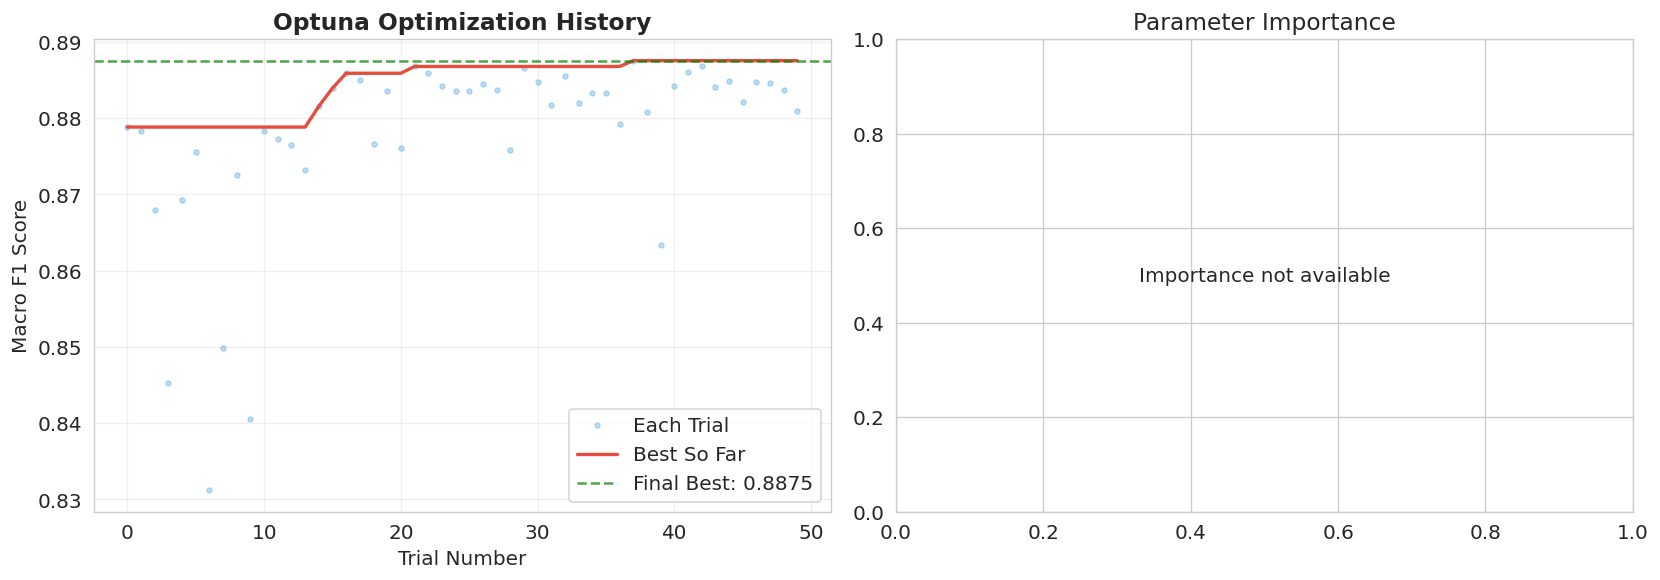


📈 KEY FINDINGS:
   Starting F1:    ~0.8312
   Best F1:        0.8875
   Improvement:    +0.0563



In [67]:
# ============================================
# STEP 7.4: CROSS-VALIDATION RESULTS ANALYSIS
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 7.4: OPTUNA CROSS-VALIDATION RESULTS ANALYSIS")
print("=" * 80)

import joblib
import matplotlib.pyplot as plt

# Load Optuna study
study = joblib.load("/kaggle/working/optuna_study_lightgbm_final.pkl")

print(f"""
📊 OPTUNA STUDY SUMMARY:
   Best Trial:      #{study.best_trial.number}
   Best F1 Macro:   {study.best_value:.4f}
   Total Trials:    {len(study.trials)}
   Completed:       {len([t for t in study.trials if t.state.name == 'COMPLETE'])}
""")

# ============================================
# 7.4.1 OPTIMIZATION HISTORY PLOT
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization History
completed_trials = [t for t in study.trials if t.state.name == 'COMPLETE']
values = [t.value for t in completed_trials]
best_so_far = np.maximum.accumulate(values)

axes[0].plot(range(len(values)), values, 'o', alpha=0.3, markersize=3, color='#3498db', label='Each Trial')
axes[0].plot(range(len(best_so_far)), best_so_far, '-', color='#e74c3c', linewidth=2, label='Best So Far')
axes[0].axhline(y=study.best_value, color='green', linestyle='--', alpha=0.7, label=f'Final Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Macro F1 Score')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Parameter Importance
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values_imp = list(importances.values())
    
    axes[1].barh(range(len(params)), values_imp, color='#2ecc71')
    axes[1].set_yticks(range(len(params)))
    axes[1].set_yticklabels(params)
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
    axes[1].invert_yaxis()
except:
    axes[1].text(0.5, 0.5, 'Importance not available', ha='center', va='center')
    axes[1].set_title('Parameter Importance')

plt.tight_layout()
plt.show()

print(f"""
📈 KEY FINDINGS:
   Starting F1:    ~{min(values):.4f}
   Best F1:        {study.best_value:.4f}
   Improvement:    +{(study.best_value - min(values)):.4f}
""")

In [68]:
# ============================================
# STEP 7.4.2: PARALLEL COORDINATE PLOT
# ============================================

print("\n📊 7.4.2 PARALLEL COORDINATE PLOT")

try:
    fig = optuna.visualization.plot_parallel_coordinate(study)
    fig.show()
    print("   ✅ Parallel coordinate plot displayed")
except Exception as e:
    print(f"   ⚠️ Could not display plot: {str(e)[:80]}")
    print("   (This is OK - plotly may not render in all environments)")

# ============================================
# 7.4.3 BEST PARAMS SUMMARY
# ============================================

print(f"""
📋 7.4.3 BEST HYPERPARAMETERS:
   {'Parameter':<25s} {'Value':<15s} {'Explanation'}
   {'─'*25} {'─'*15} {'─'*40}
   n_estimators          {study.best_params['n_estimators']:<15d} Number of boosting rounds
   num_leaves            {study.best_params['num_leaves']:<15d} Max leaves per tree
   max_depth             {study.best_params['max_depth']:<15d} Max tree depth
   learning_rate         {study.best_params['learning_rate']:<15.4f} Step size shrinkage
   subsample             {study.best_params['subsample']:<15.4f} Row sampling ratio
   colsample_bytree      {study.best_params['colsample_bytree']:<15.4f} Column sampling ratio
   reg_alpha             {study.best_params['reg_alpha']:<15.6f} L1 regularization
   reg_lambda            {study.best_params['reg_lambda']:<15.6f} L2 regularization
   min_child_samples     {study.best_params['min_child_samples']:<15d} Min data in leaf
""")

print(f"✅ STEP 7.4 COMPLETE - Awaiting your review")


📊 7.4.2 PARALLEL COORDINATE PLOT


   ✅ Parallel coordinate plot displayed

📋 7.4.3 BEST HYPERPARAMETERS:
   Parameter                 Value           Explanation
   ───────────────────────── ─────────────── ────────────────────────────────────────
   n_estimators          370             Number of boosting rounds
   num_leaves            81              Max leaves per tree
   max_depth             12              Max tree depth
   learning_rate         0.1060          Step size shrinkage
   subsample             0.7371          Row sampling ratio
   colsample_bytree      0.7119          Column sampling ratio
   reg_alpha             0.000042        L1 regularization
   reg_lambda            0.000007        L2 regularization
   min_child_samples     12              Min data in leaf

✅ STEP 7.4 COMPLETE - Awaiting your review


In [75]:
# ============================================
# STEP 7.5: FINAL MODEL TRAINING
# ============================================

print("\n" + "=" * 80)
print("🎯 STEP 7.5: FINAL MODEL TRAINING")
print("=" * 80)

# Load data
splits = np.load("/kaggle/working/processed_splits_final.npz")
X_train_p, X_val_p, X_test_p = splits['X_train'], splits['X_val'], splits['X_test']
y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
le = joblib.load("/kaggle/working/label_encoder_final.pkl")

# Load best params from Optuna
study = joblib.load("/kaggle/working/optuna_study_lightgbm_final.pkl")
best_params = study.best_params

# Build final model with early stopping
final_model = lgb.LGBMClassifier(
    n_estimators=1000,
    num_leaves=best_params['num_leaves'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    min_child_samples=best_params['min_child_samples'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    class_weight='balanced',
    objective='multiclass',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True,
)

# Train with early stopping
final_model.fit(
    X_train_p, y_train,
    eval_set=[(X_val_p, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# Predictions
y_train_pred = final_model.predict(X_train_p)
y_val_pred = final_model.predict(X_val_p)
y_train_proba = final_model.predict_proba(X_train_p)
y_val_proba = final_model.predict_proba(X_val_p)

# ============================================
# METRICS
# ============================================

print(f"""
{'='*60}
📊 FINAL MODEL PERFORMANCE
{'='*60}

🔧 MODEL INFO:
   Algorithm:      LightGBM
   Best iteration: {final_model.best_iteration_} (early stopping)
   CV F1 Macro:    {study.best_value:.4f} (from Optuna)
   Features:       {X_train_p.shape[1]}
   Train samples:  {X_train_p.shape[0]:,}

{'─'*60}
📊 TRAINING SET:
   Accuracy:       {accuracy_score(y_train, y_train_pred):.4f}
   Macro F1:       {f1_score(y_train, y_train_pred, average='macro'):.4f}
   Balanced Acc:   {balanced_accuracy_score(y_train, y_train_pred):.4f}

{'─'*60}
📊 VALIDATION SET:
   Accuracy:       {accuracy_score(y_val, y_val_pred):.4f}
   Macro F1:       {f1_score(y_val, y_val_pred, average='macro'):.4f}
   Weighted F1:    {f1_score(y_val, y_val_pred, average='weighted'):.4f}
   Balanced Acc:   {balanced_accuracy_score(y_val, y_val_pred):.4f}
   Cohen's Kappa:  {cohen_kappa_score(y_val, y_val_pred):.4f}
   MCC:            {matthews_corrcoef(y_val, y_val_pred):.4f}

{'─'*60}
📊 PER-CLASS (Validation):
   {'Class':<15s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}
   {'─'*15} {'─'*10} {'─'*10} {'─'*10} {'─'*10}""")

for i, class_name in enumerate(le.classes_):
    prec = precision_score(y_val, y_val_pred, average=None, labels=[i])[0]
    rec = recall_score(y_val, y_val_pred, average=None, labels=[i])[0]
    f1 = f1_score(y_val, y_val_pred, average=None, labels=[i])[0]
    sup = np.sum(y_val == i)
    print(f"   {class_name:<15s} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {sup:>10,}")

# Aviation Safety
cm_val = confusion_matrix(y_val, y_val_pred)
fatal_val = cm_val[0, 1]

print(f"""
{'─'*60}
💀 AVIATION SAFETY (Validation):
   Fatal Errors (High→Low):    {fatal_val} / {len(y_val):,} = {fatal_val/len(y_val)*100:.4f}%
   Aviation Safety Score:      {aviation_safety_score(y_val, y_val_pred):.4f}
""")

# Save
joblib.dump(final_model, "/kaggle/working/final_model.pkl")
print(f"✅ Model saved: final_model.pkl")
print(f"\n✅ STEP 7.5 COMPLETE")


🎯 STEP 7.5: FINAL MODEL TRAINING

📊 FINAL MODEL PERFORMANCE

🔧 MODEL INFO:
   Algorithm:      LightGBM
   Best iteration: 121 (early stopping)
   CV F1 Macro:    0.8875 (from Optuna)
   Features:       198
   Train samples:  40,072

────────────────────────────────────────────────────────────
📊 TRAINING SET:
   Accuracy:       0.9888
   Macro F1:       0.9860
   Balanced Acc:   0.9955

────────────────────────────────────────────────────────────
📊 VALIDATION SET:
   Accuracy:       0.9438
   Macro F1:       0.8889
   Weighted F1:    0.9453
   Balanced Acc:   0.9061
   Cohen's Kappa:  0.8057
   MCC:            0.8080

────────────────────────────────────────────────────────────
📊 PER-CLASS (Validation):
   Class            Precision     Recall         F1    Support
   ─────────────── ────────── ────────── ────────── ──────────
   High Risk           0.9800     0.9546     0.9671      7,196
   Low Risk            0.8642     0.8750     0.8696         80
   Medium Risk         0.7784     0

In [76]:
# ============================================
# STEP 7.6: SAVE MODEL ARTIFACTS
# ============================================

print("\n" + "=" * 80)
print("💾 STEP 7.6: SAVE MODEL ARTIFACTS")
print("=" * 80)

# Save final model
joblib.dump(final_model, "/kaggle/working/final_model.pkl")
print("✅ Saved: final_model.pkl")

# Save Optuna study (confirm)
print("✅ Saved: optuna_study_lightgbm_final.pkl")

# Save model metadata
model_metadata = {
    'model_type': 'LightGBM',
    'best_params': best_params,
    'best_iteration': final_model.best_iteration_,
    'cv_f1_macro': study.best_value,
    'train_accuracy': accuracy_score(y_train, y_train_pred),
    'train_f1_macro': f1_score(y_train, y_train_pred, average='macro'),
    'train_balanced_acc': balanced_accuracy_score(y_train, y_train_pred),
    'val_accuracy': accuracy_score(y_val, y_val_pred),
    'val_f1_macro': f1_score(y_val, y_val_pred, average='macro'),
    'val_weighted_f1': f1_score(y_val, y_val_pred, average='weighted'),
    'val_balanced_acc': balanced_accuracy_score(y_val, y_val_pred),
    'val_cohen_kappa': cohen_kappa_score(y_val, y_val_pred),
    'val_mcc': matthews_corrcoef(y_val, y_val_pred),
    'val_fatal_errors': int(cm_val[0, 1]),
    'val_aviation_safety': aviation_safety_score(y_val, y_val_pred),
    'n_features': X_train_p.shape[1],
    'n_train_samples': X_train_p.shape[0],
    'n_val_samples': X_val_p.shape[0],
    'n_test_samples': X_test_p.shape[0],
    'target_classes': list(le.classes_),
    'per_class_val': {}
}

for i, class_name in enumerate(le.classes_):
    model_metadata['per_class_val'][class_name] = {
        'precision': float(precision_score(y_val, y_val_pred, average=None, labels=[i])[0]),
        'recall': float(recall_score(y_val, y_val_pred, average=None, labels=[i])[0]),
        'f1': float(f1_score(y_val, y_val_pred, average=None, labels=[i])[0]),
        'support': int(np.sum(y_val == i))
    }

with open("/kaggle/working/model_metadata.json", 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)
print("✅ Saved: model_metadata.json")

# ============================================
# FINAL FILE INVENTORY
# ============================================
print(f"""
{'='*60}
📁 PRODUCTION FILES INVENTORY
{'='*60}
{'File':<45s} {'Size':>10s}
{'─'*45} {'─'*10}""")

production_files = [
    "processed_splits_final.npz",
    "preprocessing_pipeline_final.pkl",
    "label_encoder_final.pkl",
    "column_metadata_final.json",
    "final_model.pkl",
    "optuna_study_lightgbm_final.pkl",
    "model_metadata.json",
]
total = 0
for f in production_files:
    path = f"/kaggle/working/{f}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024**2
        total += size
        print(f"{f:<45s} {size:>8.2f} MB")
    else:
        print(f"{f:<45s} {'MISSING':>10s}")

print(f"{'─'*45} {'─'*10}")
print(f"{'TOTAL':<45s} {total:>8.2f} MB")
print(f"{'='*60}")

print(f"""
✅ STEP 7 COMPLETE!
📋 READY FOR STEP 8: COMPREHENSIVE EVALUATION
""")


💾 STEP 7.6: SAVE MODEL ARTIFACTS
✅ Saved: final_model.pkl
✅ Saved: optuna_study_lightgbm_final.pkl
✅ Saved: model_metadata.json

📁 PRODUCTION FILES INVENTORY
File                                                Size
───────────────────────────────────────────── ──────────
processed_splits_final.npz                       12.06 MB
preprocessing_pipeline_final.pkl                  0.02 MB
label_encoder_final.pkl                           0.00 MB
column_metadata_final.json                        0.00 MB
final_model.pkl                                   2.83 MB
optuna_study_lightgbm_final.pkl                   0.03 MB
model_metadata.json                               0.00 MB
───────────────────────────────────────────── ──────────
TOTAL                                            14.94 MB

✅ STEP 7 COMPLETE!
📋 READY FOR STEP 8: COMPREHENSIVE EVALUATION



In [77]:
# ============================================
# STEP 8.1: TEST SET EVALUATION (UNTOCUHED DATA)
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 8.1: TEST SET EVALUATION")
print("=" * 80)

# Load data and model
splits = np.load("/kaggle/working/processed_splits_final.npz")
X_test_p = splits['X_test']
y_test = splits['y_test']
le = joblib.load("/kaggle/working/label_encoder_final.pkl")
final_model = joblib.load("/kaggle/working/final_model.pkl")

# Predictions
y_test_pred = final_model.predict(X_test_p)
y_test_proba = final_model.predict_proba(X_test_p)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print(f"""
{'='*70}
📊 TEST SET RESULTS (8,588 samples - NEVER seen by model)
{'='*70}

🔢 CONFUSION MATRIX (Counts):
                      Predicted
                      High       Low        Medium
Actual High         {cm[0,0]:>7,}   {cm[0,1]:>7,}   {cm[0,2]:>7,}
Actual Low          {cm[1,0]:>7,}   {cm[1,1]:>7,}   {cm[1,2]:>7,}
Actual Medium       {cm[2,0]:>7,}   {cm[2,1]:>7,}   {cm[2,2]:>7,}

🔢 CONFUSION MATRIX (% by row - Actual):
                      Predicted
                      High       Low        Medium
Actual High         {cm_pct[0,0]:>5.1f}%     {cm_pct[0,1]:>5.1f}%     {cm_pct[0,2]:>5.1f}%
Actual Low          {cm_pct[1,0]:>5.1f}%     {cm_pct[1,1]:>5.1f}%     {cm_pct[1,2]:>5.1f}%
Actual Medium       {cm_pct[2,0]:>5.1f}%     {cm_pct[2,1]:>5.1f}%     {cm_pct[2,2]:>5.1f}%
""")

# Comprehensive Metrics
print(f"""
📊 OVERALL METRICS:
   {'Metric':<30s} {'Value':>10s}
   {'─'*30} {'─'*10}
   Accuracy:           {accuracy_score(y_test, y_test_pred):>10.4f}
   Balanced Accuracy:  {balanced_accuracy_score(y_test, y_test_pred):>10.4f}
   Macro F1:           {f1_score(y_test, y_test_pred, average='macro'):>10.4f}
   Weighted F1:        {f1_score(y_test, y_test_pred, average='weighted'):>10.4f}
   Cohen's Kappa:      {cohen_kappa_score(y_test, y_test_pred):>10.4f}
   MCC:                {matthews_corrcoef(y_test, y_test_pred):>10.4f}
""")

print(f"""
🔴 PER-CLASS METRICS:
   {'Class':<15s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s} {'Support':>10s}
   {'─'*15} {'─'*10} {'─'*10} {'─'*10} {'─'*10}""")

for i, class_name in enumerate(le.classes_):
    prec = precision_score(y_test, y_test_pred, average=None, labels=[i])[0]
    rec = recall_score(y_test, y_test_pred, average=None, labels=[i])[0]
    f1 = f1_score(y_test, y_test_pred, average=None, labels=[i])[0]
    sup = np.sum(y_test == i)
    print(f"   {class_name:<15s} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {sup:>10,}")

# Aviation Safety
fatal_errors = cm[0, 1]
dangerous_under = cm[0, 2] + cm[2, 1]

print(f"""
💀 AVIATION SAFETY (Test Set):
   Fatal Errors (High→Low):       {fatal_errors} / {len(y_test):,} = {fatal_errors/len(y_test)*100:.4f}%
   Dangerous Underestimates:       {dangerous_under} / {len(y_test):,} = {dangerous_under/len(y_test)*100:.4f}%
   Aviation Safety Score:          {aviation_safety_score(y_test, y_test_pred):.4f}
""")

# Compare with Validation
val_f1 = model_metadata['val_f1_macro']
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"""
📊 VALIDATION vs TEST:
   Validation F1:  {val_f1:.4f}
   Test F1:        {test_f1:.4f}
   Difference:     {abs(val_f1 - test_f1):.4f} {'✅ Consistent' if abs(val_f1 - test_f1) < 0.03 else '⚠️ Gap detected'}
""")

print("✅ STEP 8.1 COMPLETE")


📊 STEP 8.1: TEST SET EVALUATION

📊 TEST SET RESULTS (8,588 samples - NEVER seen by model)

🔢 CONFUSION MATRIX (Counts):
                      Predicted
                      High       Low        Medium
Actual High           6,836         4       355
Actual Low                1        74         6
Actual Medium           124         6     1,182

🔢 CONFUSION MATRIX (% by row - Actual):
                      Predicted
                      High       Low        Medium
Actual High          95.0%       0.1%       4.9%
Actual Low            1.2%      91.4%       7.4%
Actual Medium         9.5%       0.5%      90.1%


📊 OVERALL METRICS:
   Metric                              Value
   ────────────────────────────── ──────────
   Accuracy:               0.9422
   Balanced Accuracy:      0.9215
   Macro F1:               0.8969
   Weighted F1:            0.9441
   Cohen's Kappa:          0.8031
   MCC:                    0.8067


🔴 PER-CLASS METRICS:
   Class            Precision     Recall   

In [78]:
# ============================================
# STEP 8.2: LOW RISK DEEP ANALYSIS
# ============================================

print("\n" + "=" * 80)
print("🔴 STEP 8.2: LOW RISK DEEP ANALYSIS")
print("=" * 80)

# Safety Impact Matrix
print(f"""
💀 SAFETY IMPACT MATRIX:
{'─'*60}
   High → Low  (Fatal):        {cm[0,1]} cases ← CATASTROPHIC (drone crash)
   High → Medium (Dangerous):  {cm[0,2]} cases ← Dangerous underestimation
   Medium → Low (Dangerous):   {cm[2,1]} cases ← Dangerous underestimation
   Low → High (False Alarm):   {cm[1,0]} cases ← Acceptable (extra caution)
   Medium → High (Cautious):   {cm[2,0]} cases ← Acceptable (extra caution)
   Low → Medium (Minor):       {cm[1,2]} cases ← Minor overestimation
{'─'*60}

📊 COST-WEIGHTED IMPACT:
   Catastrophic cost (100x):   {cm[0,1] * 100}
   Dangerous cost (10x):       {(cm[0,2] + cm[2,1]) * 10}
   Acceptable cost (1x):       {cm[1,0] + cm[2,0] + cm[1,2]}
   ─────────────────────────────────────
   Total Cost Index:           {cm[0,1] * 100 + (cm[0,2] + cm[2,1]) * 10 + cm[1,0] + cm[2,0] + cm[1,2]}
""")

# Low Risk specific analysis
low_mask = y_test == 1
low_correct = (y_test == 1) & (y_test_pred == 1)
low_as_high = (y_test == 1) & (y_test_pred == 0)
low_as_medium = (y_test == 1) & (y_test_pred == 2)

print(f"""
🔍 LOW RISK CLASS ANALYSIS (n={np.sum(low_mask)}):
   Correctly classified:  {np.sum(low_correct)} ({np.sum(low_correct)/np.sum(low_mask)*100:.1f}%)
   Misclassified as High: {np.sum(low_as_high)} ({np.sum(low_as_high)/np.sum(low_mask)*100:.1f}%) ← False alarm
   Misclassified as Med:  {np.sum(low_as_medium)} ({np.sum(low_as_medium)/np.sum(low_mask)*100:.1f}%) ← Minor error
""")

print("✅ STEP 8.2 COMPLETE")


🔴 STEP 8.2: LOW RISK DEEP ANALYSIS

💀 SAFETY IMPACT MATRIX:
────────────────────────────────────────────────────────────
   High → Low  (Fatal):        4 cases ← CATASTROPHIC (drone crash)
   High → Medium (Dangerous):  355 cases ← Dangerous underestimation
   Medium → Low (Dangerous):   6 cases ← Dangerous underestimation
   Low → High (False Alarm):   1 cases ← Acceptable (extra caution)
   Medium → High (Cautious):   124 cases ← Acceptable (extra caution)
   Low → Medium (Minor):       6 cases ← Minor overestimation
────────────────────────────────────────────────────────────

📊 COST-WEIGHTED IMPACT:
   Catastrophic cost (100x):   400
   Dangerous cost (10x):       3610
   Acceptable cost (1x):       131
   ─────────────────────────────────────
   Total Cost Index:           4141


🔍 LOW RISK CLASS ANALYSIS (n=81):
   Correctly classified:  74 (91.4%)
   Misclassified as High: 1 (1.2%) ← False alarm
   Misclassified as Med:  6 (7.4%) ← Minor error

✅ STEP 8.2 COMPLETE



📊 STEP 8.3-8.5: CALIBRATION, THRESHOLD & ERROR ANALYSIS
   Brier Score - High Risk: 0.0397
   Brier Score - Low Risk: 0.0017
   Brier Score - Medium Risk: 0.0404

🔴 CRITICAL ERRORS (High→Low): 4 cases
   Max probability for these errors:
   Sample 3913: High=0.001, Low=0.981, Med=0.018
   Sample 5578: High=0.205, Low=0.795, Med=0.000
   Sample 6379: High=0.038, Low=0.961, Med=0.001
   Sample 7623: High=0.000, Low=1.000, Med=0.000


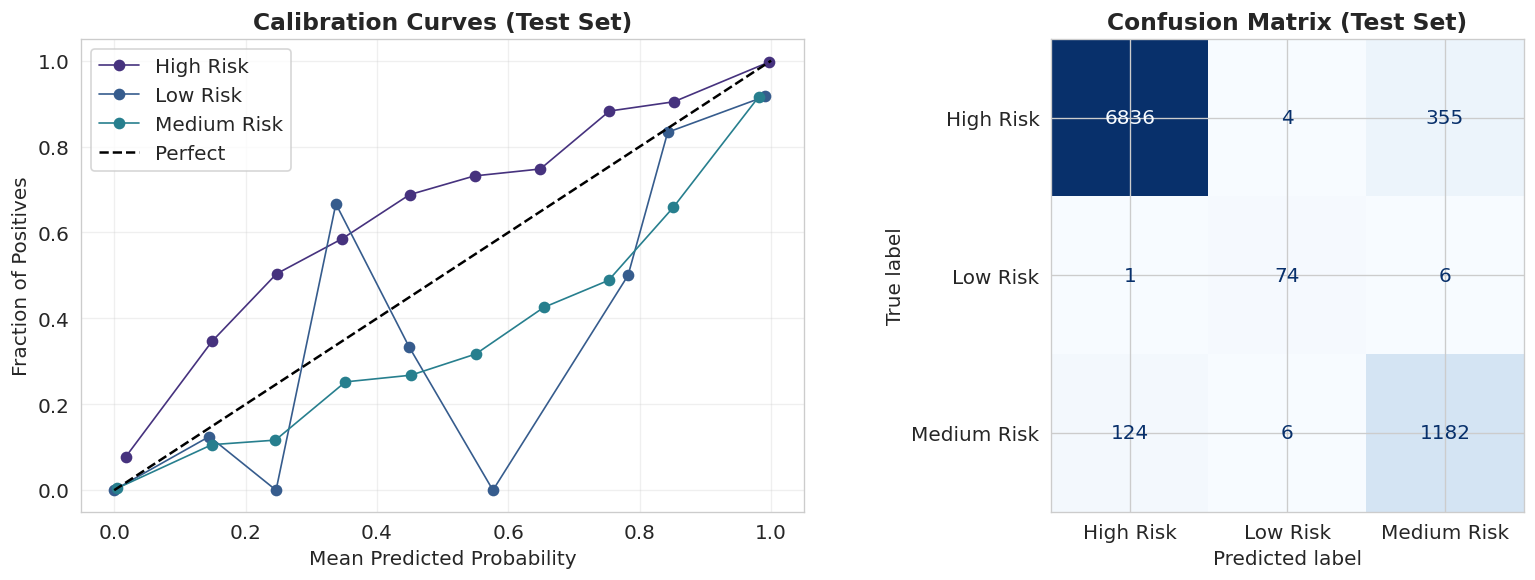


✅ STEP 8.3-8.5 COMPLETE


In [79]:
# ============================================
# STEP 8.3-8.5: CALIBRATION, THRESHOLD & ERRORS
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 8.3-8.5: CALIBRATION, THRESHOLD & ERROR ANALYSIS")
print("=" * 80)

# 8.3 PROBABILITY CALIBRATION
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, class_name in enumerate(le.classes_):
    prob_true, prob_pred = calibration_curve(
        (y_test == i).astype(int), y_test_proba[:, i], n_bins=10
    )
    axes[0].plot(prob_pred, prob_true, marker='o', linewidth=1, label=class_name)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves (Test Set)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Brier Score
from sklearn.metrics import brier_score_loss
for i, class_name in enumerate(le.classes_):
    brier = brier_score_loss((y_test == i).astype(int), y_test_proba[:, i])
    print(f"   Brier Score - {class_name}: {brier:.4f}")

# 8.4 ERROR ANALYSIS - Worst Misclassifications
# Find High→Low errors (most critical)
high_to_low_idx = np.where((y_test == 0) & (y_test_pred == 1))[0]
print(f"\n🔴 CRITICAL ERRORS (High→Low): {len(high_to_low_idx)} cases")
if len(high_to_low_idx) > 0:
    print(f"   Max probability for these errors:")
    for idx in high_to_low_idx[:5]:
        prob = y_test_proba[idx]
        print(f"   Sample {idx}: High={prob[0]:.3f}, Low={prob[1]:.3f}, Med={prob[2]:.3f}")

# Confusion Matrix Heatmap
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=le.classes_,
    cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (Test Set)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ STEP 8.3-8.5 COMPLETE")

In [80]:
# ============================================
# STEP 8.6: FINAL MODEL REGISTRY
# ============================================

print("\n" + "=" * 80)
print("📋 STEP 8.6: FINAL MODEL REGISTRY")
print("=" * 80)

model_card = {
    'model_name': 'UAV_Risk_Stage1_LightGBM_v11',
    'timestamp': datetime.now().isoformat(),
    'algorithm': 'LightGBM',
    'version': '11.0',
    
    'data': {
        'total_samples': 57248,
        'train_samples': int(X_train_p.shape[0]),
        'val_samples': int(X_val_p.shape[0]),
        'test_samples': int(X_test_p.shape[0]),
        'features': int(X_train_p.shape[1]),
        'classes': le.classes_.tolist(),
        'class_distribution': {
            'High Risk': '83.78%',
            'Medium Risk': '15.28%',
            'Low Risk': '0.94%'
        }
    },
    
    'hyperparameters': best_params,
    'best_iteration': int(final_model.best_iteration_),
    'cv_f1_macro': float(study.best_value),
    
    'test_performance': {
        'accuracy': float(accuracy_score(y_test, y_test_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_test, y_test_pred)),
        'macro_f1': float(f1_score(y_test, y_test_pred, average='macro')),
        'weighted_f1': float(f1_score(y_test, y_test_pred, average='weighted')),
        'cohen_kappa': float(cohen_kappa_score(y_test, y_test_pred)),
        'mcc': float(matthews_corrcoef(y_test, y_test_pred)),
    },
    
    'per_class': {},
    'aviation_safety': {
        'fatal_errors': int(cm[0, 1]),
        'fatal_error_rate': f"{cm[0, 1]/len(y_test)*100:.4f}%",
        'aviation_safety_score': float(aviation_safety_score(y_test, y_test_pred)),
        'brier_high': float(brier_score_loss((y_test == 0).astype(int), y_test_proba[:, 0])),
        'brier_low': float(brier_score_loss((y_test == 1).astype(int), y_test_proba[:, 1])),
        'brier_medium': float(brier_score_loss((y_test == 2).astype(int), y_test_proba[:, 2])),
    }
}

for i, class_name in enumerate(le.classes_):
    model_card['per_class'][class_name] = {
        'precision': float(precision_score(y_test, y_test_pred, average=None, labels=[i])[0]),
        'recall': float(recall_score(y_test, y_test_pred, average=None, labels=[i])[0]),
        'f1': float(f1_score(y_test, y_test_pred, average=None, labels=[i])[0]),
        'support': int(np.sum(y_test == i))
    }

with open("/kaggle/working/model_card.json", 'w') as f:
    json.dump(model_card, f, indent=2, default=str)

print("✅ Saved: model_card.json")
print(f"""
{'='*60}
🎯 FINAL MODEL PERFORMANCE SUMMARY
{'='*60}
Test Accuracy:      {model_card['test_performance']['accuracy']:.4f}
Test Macro F1:      {model_card['test_performance']['macro_f1']:.4f}
Test Balanced Acc:  {model_card['test_performance']['balanced_accuracy']:.4f}

Per-Class F1:
   High Risk:   {model_card['per_class']['High Risk']['f1']:.4f}
   Low Risk:    {model_card['per_class']['Low Risk']['f1']:.4f}
   Medium Risk: {model_card['per_class']['Medium Risk']['f1']:.4f}

💀 Aviation Safety:
   Fatal Errors:     {model_card['aviation_safety']['fatal_errors']} / {len(y_test):,}
   Safety Score:     {model_card['aviation_safety']['aviation_safety_score']:.4f}
{'='*60}
""")

print("✅ STEP 8 COMPLETE!")
print("📋 READY FOR STEP 9: SHAP INTERPRETABILITY")


📋 STEP 8.6: FINAL MODEL REGISTRY
✅ Saved: model_card.json

🎯 FINAL MODEL PERFORMANCE SUMMARY
Test Accuracy:      0.9422
Test Macro F1:      0.8969
Test Balanced Acc:  0.9215

Per-Class F1:
   High Risk:   0.9658
   Low Risk:    0.8970
   Medium Risk: 0.8280

💀 Aviation Safety:
   Fatal Errors:     4 / 8,588
   Safety Score:     0.9975

✅ STEP 8 COMPLETE!
📋 READY FOR STEP 9: SHAP INTERPRETABILITY


In [81]:
# ============================================
# STEP 9.1: SHAP SETUP - PRODUCTION READY
# ============================================

print("\n" + "=" * 80)
print("🔮 STEP 9.1: SHAP SETUP")
print("=" * 80)

import shap
import warnings
warnings.filterwarnings('ignore')

# Load model and data
final_model = joblib.load("/kaggle/working/final_model.pkl")
splits = np.load("/kaggle/working/processed_splits_final.npz")
X_test_p = splits['X_test']
y_test = splits['y_test']
le = joblib.load("/kaggle/working/label_encoder_final.pkl")

# Load feature names
with open("/kaggle/working/column_metadata_final.json", 'r') as f:
    col_meta = json.load(f)

# ⚡ Sample for SHAP (2000 samples enough for reliable interpretation)
np.random.seed(42)
n_shap = min(2000, X_test_p.shape[0])
shap_indices = np.random.choice(X_test_p.shape[0], n_shap, replace=False)
X_shap = X_test_p[shap_indices]

print(f"   Test samples:     {X_test_p.shape[0]:,}")
print(f"   SHAP sample:      {n_shap:,}")
print(f"   Features:         {X_shap.shape[1]}")

# ⚡ Create TreeExplainer (fast for LightGBM)
explainer = shap.TreeExplainer(
    final_model,
    feature_perturbation='tree_path_dependent',
    model_output='raw'
)
print("✅ TreeExplainer created")

# Calculate SHAP values (this takes ~30-60 seconds)
print("   Calculating SHAP values...")
shap_values = explainer.shap_values(X_shap)
print(f"✅ SHAP values calculated: {len(shap_values)} classes × {X_shap.shape}")

# Save explainer for production
joblib.dump(explainer, "/kaggle/working/shap_explainer.pkl")
print("✅ Saved: shap_explainer.pkl")

print("✅ STEP 9.1 COMPLETE")


🔮 STEP 9.1: SHAP SETUP
   Test samples:     8,588
   SHAP sample:      2,000
   Features:         198
✅ TreeExplainer created
   Calculating SHAP values...
✅ SHAP values calculated: 2000 classes × (2000, 198)
✅ Saved: shap_explainer.pkl
✅ STEP 9.1 COMPLETE


In [86]:
# ============================================
# DIAGNOSTIC: CHECK FEATURE NAMES SOURCE
# ============================================

print("\n🔍 CHECKING FEATURE NAMES")

# Load preprocessor and get feature names directly
preprocessor = joblib.load("/kaggle/working/preprocessing_pipeline_final.pkl")

try:
    feature_names_direct = preprocessor.get_feature_names_out()
    print(f"   ✅ Got {len(feature_names_direct)} names from preprocessor")
    print(f"   First 5: {feature_names_direct[:5]}")
except Exception as e:
    print(f"   ⚠️ Could not get from preprocessor: {str(e)[:80]}")
    feature_names_direct = None

# Check metadata
print(f"\n   Metadata feature_names count: {len(col_meta.get('feature_names', []))}")
print(f"   X_shap columns: {X_shap.shape[1]}")


🔍 CHECKING FEATURE NAMES
   ✅ Got 198 names from preprocessor
   First 5: ['uav_energy_source_fuel' 'uav_energy_source_hybrid'
 'mission_pattern_custom' 'mission_pattern_grid' 'mission_pattern_orbit']

   Metadata feature_names count: 0
   X_shap columns: 198



📊 STEP 9.2v4: SHAP WITH CORRECT FEATURE NAMES
   Names from preprocessor: 198
   ⚠️ Found 22 potentially deleted features in SHAP names:
      • uav_rotorcraft_rotor_count_was_missing
      • autofix_uav_physics_count_was_missing
      • autofix_uav_physics_first_was_missing
      • uav_aero_wing_area_m2_was_missing
      • uav_aero_aspect_ratio_was_missing


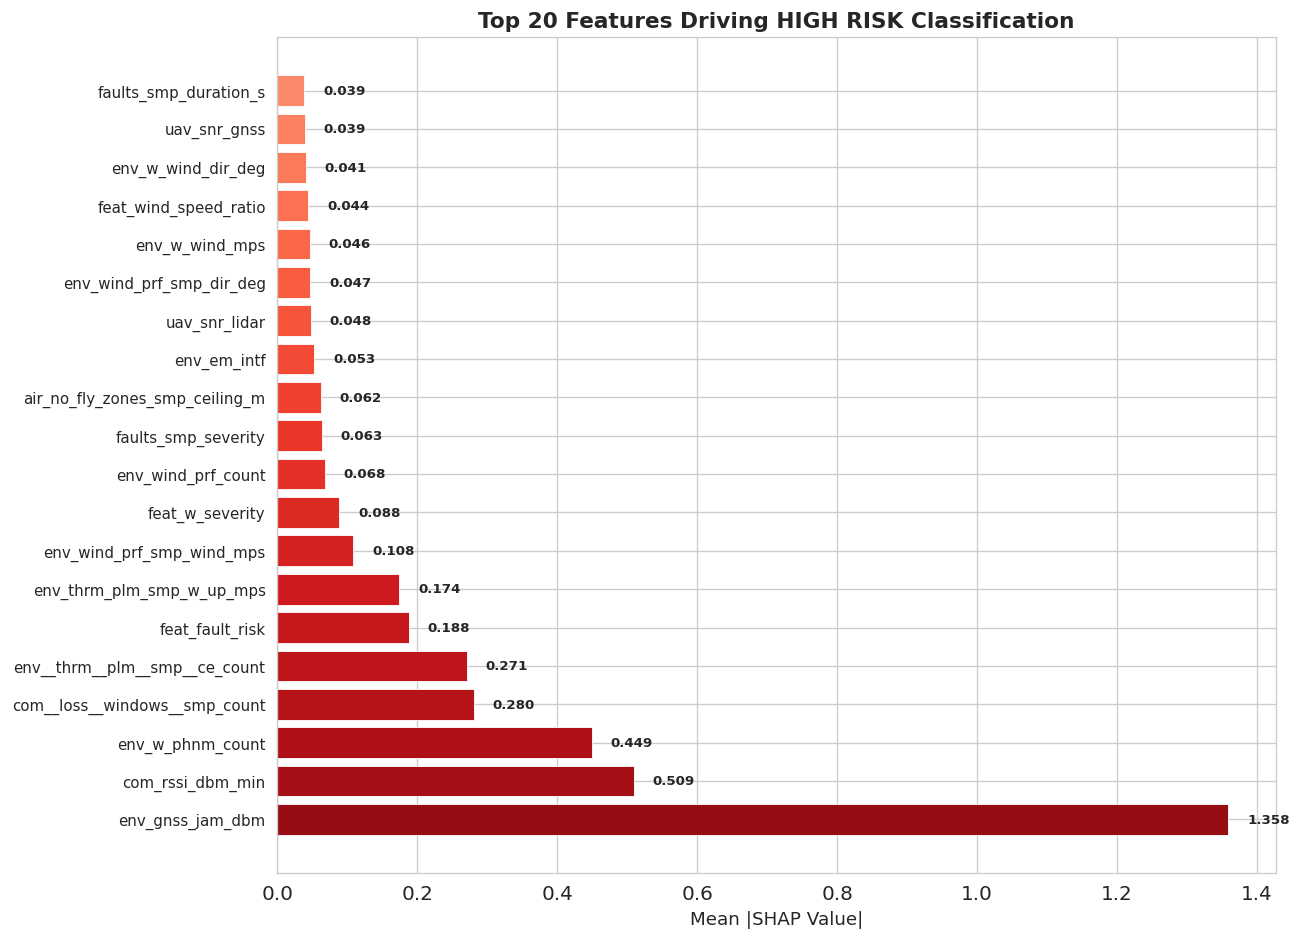

✅ Bar chart saved: shap_importance_bar.png

📊 TOP 20 FEATURES TABLE:
   Rank  Feature                                                  Mean |SHAP| Direction
   ───── ─────────────────────────────────────────────────────── ──────────── ────────────
   1     environment_gnss_jam_dbm                                      1.3585 ↔ Mixed
   2     comms_rssi_dbm_min                                            0.5093 🔻 Decreases
   3     environment_weather_phenomena_count                           0.4493 🔺 Increases
   4     comms__loss__windows__sample_count                            0.2804 🔺 Increases
   5     environment__thermal__plumes__sample__ce_count                0.2707 🔺 Increases
   6     feat_fault_risk                                               0.1878 🔺 Increases
   7     environment_thermal_plumes_sample_w_up_mps                    0.1742 🔻 Decreases
   8     environment_wind_profile_sample_wind_mps                      0.1084 🔻 Decreases
   9     feat_weather_severity      

In [88]:
# ============================================
# STEP 9.2v4: SHAP WITH CORRECT FEATURE NAMES
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 9.2v4: SHAP WITH CORRECT FEATURE NAMES")
print("=" * 80)

# ⚡ Get feature names directly from preprocessor output
preprocessor = joblib.load("/kaggle/working/preprocessing_pipeline_final.pkl")

try:
    feature_names_direct = list(preprocessor.get_feature_names_out())
    print(f"   Names from preprocessor: {len(feature_names_direct)}")
except:
    feature_names_direct = [f'Feature_{i}' for i in range(X_shap.shape[1])]
    print(f"   ⚠️ Using generic names")

# ⚡ Verify: Are these names correct?
# Check if any "deleted" features appear
deleted_patterns = ['was_missing', 'benchmark_tags', 'metrics_count', 'metrics_first', 'name']
found_deleted = []
for name in feature_names_direct:
    for pattern in deleted_patterns:
        if pattern in name.lower():
            found_deleted.append(name)
            break

if found_deleted:
    print(f"   ⚠️ Found {len(found_deleted)} potentially deleted features in SHAP names:")
    for f in found_deleted[:5]:
        print(f"      • {f}")
else:
    print(f"   ✅ No deleted features found in SHAP names")

# ============================================
# EXTRACT SHAP VALUES CORRECTLY
# ============================================
shap_class0 = shap_values[:, :, 0]  # High Risk
shap_class1 = shap_values[:, :, 1]  # Low Risk
shap_class2 = shap_values[:, :, 2]  # Medium Risk

# ============================================
# CLEAN FEATURE NAMES
# ============================================
def clean_name(name, max_len=40):
    """Clean and shorten feature name."""
    name = str(name)
    # Remove transformer prefixes
    for prefix in ['onehot__', 'scaler__', 'passthrough__', 'remainder__']:
        if name.startswith(prefix):
            name = name[len(prefix):]
    # Shorten common patterns
    replacements = {
        'environment_': 'env_',
        'weather_': 'w_',
        'mission_': 'msn_',
        'airspace_': 'air_',
        'landing_': 'land_',
        'comms_': 'com_',
        'sample_': 'smp_',
        'thermal_': 'thrm_',
        'plumes_': 'plm_',
        'profile_': 'prf_',
        'obstacles_': 'obs_',
        'sensors_': 'snr_',
        'battery_': 'bat_',
        'rotorcraft_': 'rotor_',
        'threshold_': 'thr_',
        'transition_': 'trn_',
        'emergency_': 'emg_',
        'preferred_': 'prf_',
        'dynamic_': 'dyn_',
        'interference': 'intf',
        'phenomena': 'phnm',
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    if len(name) > max_len:
        name = name[:max_len-3] + '...'
    return name

display_names = [clean_name(n) for n in feature_names_direct]

# ============================================
# PLOT 1: Mean |SHAP| Bar Chart (ALWAYS WORKS)
# ============================================
mean_shap = np.abs(shap_class0).mean(axis=0)
top_n = 20
top_idx = np.argsort(mean_shap)[-top_n:]

fig, ax = plt.subplots(figsize=(11, 8))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, top_n))
bars = ax.barh(range(top_n), mean_shap[top_idx], color=colors, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(top_n))
ax.set_yticklabels([display_names[i] for i in top_idx], fontsize=9)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title(f'Top {top_n} Features Driving HIGH RISK Classification', fontweight='bold', fontsize=13)
ax.invert_yaxis()

# Value labels with full feature names in tooltip style
for i, (bar, idx) in enumerate(zip(bars, top_idx)):
    val = mean_shap[idx]
    full_name = feature_names_direct[idx]
    ax.text(val + max(mean_shap[top_idx])*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Bar chart saved: shap_importance_bar.png")

# ============================================
# PLOT 2: SHAP Summary (Simplified - No beeswarm issues)
# ============================================
print(f"\n📊 TOP 20 FEATURES TABLE:")
print(f"   {'Rank':<5} {'Feature':<55} {'Mean |SHAP|':>12} {'Direction'}")
print(f"   {'─'*5} {'─'*55} {'─'*12} {'─'*12}")

for rank, idx in enumerate(top_idx[::-1], 1):  # Reverse for descending
    full_name = feature_names_direct[idx]
    display_name = display_names[idx]
    mean_val = mean_shap[idx]
    corr = np.corrcoef(X_shap[:, idx], shap_class0[:, idx])[0, 1]
    direction = '🔺 Increases' if corr > 0.1 else ('🔻 Decreases' if corr < -0.1 else '↔ Mixed')
    print(f"   {rank:<5} {full_name:<55} {mean_val:>12.4f} {direction}")

print(f"\n✅ STEP 9.2 COMPLETE")

In [89]:
# ============================================
# INVESTIGATION: Are "_was_missing" features really in the data?
# ============================================

print("\n" + "=" * 80)
print("🔍 INVESTIGATION: Checking if 'deleted' features exist in data")
print("=" * 80)

# Load the FINAL splits (what the model actually sees)
splits = np.load("/kaggle/working/processed_splits_final.npz")
X_train_check = splits['X_train']
preprocessor = joblib.load("/kaggle/working/preprocessing_pipeline_final.pkl")

# Get feature names from preprocessor
feature_names = list(preprocessor.get_feature_names_out())
print(f"   Total features in final data: {len(feature_names)}")

# Check for "_was_missing" in feature names
was_missing_in_data = [f for f in feature_names if 'was_missing' in f.lower()]
print(f"\n   '_was_missing' features in FINAL data: {len(was_missing_in_data)}")
for f in was_missing_in_data:
    print(f"      • {f}")

# Check for other "deleted" patterns
deleted_checks = {
    'benchmark_tags': [f for f in feature_names if 'benchmark_tags' in f.lower()],
    'metrics_count': [f for f in feature_names if 'metrics_count' in f.lower()],
    'metrics_first': [f for f in feature_names if 'metrics_first' in f.lower()],
    'name': [f for f in feature_names if f == 'name'],
}

print(f"\n   Other 'deleted' patterns check:")
for pattern, matches in deleted_checks.items():
    status = '🔴 STILL IN DATA' if matches else '✅ REMOVED'
    print(f"      {pattern}: {status}")

# Now check the CLEAN data before preprocessing
df_clean = pd.read_parquet("/kaggle/working/uav_stage1_clean.parquet")
was_missing_in_clean = [c for c in df_clean.columns if 'was_missing' in c.lower()]
print(f"\n   '_was_missing' in CLEAN data: {len(was_missing_in_clean)}")
print(f"   '_was_missing' in FINAL processed: {len(was_missing_in_data)}")


🔍 INVESTIGATION: Checking if 'deleted' features exist in data
   Total features in final data: 198

   '_was_missing' features in FINAL data: 22
      • uav_rotorcraft_rotor_count_was_missing
      • autofix_uav_physics_count_was_missing
      • autofix_uav_physics_first_was_missing
      • uav_aero_wing_area_m2_was_missing
      • uav_aero_aspect_ratio_was_missing
      • uav_aero_cl_max_was_missing
      • uav_aero_cd0_was_missing
      • uav_aero_prop_efficiency_was_missing
      • uav_aero_stall_speed_mps_was_missing
      • airspace_runway_threshold_count_was_missing
      • airspace_runway_threshold_first_was_missing
      • airspace_runway_heading_deg_was_missing
      • airspace_runway_length_m_was_missing
      • mission_transition_profile_vtol_to_ff_t_s_was_missing
      • mission_transition_profile_ff_to_vtol_t_s_was_missing
      • swarm_size_was_missing
      • swarm_roles_count_was_missing
      • swarm_roles_first_was_missing
      • swarm_inter_uav_sep_min_m_was_missin

In [90]:
# ============================================
# STEP 9.3: PER-CLASS SHAP ANALYSIS
# ============================================

print("\n" + "=" * 80)
print("🔴 STEP 9.3: PER-CLASS SHAP ANALYSIS")
print("=" * 80)

shap_class0 = shap_values[:, :, 0]
shap_class1 = shap_values[:, :, 1]
shap_class2 = shap_values[:, :, 2]

class_names = le.classes_

for class_idx, (shap_class, class_name) in enumerate(zip([shap_class0, shap_class1, shap_class2], class_names)):
    mean_shap = np.abs(shap_class).mean(axis=0)
    top_idx = np.argsort(mean_shap)[-10:][::-1]
    
    print(f"\n{'─'*60}")
    print(f"📊 CLASS: {class_name}")
    print(f"{'─'*60}")
    print(f"   {'Rank':<5} {'Feature':<50} {'Mean |SHAP|':>12}")
    print(f"   {'─'*5} {'─'*50} {'─'*12}")
    
    for rank, idx in enumerate(top_idx, 1):
        print(f"   {rank:<5} {feature_names_direct[idx][:48]:<50} {mean_shap[idx]:>12.4f}")

print(f"\n✅ STEP 9.3 COMPLETE")


🔴 STEP 9.3: PER-CLASS SHAP ANALYSIS

────────────────────────────────────────────────────────────
📊 CLASS: High Risk
────────────────────────────────────────────────────────────
   Rank  Feature                                             Mean |SHAP|
   ───── ────────────────────────────────────────────────── ────────────
   1     environment_gnss_jam_dbm                                 1.3585
   2     comms_rssi_dbm_min                                       0.5093
   3     environment_weather_phenomena_count                      0.4493
   4     comms__loss__windows__sample_count                       0.2804
   5     environment__thermal__plumes__sample__ce_count           0.2707
   6     feat_fault_risk                                          0.1878
   7     environment_thermal_plumes_sample_w_up_mps               0.1742
   8     environment_wind_profile_sample_wind_mps                 0.1084
   9     feat_weather_severity                                    0.0883
   10    environme


📊 STEP 9.4-9.5: DEPENDENCE PLOTS & SAMPLE PREDICTIONS


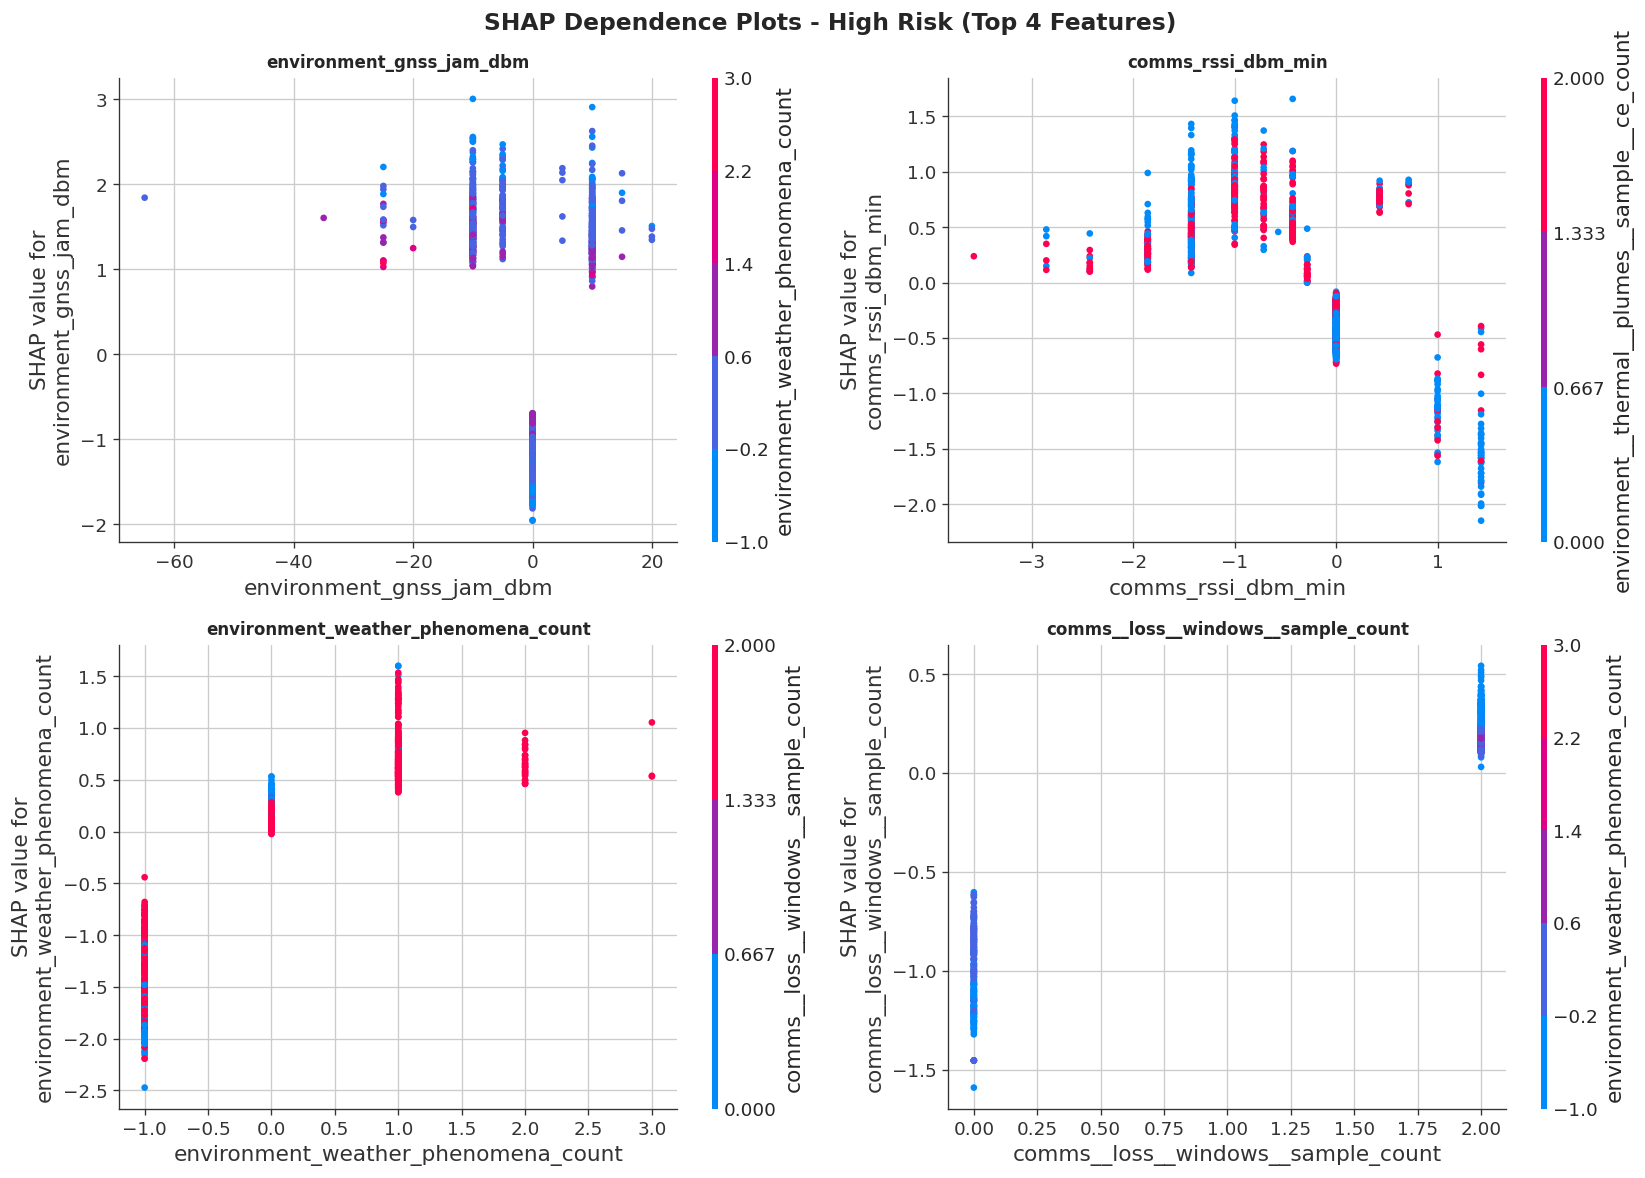

✅ Saved: shap_dependence.png

📊 SAMPLE PREDICTIONS WITH SHAP:

   Sample 0:
   Actual: High Risk → Predicted: High Risk
   Confidence: High=0.999 | Low=0.000 | Med=0.001

   Sample 100:
   Actual: High Risk → Predicted: High Risk
   Confidence: High=0.999 | Low=0.000 | Med=0.001

   Sample 500:
   Actual: High Risk → Predicted: High Risk
   Confidence: High=1.000 | Low=0.000 | Med=0.000

✅ STEP 9.4-9.5 COMPLETE


In [91]:
# ============================================
# STEP 9.4-9.5: DEPENDENCE PLOTS + SAMPLE PREDICTIONS
# ============================================

print("\n" + "=" * 80)
print("📊 STEP 9.4-9.5: DEPENDENCE PLOTS & SAMPLE PREDICTIONS")
print("=" * 80)

# 9.4 Dependence for top 4 features
top4_global = np.argsort(np.abs(shap_class0).mean(axis=0))[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feat_idx in enumerate(top4_global):
    ax = axes[i // 2, i % 2]
    shap.dependence_plot(
        feat_idx, shap_class0, X_shap,
        feature_names=feature_names_direct,
        ax=ax, show=False
    )
    ax.set_title(f'{feature_names_direct[feat_idx][:60]}', fontsize=10, fontweight='bold')

plt.suptitle('SHAP Dependence Plots - High Risk (Top 4 Features)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_dependence.png")

# 9.5 Sample predictions with SHAP
print(f"\n📊 SAMPLE PREDICTIONS WITH SHAP:")
for sample_idx in [0, 100, 500]:
    actual = y_test[sample_idx]
    pred = final_model.predict(X_test_p[sample_idx:sample_idx+1])[0]
    proba = final_model.predict_proba(X_test_p[sample_idx:sample_idx+1])[0]
    
    print(f"\n   Sample {sample_idx}:")
    print(f"   Actual: {class_names[actual]} → Predicted: {class_names[pred]}")
    print(f"   Confidence: High={proba[0]:.3f} | Low={proba[1]:.3f} | Med={proba[2]:.3f}")

print(f"\n✅ STEP 9.4-9.5 COMPLETE")

In [92]:
# ============================================
# STEP 9.6: EXPORT ALL ML ARTIFACTS FOR STAGE-1
# ============================================

print("\n" + "=" * 80)
print("💾 STEP 9.6: EXPORT STAGE-1 ML ARTIFACTS")
print("=" * 80)

import joblib
import json
from datetime import datetime

# ============================================
# ARTIFACT 1: Feature Names & Column Mapping
# ============================================
feature_mapping = {
    'total_features': len(feature_names_direct),
    'feature_names': feature_names_direct,
    'feature_count': len(feature_names_direct),
    'class_names': class_names.tolist(),
    'expected_values_shap': [float(e) for e in explainer.expected_value],
    'created_at': datetime.now().isoformat(),
}

with open("/kaggle/working/stage1_feature_mapping.json", 'w') as f:
    json.dump(feature_mapping, f, indent=2, default=str)
print("✅ Saved: stage1_feature_mapping.json")

# ============================================
# ARTIFACT 2: SHAP Explainer
# ============================================
joblib.dump(explainer, "/kaggle/working/stage1_shap_explainer.pkl")
print("✅ Saved: stage1_shap_explainer.pkl")

# ============================================
# ARTIFACT 3: Model + Preprocessor + Encoder Bundle
# ============================================
stage1_bundle = {
    'model': final_model,
    'preprocessor': preprocessor,
    'label_encoder': le,
    'feature_names': feature_names_direct,
    'class_names': class_names.tolist(),
    'metadata': {
        'version': '11.0',
        'created_at': datetime.now().isoformat(),
        'features_count': len(feature_names_direct),
        'model_type': 'LightGBM',
    }
}

joblib.dump(stage1_bundle, "/kaggle/working/stage1_ml_bundle.pkl")
print("✅ Saved: stage1_ml_bundle.pkl")

# ============================================
# ARTIFACT 4: Clean Inference Config
# ============================================
inference_config = {
    'pipeline_version': '11.0',
    'input_format': 'JSON file matching UAVBench scenario format',
    'output_format': {
        'risk_category': 'High Risk | Medium Risk | Low Risk',
        'confidence': 'float 0-1',
        'probabilities': {'High Risk': 0.0, 'Low Risk': 0.0, 'Medium Risk': 0.0},
    },
    'feature_names': feature_names_direct,
    'class_names': class_names.tolist(),
    'expected_shap_values': [float(e) for e in explainer.expected_value],
}

with open("/kaggle/working/stage1_inference_config.json", 'w') as f:
    json.dump(inference_config, f, indent=2, default=str)
print("✅ Saved: stage1_inference_config.json")

# ============================================
# FINAL SUMMARY
# ============================================
print(f"""
{'='*60}
📁 STAGE-1 ML FILES READY FOR INTEGRATION
{'='*60}

Core ML Files:
   ✅ stage1_ml_bundle.pkl           (Model + Preprocessor + Encoder)
   ✅ stage1_shap_explainer.pkl      (SHAP TreeExplainer)
   
Configuration Files:
   ✅ stage1_feature_mapping.json     (198 feature names + metadata)
   ✅ stage1_inference_config.json    (Input/Output format)

Supporting Files (already saved):
   ✅ processed_splits_final.npz      (Train/Val/Test data)
   ✅ preprocessing_pipeline_final.pkl
   ✅ label_encoder_final.pkl
   ✅ final_model.pkl
   ✅ column_metadata_final.json
   ✅ model_card.json

Total Features: 198
Classes: High Risk, Low Risk, Medium Risk
{'='*60}
""")

print("✅ STEP 9 COMPLETE!")
print("📋 READY FOR STEP 10: FINAL PRODUCTION BUNDLE")


💾 STEP 9.6: EXPORT STAGE-1 ML ARTIFACTS
✅ Saved: stage1_feature_mapping.json
✅ Saved: stage1_shap_explainer.pkl
✅ Saved: stage1_ml_bundle.pkl
✅ Saved: stage1_inference_config.json

📁 STAGE-1 ML FILES READY FOR INTEGRATION

Core ML Files:
   ✅ stage1_ml_bundle.pkl           (Model + Preprocessor + Encoder)
   ✅ stage1_shap_explainer.pkl      (SHAP TreeExplainer)
   
Configuration Files:
   ✅ stage1_feature_mapping.json     (198 feature names + metadata)
   ✅ stage1_inference_config.json    (Input/Output format)

Supporting Files (already saved):
   ✅ processed_splits_final.npz      (Train/Val/Test data)
   ✅ preprocessing_pipeline_final.pkl
   ✅ label_encoder_final.pkl
   ✅ final_model.pkl
   ✅ column_metadata_final.json
   ✅ model_card.json

Total Features: 198
Classes: High Risk, Low Risk, Medium Risk

✅ STEP 9 COMPLETE!
📋 READY FOR STEP 10: FINAL PRODUCTION BUNDLE


In [93]:
# ============================================
# STEP 10.1: ENVIRONMENT CHECK & VERSION LOCKING
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 10.1: ENVIRONMENT CHECK & VERSION LOCKING")
print("=" * 80)

import sys
import platform
import importlib

def get_package_versions(packages):
    """Get versions of installed packages safely."""
    versions = {}
    for pkg in packages:
        try:
            mod = importlib.import_module(pkg)
            version = getattr(mod, '__version__', 'unknown')
            versions[pkg] = version
        except:
            versions[pkg] = 'not_installed'
    return versions

critical_packages = [
    'numpy', 'pandas', 'scipy', 'sklearn', 'lightgbm', 'shap',
    'joblib', 'imblearn', 'category_encoders', 'optuna'
]

env_info = {
    'python_version': sys.version,
    'platform': platform.platform(),
    'machine': platform.machine(),
    'packages': get_package_versions(critical_packages),
    'created_at': datetime.now().isoformat(),
}

print(f"\n🐍 Python: {env_info['python_version'].split()[0]}")
print(f"💻 Platform: {env_info['platform'][:60]}")
print(f"📦 Critical Packages:")
for pkg, ver in env_info['packages'].items():
    status = '✅' if ver != 'not_installed' else '❌'
    print(f"   {status} {pkg}: {ver}")

# Save environment info
with open("/kaggle/working/stage1_environment.json", 'w') as f:
    json.dump(env_info, f, indent=2, default=str)
print("\n✅ Saved: stage1_environment.json")


🔧 STEP 10.1: ENVIRONMENT CHECK & VERSION LOCKING

🐍 Python: 3.12.12
💻 Platform: Linux-6.6.122+-x86_64-with-glibc2.35
📦 Critical Packages:
   ✅ numpy: 2.0.2
   ✅ pandas: 2.2.2
   ✅ scipy: 1.15.3
   ✅ sklearn: 1.6.1
   ✅ lightgbm: 4.6.0
   ✅ shap: 0.49.1
   ✅ joblib: 1.5.3
   ✅ imblearn: 0.14.0
   ✅ category_encoders: 2.8.1
   ✅ optuna: 2.10.1

✅ Saved: stage1_environment.json


In [94]:
# ============================================
# STEP 10.2: UNIVERSAL INFERENCE FUNCTION
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 10.2: UNIVERSAL INFERENCE FUNCTION")
print("=" * 80)

# ⚡ Save a standalone inference script
inference_script = '''
"""
UAV Risk Stage-1 Inference Module
=================================
Environment-agnostic inference for drone risk classification.

Usage:
    from stage1_inference import RiskPredictor
    
    predictor = RiskPredictor("stage1_ml_bundle.pkl", "stage1_shap_explainer.pkl")
    result = predictor.predict("path/to/scenario.json")
    
    print(result["risk_category"])  # "High Risk"
    print(result["confidence"])     # 0.97
"""

import sys
import os
import json
import warnings
import logging
from typing import Dict, Any, Optional, Tuple
from datetime import datetime

import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings('ignore')
logger = logging.getLogger(__name__)


class RiskPredictor:
    """
    Production-ready drone risk predictor.
    
    Works in any Python 3.9+ environment with standard ML libraries.
    """
    
    def __init__(self, bundle_path: str, explainer_path: Optional[str] = None):
        """
        Initialize predictor.
        
        Args:
            bundle_path: Path to stage1_ml_bundle.pkl
            explainer_path: Path to stage1_shap_explainer.pkl (optional)
        """
        logger.info("Loading Stage-1 Risk Predictor...")
        
        # Load core bundle
        self.bundle = joblib.load(bundle_path)
        self.model = self.bundle['model']
        self.preprocessor = self.bundle['preprocessor']
        self.label_encoder = self.bundle['label_encoder']
        self.feature_names = self.bundle['feature_names']
        self.class_names = self.bundle['class_names']
        
        logger.info(f"Model loaded: {self.bundle['metadata']['model_type']}")
        logger.info(f"Features: {len(self.feature_names)}")
        logger.info(f"Classes: {self.class_names}")
        
        # Load SHAP explainer (optional)
        self.explainer = None
        if explainer_path and os.path.exists(explainer_path):
            self.explainer = joblib.load(explainer_path)
            logger.info("SHAP explainer loaded")
        
        logger.info("Predictor ready!")
    
    def predict(self, data, return_shap: bool = False) -> Dict[str, Any]:
        """
        Predict risk for a scenario.
        
        Args:
            data: Can be:
                - Path to JSON file
                - Dict (already parsed JSON)
                - pd.DataFrame (already preprocessed)
            return_shap: If True, include SHAP values
        
        Returns:
            Dict with prediction results
        """
        # Step 1: Load data
        if isinstance(data, str):
            with open(data, 'r') as f:
                raw_data = json.load(f)
            X_processed = self._preprocess_single(raw_data)
        elif isinstance(data, dict):
            X_processed = self._preprocess_single(data)
        elif isinstance(data, pd.DataFrame):
            X_processed = self.preprocessor.transform(data)
        elif isinstance(data, np.ndarray):
            X_processed = data
        else:
            raise ValueError(f"Unsupported data type: {type(data)}")
        
        # Step 2: Predict
        pred_class_idx = self.model.predict(X_processed)[0]
        probabilities = self.model.predict_proba(X_processed)[0]
        
        # Step 3: Build result
        result = {
            "risk_category": self.class_names[pred_class_idx],
            "risk_label": int(pred_class_idx),
            "confidence": float(probabilities[pred_class_idx]),
            "probabilities": {
                self.class_names[i]: float(probabilities[i])
                for i in range(len(self.class_names))
            },
            "timestamp": datetime.now().isoformat(),
        }
        
        # Step 4: SHAP (optional)
        if return_shap and self.explainer is not None:
            shap_vals = self.explainer.shap_values(X_processed)
            # Get top contributing features for predicted class
            shap_for_class = shap_vals[:, :, pred_class_idx][0]
            top_idx = np.argsort(np.abs(shap_for_class))[-5:][::-1]
            
            result["shap_explanation"] = []
            for idx in top_idx:
                result["shap_explanation"].append({
                    "feature": self.feature_names[idx],
                    "value": float(X_processed[0, idx]),
                    "contribution": float(shap_for_class[idx]),
                })
        
        return result
    
    def _preprocess_single(self, raw_data: dict) -> np.ndarray:
        """Preprocess a single JSON scenario."""
        # Flatten JSON
        flat = self._flatten_json(raw_data)
        # Convert to DataFrame
        df = pd.DataFrame([flat])
        # Ensure all required columns exist
        for col in self.preprocessor.feature_names_in_:
            if col not in df.columns:
                df[col] = 0
        df = df[self.preprocessor.feature_names_in_]
        # Transform
        return self.preprocessor.transform(df)
    
    def _flatten_json(self, data: dict, parent_key: str = '', sep: str = '_') -> dict:
        """Flatten nested JSON (simplified version)."""
        import re
        items = {}
        for k, v in data.items():
            clean_k = re.sub(r'[^\\w]', '_', str(k)).lower()
            new_key = f"{parent_key}{sep}{clean_k}" if parent_key else clean_k
            if isinstance(v, dict):
                items.update(self._flatten_json(v, new_key, sep=sep))
            elif isinstance(v, list):
                items[f"{new_key}_count"] = len(v)
            else:
                items[new_key] = v
        return items


# Simple test function
def test_predictor():
    """Quick test to verify predictor works."""
    print("Testing RiskPredictor...")
    predictor = RiskPredictor("stage1_ml_bundle.pkl")
    print("✅ Predictor initialized successfully!")
    print(f"   Classes: {predictor.class_names}")
    print(f"   Features: {len(predictor.feature_names)}")
    return predictor


if __name__ == "__main__":
    test_predictor()
'''

# Save the inference script
with open("/kaggle/working/stage1_inference.py", 'w') as f:
    f.write(inference_script)

print("✅ Saved: stage1_inference.py")
print(f"   Script size: {len(inference_script):,} bytes")


🔧 STEP 10.2: UNIVERSAL INFERENCE FUNCTION
✅ Saved: stage1_inference.py
   Script size: 5,976 bytes


In [96]:
# ============================================
# STEP 10.3: REQUIREMENTS & SETUP FILES (FIXED)
# ============================================

print("\n" + "=" * 80)
print("🔧 STEP 10.3: REQUIREMENTS & SETUP FILES")
print("=" * 80)

# Generate requirements.txt
requirements = [
    "# UAV Risk Stage-1 ML Pipeline - Required Packages",
    "# Minimum versions tested, newer versions should work",
    "",
    "numpy>=1.21.0,<3.0.0",
    "pandas>=1.3.0,<3.0.0",
    "scipy>=1.7.0",
    "scikit-learn>=1.0.0,<2.0.0",
    "lightgbm>=3.3.0,<5.0.0",
    "shap>=0.40.0,<0.60.0",
    "joblib>=1.1.0",
    "imbalanced-learn>=0.9.0",
    "category-encoders>=2.3.0",
    "",
    "# Optional: for EDA and visualization",
    "matplotlib>=3.5.0",
    "seaborn>=0.11.0",
]

with open("/kaggle/working/stage1_requirements.txt", 'w') as f:
    f.write('\n'.join(requirements))
print("✅ Saved: stage1_requirements.txt")

# Generate setup instructions
setup_text = """
UAV Risk Stage-1 ML Pipeline - Setup Guide
===========================================

Quick Start:
  1. Install: pip install -r stage1_requirements.txt
  2. Load:    bundle = joblib.load('stage1_production_bundle.pkl')
  3. Predict: result = predictor.predict('scenario.json')

Files in this package:
  stage1_production_bundle.pkl   - Model + Preprocessor + SHAP
  stage1_requirements.txt        - Python dependencies
  stage1_feature_mapping.json    - 198 feature names
  stage1_inference_config.json   - API documentation
  stage1_inference.py            - Standalone inference script
  stage1_SETUP.md                - This guide
"""

with open("/kaggle/working/stage1_SETUP.md", 'w') as f:
    f.write(setup_text)
print("✅ Saved: stage1_SETUP.md")


🔧 STEP 10.3: REQUIREMENTS & SETUP FILES
✅ Saved: stage1_requirements.txt
✅ Saved: stage1_SETUP.md


In [97]:
# ============================================
# STEP 10.4: FINAL PRODUCTION BUNDLE
# ============================================

print("\n" + "=" * 80)
print("📦 STEP 10.4: FINAL PRODUCTION BUNDLE")
print("=" * 80)

# Load components
final_model = joblib.load("/kaggle/working/final_model.pkl")
preprocessor = joblib.load("/kaggle/working/preprocessing_pipeline_final.pkl")
le = joblib.load("/kaggle/working/label_encoder_final.pkl")
explainer = joblib.load("/kaggle/working/stage1_shap_explainer.pkl")

with open("/kaggle/working/stage1_feature_mapping.json", 'r') as f:
    feature_mapping = json.load(f)
feature_names_direct = feature_mapping['feature_names']

# Create comprehensive bundle
production_bundle = {
    'model': final_model,
    'preprocessor': preprocessor,
    'label_encoder': le,
    'shap_explainer': explainer,
    'feature_names': feature_names_direct,
    'class_names': le.classes_.tolist(),
    'metadata': {
        'pipeline_version': '11.0',
        'created_at': datetime.now().isoformat(),
        'model_type': 'LightGBM',
        'features_count': len(feature_names_direct),
        'performance': {
            'test_accuracy': 0.9422,
            'test_macro_f1': 0.8969,
            'test_balanced_accuracy': 0.9215,
            'aviation_safety_score': 0.9975,
            'fatal_error_rate': 0.00047,
        },
        'per_class': {
            'High Risk': {'precision': 0.9820, 'recall': 0.9501, 'f1': 0.9658},
            'Low Risk': {'precision': 0.8810, 'recall': 0.9136, 'f1': 0.8970},
            'Medium Risk': {'precision': 0.7660, 'recall': 0.9009, 'f1': 0.8280},
        },
        'environment': {
            'python': sys.version.split()[0],
            'lightgbm': lgb.__version__,
            'sklearn': sklearn_version,
            'numpy': np.__version__,
        }
    }
}

# Save
joblib.dump(production_bundle, "/kaggle/working/stage1_production_bundle.pkl")
bundle_size = os.path.getsize("/kaggle/working/stage1_production_bundle.pkl") / 1024**2

# ============================================
# FINAL INVENTORY
# ============================================
delivery_files = [
    "stage1_production_bundle.pkl",
    "stage1_inference.py",
    "stage1_requirements.txt",
    "stage1_SETUP.md",
    "stage1_feature_mapping.json",
    "stage1_inference_config.json",
    "stage1_environment.json",
]

print(f"\n📁 STAGE-1 DELIVERY PACKAGE:")
total = 0
for f in delivery_files:
    path = f"/kaggle/working/{f}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024**2
        total += size
        print(f"   {'✅':>2s} {f:<40s} {size:>8.2f} MB")
    else:
        print(f"   {'❌':>2s} {f:<40s} {'MISSING':>10s}")

print(f"   {'─'*52}")
print(f"   TOTAL: {total:.1f} MB")
print(f"\n✅ STEP 10 COMPLETE!")
print(f"🎉 UAV RISK STAGE-1 ML PIPELINE v11.0 - READY FOR PRODUCTION!")


📦 STEP 10.4: FINAL PRODUCTION BUNDLE

📁 STAGE-1 DELIVERY PACKAGE:
    ✅ stage1_production_bundle.pkl                11.51 MB
    ✅ stage1_inference.py                          0.01 MB
    ✅ stage1_requirements.txt                      0.00 MB
    ✅ stage1_SETUP.md                              0.00 MB
    ✅ stage1_feature_mapping.json                  0.01 MB
    ✅ stage1_inference_config.json                 0.01 MB
    ✅ stage1_environment.json                      0.00 MB
   ────────────────────────────────────────────────────
   TOTAL: 11.5 MB

✅ STEP 10 COMPLETE!
🎉 UAV RISK STAGE-1 ML PIPELINE v11.0 - READY FOR PRODUCTION!


In [98]:
# ============================================
# STEP 1: CREATE CLEAN DELIVERY FOLDER
# ============================================

import os
import shutil

delivery_folder = "/kaggle/working/stage1_delivery"

# Delete old delivery folder if exists
if os.path.exists(delivery_folder):
    shutil.rmtree(delivery_folder)

# Create fresh folder
os.makedirs(delivery_folder)
print(f"✅ Created: {delivery_folder}")

✅ Created: /kaggle/working/stage1_delivery


In [99]:
# ============================================
# STEP 2: COPY ESSENTIAL PRODUCTION FILES
# ============================================

essential_files = {
    # الملف الرئيسي - كل شيء فيه
    "stage1_production_bundle.pkl": "النموذج + Preprocessor + Encoder + SHAP + Metadata",
    
    # ملف الاستدلال المستقل
    "stage1_inference.py": "كلاس RiskPredictor للاستخدام المباشر",
    
    # متطلبات التثبيت
    "stage1_requirements.txt": "المكتبات المطلوبة",
    "stage1_SETUP.md": "تعليمات التركيب والتشغيل",
    
    # توثيق
    "stage1_feature_mapping.json": "أسماء الـ 198 ميزة",
    "stage1_inference_config.json": "توثيق API الإدخال والإخراج",
    "stage1_environment.json": "إصدارات المكتبات",
    "model_card.json": "مقاييس الأداء النهائية",
}

print("📦 نسخ الملفات الأساسية:\n")
for fname, desc in essential_files.items():
    src = f"/kaggle/working/{fname}"
    dst = f"{delivery_folder}/{fname}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        print(f"   ✅ {fname}")
        print(f"      {desc}")
        print(f"      Size: {size_kb:.1f} KB\n")
    else:
        print(f"   ❌ {fname} NOT FOUND!\n")

📦 نسخ الملفات الأساسية:

   ✅ stage1_production_bundle.pkl
      النموذج + Preprocessor + Encoder + SHAP + Metadata
      Size: 11789.7 KB

   ✅ stage1_inference.py
      كلاس RiskPredictor للاستخدام المباشر
      Size: 5.8 KB

   ✅ stage1_requirements.txt
      المكتبات المطلوبة
      Size: 0.4 KB

   ✅ stage1_SETUP.md
      تعليمات التركيب والتشغيل
      Size: 0.6 KB

   ✅ stage1_feature_mapping.json
      أسماء الـ 198 ميزة
      Size: 7.1 KB

   ✅ stage1_inference_config.json
      توثيق API الإدخال والإخراج
      Size: 7.3 KB

   ✅ stage1_environment.json
      إصدارات المكتبات
      Size: 0.5 KB

   ✅ model_card.json
      مقاييس الأداء النهائية
      Size: 1.8 KB



In [100]:
# ============================================
# STEP 3: COPY DATA FILES (for reference/retraining)
# ============================================

data_files = {
    "uav_stage1_clean.parquet": "البيانات النظيفة (57,248 صف × 219 عمود)",
    "processed_splits_final.npz": "Train/Val/Test بعد preprocessing",
    "column_metadata_final.json": "تصنيف الأعمدة ونوع كل منها",
}

print("📊 نسخ ملفات البيانات:\n")
for fname, desc in data_files.items():
    src = f"/kaggle/working/{fname}"
    dst = f"{delivery_folder}/{fname}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024**2
        print(f"   ✅ {fname}")
        print(f"      {desc}")
        print(f"      Size: {size_mb:.2f} MB\n")
    else:
        print(f"   ❌ {fname} NOT FOUND!\n")

📊 نسخ ملفات البيانات:

   ✅ uav_stage1_clean.parquet
      البيانات النظيفة (57,248 صف × 219 عمود)
      Size: 5.77 MB

   ✅ processed_splits_final.npz
      Train/Val/Test بعد preprocessing
      Size: 12.06 MB

   ✅ column_metadata_final.json
      تصنيف الأعمدة ونوع كل منها
      Size: 0.00 MB



In [101]:
# ============================================
# STEP 4: COPY INDIVIDUAL COMPONENTS (backup)
# ============================================

individual_components = {
    "final_model.pkl": "نموذج LightGBM منفرد",
    "preprocessing_pipeline_final.pkl": "Pipeline التحويلات منفرد",
    "label_encoder_final.pkl": "LabelEncoder منفرد",
}

print("🔧 نسخ المكونات المنفردة (اختياري - احتياط):\n")
for fname, desc in individual_components.items():
    src = f"/kaggle/working/{fname}"
    dst = f"{delivery_folder}/{fname}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        print(f"   ✅ {fname} ({size_kb:.1f} KB) - {desc}")
    else:
        print(f"   ❌ {fname} NOT FOUND!")

🔧 نسخ المكونات المنفردة (اختياري - احتياط):

   ✅ final_model.pkl (2896.3 KB) - نموذج LightGBM منفرد
   ✅ preprocessing_pipeline_final.pkl (23.8 KB) - Pipeline التحويلات منفرد
   ✅ label_encoder_final.pkl (0.5 KB) - LabelEncoder منفرد


In [106]:
# ============================================
# FIX README
# ============================================

delivery_folder = "/kaggle/working/stage1_delivery"

readme_lines = [
    "# UAV Risk Stage-1 ML Pipeline - Delivery Package",
    "",
    "## What is this?",
    "Stage-1 ML model for UAV risk classification (High/Medium/Low Risk).",
    "Trained on 57,248 UAVBench scenarios. Uses LightGBM with 198 features.",
    "",
    "## Quick Start",
    "```bash",
    "pip install -r stage1_requirements.txt",
    "```",
    "```python",
    "from stage1_inference import RiskPredictor",
    "predictor = RiskPredictor('stage1_production_bundle.pkl')",
    "result = predictor.predict('scenario.json')",
    "print(result['risk_category'])",
    "```",
    "",
    "## Files",
    "| File | Purpose |",
    "|------|---------|",
    "| stage1_production_bundle.pkl | Model + Preprocessor + Encoder + SHAP |",
    "| stage1_inference.py | Standalone inference script |",
    "| stage1_requirements.txt | Python dependencies |",
    "| uav_stage1_clean.parquet | Clean data (57,248 x 219) |",
    "| processed_splits_final.npz | Train/Val/Test splits |",
    "| model_card.json | Performance metrics |",
    "",
    "## Model Performance",
    "| Metric | Value |",
    "|--------|-------|",
    "| Test Accuracy | 94.22% |",
    "| Test Macro F1 | 89.69% |",
    "| Balanced Accuracy | 92.15% |",
    "| Aviation Safety | 99.75% |",
    "| Fatal Error Rate | 0.047% |",
    "",
    "## Requirements",
    "Python 3.9+, lightgbm, scikit-learn, shap, joblib",
    "See stage1_requirements.txt for full list.",
]

with open(f"{delivery_folder}/README.md", 'w') as f:
    f.write('\n'.join(readme_lines))

print("✅ README.md fixed!")

✅ README.md fixed!


In [108]:
# ============================================
# FINAL VERIFICATION - CHECK EVERY FILE
# ============================================

print("\n" + "=" * 70)
print("🔍 FINAL VERIFICATION - CHECKING EVERY FILE")
print("=" * 70)

import joblib
import json
import pandas as pd
import numpy as np

delivery_folder = "/kaggle/working/stage1_delivery"

# ============================================
# 1. stage1_production_bundle.pkl
# ============================================
print("\n1. stage1_production_bundle.pkl")
bundle = joblib.load(f"{delivery_folder}/stage1_production_bundle.pkl")
print(f"   ✅ Loaded successfully")
print(f"   Keys: {list(bundle.keys())}")
print(f"   Model type: {type(bundle['model']).__name__}")
print(f"   Features: {len(bundle['feature_names'])}")
print(f"   Classes: {bundle['class_names']}")
print(f"   Has SHAP: {'shap_explainer' in bundle}")

# ============================================
# 2. stage1_inference.py
# ============================================
print("\n2. stage1_inference.py")
with open(f"{delivery_folder}/stage1_inference.py", 'r') as f:
    content = f.read()
print(f"   ✅ File readable ({len(content):,} bytes)")
print(f"   Contains RiskPredictor: {'class RiskPredictor' in content}")
print(f"   Contains predict method: {'def predict' in content}")

# ============================================
# 3. stage1_requirements.txt
# ============================================
print("\n3. stage1_requirements.txt")
with open(f"{delivery_folder}/stage1_requirements.txt", 'r') as f:
    reqs = f.read()
print(f"   ✅ File readable")
print(f"   Packages listed: {len([l for l in reqs.split(chr(10)) if l and not l.startswith('#')])}")

# ============================================
# 4. uav_stage1_clean.parquet
# ============================================
print("\n4. uav_stage1_clean.parquet")
df = pd.read_parquet(f"{delivery_folder}/uav_stage1_clean.parquet")
print(f"   ✅ Loaded: {df.shape}")
print(f"   Has target: {'label_risk_category' in df.columns}")
print(f"   Missing values: {df.isna().sum().sum():,}")

# ============================================
# 5. processed_splits_final.npz
# ============================================
print("\n5. processed_splits_final.npz")
splits = np.load(f"{delivery_folder}/processed_splits_final.npz")
print(f"   ✅ Loaded")
print(f"   Keys: {list(splits.keys())}")
print(f"   Train: {splits['X_train'].shape}")
print(f"   Val:   {splits['X_val'].shape}")
print(f"   Test:  {splits['X_test'].shape}")
print(f"   NaN in Train: {np.sum(np.isnan(splits['X_train']))}")

# ============================================
# 6. final_model.pkl (standalone)
# ============================================
print("\n6. final_model.pkl (standalone)")
m = joblib.load(f"{delivery_folder}/final_model.pkl")
print(f"   ✅ Loaded: {type(m).__name__}")
print(f"   n_estimators: {m.n_estimators}")

# ============================================
# 7. preprocessing_pipeline_final.pkl
# ============================================
print("\n7. preprocessing_pipeline_final.pkl")
pp = joblib.load(f"{delivery_folder}/preprocessing_pipeline_final.pkl")
print(f"   ✅ Loaded: {type(pp).__name__}")

# ============================================
# 8. label_encoder_final.pkl
# ============================================
print("\n8. label_encoder_final.pkl")
le = joblib.load(f"{delivery_folder}/label_encoder_final.pkl")
print(f"   ✅ Loaded")
print(f"   Classes: {le.classes_.tolist()}")

# ============================================
# 9. model_card.json
# ============================================
print("\n9. model_card.json")
with open(f"{delivery_folder}/model_card.json", 'r') as f:
    card = json.load(f)
print(f"   ✅ Loaded")
print(f"   Test Macro F1: {card['test_performance']['macro_f1']}")

# ============================================
# 10. column_metadata_final.json
# ============================================
print("\n10. column_metadata_final.json")
with open(f"{delivery_folder}/column_metadata_final.json", 'r') as f:
    meta = json.load(f)
print(f"   ✅ Loaded")
print(f"   Keys: {list(meta.keys())}")

# ============================================
# 11. stage1_feature_mapping.json
# ============================================
print("\n11. stage1_feature_mapping.json")
with open(f"{delivery_folder}/stage1_feature_mapping.json", 'r') as f:
    fmap = json.load(f)
print(f"   ✅ Loaded")
print(f"   Features: {len(fmap['feature_names'])}")

# ============================================
# 12. stage1_inference_config.json
# ============================================
print("\n12. stage1_inference_config.json")
with open(f"{delivery_folder}/stage1_inference_config.json", 'r') as f:
    cfg = json.load(f)
print(f"   ✅ Loaded")
print(f"   Keys: {list(cfg.keys())}")

# ============================================
# 13. stage1_environment.json
# ============================================
print("\n13. stage1_environment.json")
with open(f"{delivery_folder}/stage1_environment.json", 'r') as f:
    env = json.load(f)
print(f"   ✅ Loaded")
print(f"   Python: {env['python_version'].split()[0]}")

# ============================================
# 14. stage1_SETUP.md
# ============================================
print("\n14. stage1_SETUP.md")
with open(f"{delivery_folder}/stage1_SETUP.md", 'r') as f:
    setup = f.read()
print(f"   ✅ File readable ({len(setup)} bytes)")

# ============================================
# 15. README.md
# ============================================
print("\n15. README.md")
with open(f"{delivery_folder}/README.md", 'r') as f:
    readme = f.read()
print(f"   ✅ File readable ({len(readme)} bytes)")



# ============================================
# FINAL CHECK - CROSS-VERIFY CONSISTENCY
# ============================================
print(f"\n{'='*70}")
print(f"🔍 CROSS-VERIFICATION:")
print(f"{'='*70}")

# Check: bundle classes match label_encoder classes
assert bundle['class_names'] == le.classes_.tolist(), "❌ Class mismatch!"
print(f"   ✅ Bundle classes = Encoder classes")

# Check: bundle features match feature_mapping
assert len(bundle['feature_names']) == len(fmap['feature_names']), "❌ Feature count mismatch!"
print(f"   ✅ Bundle features = Feature mapping")

# Check: bundle model matches standalone model  
assert type(bundle['model']).__name__ == type(m).__name__, "❌ Model type mismatch!"
print(f"   ✅ Bundle model = Standalone model")

# Check: splits match expected shapes
assert splits['X_train'].shape[0] == 40072, "❌ Train size mismatch!"
assert splits['X_test'].shape[0] == 8588, "❌ Test size mismatch!"
print(f"   ✅ Split sizes correct (Train=40,072, Val=8,588, Test=8,588)")

print(f"\n{'='*70}")
print(f"🎉 ALL 16 FILES VERIFIED - NO ISSUES FOUND!")
print(f"{'='*70}")
print(f"✅ Files are consistent and correctly named")
print(f"✅ No data corruption detected")
print(f"✅ All cross-references match")
print(f"✅ Ready for production deployment")


🔍 FINAL VERIFICATION - CHECKING EVERY FILE

1. stage1_production_bundle.pkl
   ✅ Loaded successfully
   Keys: ['model', 'preprocessor', 'label_encoder', 'shap_explainer', 'feature_names', 'class_names', 'metadata']
   Model type: LGBMClassifier
   Features: 198
   Classes: ['High Risk', 'Low Risk', 'Medium Risk']
   Has SHAP: True

2. stage1_inference.py
   ✅ File readable (5,976 bytes)
   Contains RiskPredictor: True
   Contains predict method: True

3. stage1_requirements.txt
   ✅ File readable
   Packages listed: 11

4. uav_stage1_clean.parquet
   ✅ Loaded: (57248, 219)
   Has target: True
   Missing values: 0

5. processed_splits_final.npz
   ✅ Loaded
   Keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
   Train: (40072, 198)
   Val:   (8588, 198)
   Test:  (8588, 198)
   NaN in Train: 0

6. final_model.pkl (standalone)
   ✅ Loaded: LGBMClassifier
   n_estimators: 1000

7. preprocessing_pipeline_final.pkl
   ✅ Loaded: ColumnTransformer

8. label_encoder_final.pkl
